<a href="https://colab.research.google.com/github/ornab74/j-space/blob/main/Humoid_Parent_Hamiltonian_Gemma_Weaviate_DeepMemory_V4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Humoid Cognitive Foundry — Weaviate DeepMemory V4 + Long-Form Multi-Agent

This notebook adapts the original CustomTkinter application into a Colab-native workflow while preserving its reusable engine:

- local Gemma GGUF inference through `llama-cpp-python`;
- bounded completion loop with loop, time, stop, and failure limits;
- Parent-Hamiltonian Image Matter with TT-SVD/MPS compression;
- PennyLane mixed-state control signals for bounded sampling;
- SQLite/hash memory by default;
- optional Weaviate, DPR, Contriever, cross-encoder, and BART memory stack.

The desktop GUI is replaced with editable form cells, streamed notebook output, Matplotlib image views, and explicit setup/run/cleanup cells. The quantum and image-matter values remain simulated planning signals—not factual evidence.


> **NVIDIA Colab runtime required:** choose **Runtime → Change runtime type → T4 GPU** before running the installer. Every package installation uses a native `!pip install` command. `llama-cpp-python` is installed from the CUDA wheel index selected from Colab's PyTorch CUDA version.


## Ultra additions in this revision

- Role-specific long-form token budgets instead of the hidden 3,500-token worker cap.
- Persistent retrieval/model registries so rerunning setup cells does not reload DPR, Contriever, BART, Weaviate, or Gemma unnecessarily.
- Project-scoped Weaviate section memory that survives new Colab session IDs.
- Triple Weaviate verification: liveness/readiness, schema/vector inspection, and a write/read/search/delete round trip.
- Delta-only task ledgers and artifact files to stop giant repeated partial outputs.
- Dual independent verification plus deterministic Python syntax/static-quality gates.
- Long-form final synthesis built from verified artifact files rather than truncated task strings.


## DeepMemory V4 additions

This revision treats Weaviate as a project memory operating system rather than a flat vector store. It adds project-isolated tenants, versioned collections behind an alias, schema-drift detection, server-directed batch ingestion, lifecycle TTLs, multi-target named-vector search, BM25/hybrid/vector ensembles, reciprocal-rank fusion, cross-encoder reranking, diversity selection, temporal neighbor expansion, retrieval traces, and legacy V2 migration.


## Recommended runtime

In Colab, select **Runtime → Change runtime type → T4 GPU** before installing `llama-cpp-python`. A CPU runtime also works, but local GGUF inference will be much slower.

Run cells from top to bottom. The model repository may require accepting its license on Hugging Face and supplying an `HF_TOKEN` through Colab Secrets.


In [1]:
#@title 1. Install core dependencies with Colab `!pip`
# First select: Runtime -> Change runtime type -> T4 GPU (or another NVIDIA GPU)

!nvidia-smi

# Native Colab package installation.
!pip install -q \
  "numpy<2.3" \
  scipy \
  pennylane \
  httpx \
  huggingface-hub \
  matplotlib \
  ipywidgets

print("Core Python dependencies installed.")


Tue Jul 28 18:19:14 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   42C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
#@title 2. Install NVIDIA CUDA llama-cpp-python wheel
import sys
import torch

assert torch.cuda.is_available(), (
    "No NVIDIA GPU is visible. In Colab choose "
    "Runtime -> Change runtime type -> T4 GPU, then rerun this cell."
)

cuda_version = str(torch.version.cuda or "")
python_tag = f"{sys.version_info.major}.{sys.version_info.minor}"

# Official prebuilt indexes cover CUDA 12.1 through CUDA 12.5.
supported_indexes = {
    "12.1": "cu121",
    "12.2": "cu122",
    "12.3": "cu123",
    "12.4": "cu124",
    "12.5": "cu125",
}

cuda_key = ".".join(cuda_version.split(".")[:2])
if cuda_key in supported_indexes:
    LLAMA_CPP_CUDA_WHEEL = supported_indexes[cuda_key]
elif cuda_version.startswith("12."):
    # A CUDA 12.4 wheel is the compatibility default for newer Colab 12.x images.
    LLAMA_CPP_CUDA_WHEEL = "cu124"
else:
    raise RuntimeError(
        f"Unsupported Colab CUDA version: {cuda_version!r}. "
        "This notebook expects an NVIDIA CUDA 12.x runtime."
    )

LLAMA_CPP_WHEEL_INDEX = (
    "https://abetlen.github.io/llama-cpp-python/whl/"
    f"{LLAMA_CPP_CUDA_WHEEL}"
)

print(f"Python: {python_tag}")
print(f"PyTorch CUDA runtime: {cuda_version}")
print(f"Using wheel index: {LLAMA_CPP_WHEEL_INDEX}")

# Remove any cached or previously installed CPU build.
!pip uninstall -y -q llama-cpp-python

# Require a prebuilt binary wheel; never fall back to a source/CPU build.
!pip install -q --no-cache-dir --only-binary=:all: \
  llama-cpp-python \
  --extra-index-url {LLAMA_CPP_WHEEL_INDEX}

print("CUDA llama-cpp-python installation finished.")


Python: 3.12
PyTorch CUDA runtime: 12.8
Using wheel index: https://abetlen.github.io/llama-cpp-python/whl/cu124
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 GB 42.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 255.9 MB/s eta 0:00:00
CUDA llama-cpp-python installation finished.


In [3]:
#@title 3. Verify NVIDIA offload support
import torch
import llama_cpp
from llama_cpp import llama_cpp as llama_cpp_backend

print("torch.cuda.is_available():", torch.cuda.is_available())
print("torch.version.cuda:", torch.version.cuda)
print("GPU:", torch.cuda.get_device_name(0))
print("llama_cpp version:", getattr(llama_cpp, "__version__", "unknown"))
print("llama_cpp module:", llama_cpp.__file__)

gpu_support_function = getattr(
    llama_cpp_backend,
    "llama_supports_gpu_offload",
    None,
)

supports_gpu_offload = None
if gpu_support_function is not None:
    supports_gpu_offload = bool(gpu_support_function())

print("llama.cpp reports GPU offload:", supports_gpu_offload)

if supports_gpu_offload is False:
    raise RuntimeError(
        "The installed llama.cpp backend reports no GPU offload. "
        "Restart the Colab runtime and rerun cells 1-3."
    )

print("NVIDIA CUDA backend verification passed.")


ggml_cuda_init: found 1 CUDA devices (Total VRAM: 14912 MiB):
  Device 0: Tesla T4, compute capability 7.5, VMM: yes, VRAM: 14912 MiB


torch.cuda.is_available(): True
torch.version.cuda: 12.8
GPU: Tesla T4
llama_cpp version: 0.3.34
llama_cpp module: /usr/local/lib/python3.12/dist-packages/llama_cpp/__init__.py
llama.cpp reports GPU offload: True
NVIDIA CUDA backend verification passed.


In [4]:
#@title 4. Optional advanced memory dependencies (version-bounded)
INSTALL_ADVANCED_MEMORY = True #@param {type:"boolean"}

if INSTALL_ADVANCED_MEMORY:
    # Keep the supported v4 API surface stable. Embedded Weaviate itself is
    # version-pinned separately in RuntimeConfig because the embedded mode is experimental.
    !pip install -q -U       "weaviate-client==4.22.0"       "transformers>=4.48,<5"       "safetensors>=0.4"       "sentence-transformers>=3,<6"       "psutil>=5.9"
    print("Advanced memory dependencies installed/verified.")
else:
    print("Skipped advanced memory packages. SQLite/hash memory remains available.")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 652.7/652.7 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 39.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 596.7/596.7 kB 23.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.7/6.7 MB 24.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 29.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.7/44.7 kB 2.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.20.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.36.2 which is incompatible.
Advanced memory dependencies installed/verified.


## 3. Core engine

The next three cells contain the reusable non-GUI portion of the original application.

In [5]:
from __future__ import annotations

import base64
import contextlib
import dataclasses
from dataclasses import dataclass, field
from datetime import datetime, timezone
import hashlib
import inspect
import json
import math
import os
from pathlib import Path
import queue
import re
import sqlite3
import sys
import threading
import time
import traceback
import uuid
from typing import Any, Callable, Iterable, Iterator, Sequence

# ---------------------------------------------------------------------------
# Optional imports. The GUI reports missing packages instead of crashing with
# an opaque import traceback.
# ---------------------------------------------------------------------------

_IMPORT_ERRORS: dict[str, str] = {}

try:
    import tkinter as tk
    from tkinter import filedialog, messagebox
except Exception as exc:  # pragma: no cover
    tk = None
    filedialog = None
    messagebox = None
    _IMPORT_ERRORS["tkinter"] = str(exc)

try:
    import customtkinter as ctk
except Exception as exc:  # pragma: no cover
    ctk = None
    _IMPORT_ERRORS["customtkinter"] = str(exc)

try:
    import numpy as np
except Exception as exc:  # pragma: no cover
    np = None
    _IMPORT_ERRORS["numpy"] = str(exc)

try:
    import scipy.linalg as sla
except Exception as exc:  # pragma: no cover
    sla = None
    _IMPORT_ERRORS["scipy"] = str(exc)

try:
    import pennylane as qml
except Exception as exc:  # optional; deterministic fallback exists
    qml = None
    _IMPORT_ERRORS["pennylane"] = str(exc)

try:
    from llama_cpp import Llama
except Exception as exc:  # loaded only when model is requested
    Llama = None
    _IMPORT_ERRORS["llama_cpp"] = str(exc)

try:
    import httpx
except Exception as exc:
    httpx = None
    _IMPORT_ERRORS["httpx"] = str(exc)

APP_NAME = "Humoid Parent-Hamiltonian Gemma Loop"
APP_DIR = Path.home() / ".humoid_image_matter"
MODEL_DIR = APP_DIR / "models"
DATA_DIR = APP_DIR / "data"
DB_PATH = DATA_DIR / "humoid_memory.sqlite3"
WEAVIATE_DATA_DIR = DATA_DIR / "weaviate-embedded"
WEAVIATE_BINARY_DIR = APP_DIR / "weaviate-bin"
DEFAULT_MODEL_PATH = MODEL_DIR / "gemma-4-E2B_q4_0-it.gguf"
OFFICIAL_REPO = "google/gemma-4-E2B-it-qat-q4_0-gguf"
OFFICIAL_FILE = "gemma-4-E2B_q4_0-it.gguf"

CONTEXT_PROFILES = {
    "Crostini / 8K": 8192,
    "Balanced / 32K": 32768,
    "Long / 64K": 65536,
    "Native / 128K": 131072,
}

MODIFIER_INSTRUCTIONS = {
    "verify": "Check assumptions, interfaces, constraints, and evidence before proceeding.",
    "explore": "Consider several distinct implementations, then choose one explicitly.",
    "compress": "Reduce context and output to the smallest complete, non-repetitive form.",
    "reconcile": "Resolve contradictions between current input, prior output, and memory.",
    "audit": "Prioritize correctness, security, limits, validation, and failure modes.",
    "synthesize": "Combine the strongest relevant evidence into one coherent work product.",
}

MEMORY_INSTRUCTIONS = {
    "retrieve": "Use only directly relevant retrieved memories.",
    "retrieve_then_compact": "Retrieve relevant memory, compact duplication, and preserve decisions.",
    "compact": "Compact old context before generating more content.",
    "preserve_recent": "Prefer recent verbatim context over older summaries.",
    "audit_memory": "Treat retrieved memories as claims to verify, not unquestionable facts.",
    "write_durable_summary": "Produce a concise durable summary before the loop stops.",
}


def utc_now() -> str:
    return datetime.now(timezone.utc).isoformat()


def clamp(value: float, low: float, high: float) -> float:
    return float(max(low, min(high, value)))


def ratio(value: float, maximum: float) -> float:
    return clamp(value / maximum, 0.0, 1.0) if maximum > 0 else 0.0


def stable_seed(*parts: Any) -> int:
    material = "|".join(str(part) for part in parts)
    return int.from_bytes(hashlib.sha3_256(material.encode("utf-8")).digest()[:8], "big")


def estimate_tokens(text: str, chars_per_token: float = 3.2) -> int:
    if not text:
        return 0
    return max(1, int(len(text) / chars_per_token) + 1)


def estimate_message_tokens(messages: Sequence[dict[str, str]]) -> int:
    return sum(8 + estimate_tokens(str(message.get("content", ""))) for message in messages)


def extract_json_object(text: str) -> dict[str, Any] | None:
    """Find the first balanced JSON object in arbitrary model text."""
    start = text.find("{")
    while start >= 0:
        depth = 0
        in_string = False
        escaped = False
        for index in range(start, len(text)):
            char = text[index]
            if in_string:
                if escaped:
                    escaped = False
                elif char == "\\":
                    escaped = True
                elif char == '"':
                    in_string = False
                continue
            if char == '"':
                in_string = True
            elif char == "{":
                depth += 1
            elif char == "}":
                depth -= 1
                if depth == 0:
                    with contextlib.suppress(json.JSONDecodeError):
                        value = json.loads(text[start:index + 1])
                        if isinstance(value, dict):
                            return value
                    break
        start = text.find("{", start + 1)
    return None


def cosine_similarity(a: "np.ndarray", b: "np.ndarray") -> float:
    denom = float(np.linalg.norm(a) * np.linalg.norm(b))
    if denom <= 1e-12:
        return 0.0
    return float(np.dot(a, b) / denom)


def psnr(reference: "np.ndarray", candidate: "np.ndarray") -> float:
    mse = float(np.mean((np.asarray(reference) - np.asarray(candidate)) ** 2))
    if mse <= 1e-15:
        return float("inf")
    return float(10.0 * np.log10(1.0 / mse))


def normalized_entropy(probabilities: "np.ndarray") -> float:
    p = np.asarray(probabilities, dtype=np.float64)
    p = p[p > 1e-15]
    if p.size == 0:
        return 0.0
    entropy = float(-np.sum(p * np.log2(p)))
    return entropy


def supported_kwargs(callable_obj: Callable[..., Any], values: dict[str, Any]) -> dict[str, Any]:
    """Filter keyword arguments for compatibility across llama-cpp-python versions."""
    try:
        signature = inspect.signature(callable_obj)
    except (TypeError, ValueError):
        return values
    if any(parameter.kind == inspect.Parameter.VAR_KEYWORD
           for parameter in signature.parameters.values()):
        return values
    return {key: value for key, value in values.items() if key in signature.parameters}


@dataclass
class RuntimeConfig:
    model_path: str
    context_tokens: int = 131072
    n_gpu_layers: int = -1
    n_batch: int = 256
    n_ubatch: int = 128
    n_threads: int = max(1, (os.cpu_count() or 4) - 1)
    offload_kqv: bool = False
    flash_attn: bool = False
    max_output_tokens: int = 16000
    max_loops: int = 8
    max_seconds: int = 600
    max_failures: int = 3
    completion_confidence: float = 0.84
    mps_bond: int = 3
    local_block_size: int = 4
    anchor_weight: float = 0.25

    # Embedded Weaviate is launched by the application on Linux/macOS.
    use_weaviate: bool = True
    embedded_weaviate: bool = True
    weaviate_version: str = "1.37.6"
    weaviate_host: str = "127.0.0.1"
    weaviate_port: int = 8079
    weaviate_grpc_port: int = 50051
    weaviate_schema_version: int = 4
    weaviate_collection_alias: str = "HumoidSectionMemoryCurrent"
    weaviate_use_multi_tenancy: bool = True
    weaviate_enable_rq: bool = True
    weaviate_enable_ttl: bool = True
    weaviate_provisional_ttl_days: int = 90
    weaviate_failure_ttl_days: int = 30
    weaviate_verified_ttl_days: int = 3650
    weaviate_chunk_chars: int = 5600
    weaviate_chunk_overlap_chars: int = 600
    weaviate_batch_mode: str = "stream"
    weaviate_expand_neighbors: int = 1
    weaviate_mmr_lambda: float = 0.72
    weaviate_trace_queries: bool = True
    weaviate_rerank_top_k: int = 60
    weaviate_rrf_k: int = 60
    weaviate_health_timeout_seconds: int = 30

    # Multi-model CPU retrieval/compaction stack.
    use_dpr: bool = True
    use_contriever: bool = True
    use_reranker: bool = True
    use_bart: bool = True
    dpr_question_model: str = "facebook/dpr-question_encoder-multiset-base"
    dpr_context_model: str = "facebook/dpr-ctx_encoder-multiset-base"
    contriever_model: str = "facebook/contriever-msmarco"
    reranker_model: str = "cross-encoder/ms-marco-MiniLM-L-6-v2"
    bart_model: str = "facebook/bart-large-cnn"

    memory_limit: int = 24
    retrieval_candidates: int = 96
    hybrid_alpha: float = 0.62
    max_memory_chars: int = 48000
    compaction_trigger_ratio: float = 0.72
    recent_messages: int = 12
    prompt_entropy_target: float = 0.58
    chat_format: str | None = None


@dataclass(frozen=True)
class CompletionDecision:
    status: str
    confidence: float
    reason: str
    next_action: str = ""
    missing: tuple[str, ...] = ()

    @property
    def complete(self) -> bool:
        return self.status == "complete"

    @property
    def blocked(self) -> bool:
        return self.status == "blocked"


@dataclass
class MatterCompilation:
    goal: str
    original_image: "np.ndarray"
    target_state: "np.ndarray"
    mps_state: "np.ndarray"
    mps_cores: list["np.ndarray"]
    local_hamiltonian: "np.ndarray"
    decode_hamiltonian: "np.ndarray"
    transverse_field: "np.ndarray"
    local_ground_degeneracy: int
    local_groundspace_weight: float
    anchored_ground_fidelity: float
    anchored_gap: float
    energy_variance: float
    reconstruction_psnr: float
    compression_ratio: float
    bond_dimensions: tuple[int, ...]
    local_term_count: int
    local_block_size: int
    used_anchor: bool
    mean_rgb: tuple[float, float, float]
    compile_seconds: float


@dataclass(frozen=True)
class MatterSnapshot:
    loop_index: int
    max_loops: int
    elapsed_seconds: float
    max_seconds: float
    context_tokens: int
    context_limit: int
    memory_hits: int
    quench_field: float
    evolution_time: float
    quenched_gap: float
    ground_fidelity: float
    survival_probability: float
    measurement_entropy_bits: float
    melted_psnr: float
    modifier: str
    memory_action: str
    temperature: float
    top_p: float
    repeat_penalty: float
    circuit_entropy_bits: float
    circuit_purity: float
    circuit_z: tuple[float, ...]
    melted_image: "np.ndarray"

    def as_prompt(self, compilation: MatterCompilation) -> str:
        lines = [
            "Parent-Hamiltonian Image Matter:",
            "claim_scope=finite-size simulation; not a thermodynamic phase-transition proof",
            f"mps_bond_dimensions={list(compilation.bond_dimensions)}",
            f"mps_compression_ratio={compilation.compression_ratio:.6f}",
            f"local_block_size={compilation.local_block_size}",
            f"local_parent_terms={compilation.local_term_count}",
            f"local_ground_degeneracy={compilation.local_ground_degeneracy}",
            f"local_groundspace_target_weight={compilation.local_groundspace_weight:.9f}",
            f"mps_certification_anchor={str(compilation.used_anchor).lower()}",
            f"anchored_ground_fidelity={compilation.anchored_ground_fidelity:.9f}",
            f"anchored_spectral_gap={compilation.anchored_gap:.9f}",
            f"target_energy_variance={compilation.energy_variance:.9e}",
            f"ground_reconstruction_psnr={compilation.reconstruction_psnr:.6f}",
            "",
            "Quantum State:",
            "simulation=pennylane.default.mixed + exact finite-size Hamiltonian algebra",
            "hardware_entropy=false",
            f"loop={self.loop_index}/{self.max_loops}",
            f"elapsed={self.elapsed_seconds:.3f}/{self.max_seconds:.3f}",
            f"context={self.context_tokens}/{self.context_limit}",
            f"memory_hits={self.memory_hits}",
            f"quench_field={self.quench_field:.9f}",
            f"evolution_time={self.evolution_time:.9f}",
            f"quenched_gap={self.quenched_gap:.9f}",
            f"quenched_ground_fidelity={self.ground_fidelity:.9f}",
            f"survival_probability={self.survival_probability:.9f}",
            f"measurement_entropy_bits={self.measurement_entropy_bits:.9f}",
            f"melted_psnr={self.melted_psnr:.6f}",
            f"circuit_entropy_bits={self.circuit_entropy_bits:.9f}",
            f"circuit_purity={self.circuit_purity:.9f}",
            "circuit_z=" + ",".join(f"{value:.7f}" for value in self.circuit_z),
            f"modifier={self.modifier}",
            f"memory_action={self.memory_action}",
            f"temperature={self.temperature:.6f}",
            f"top_p={self.top_p:.6f}",
            f"repeat_penalty={self.repeat_penalty:.6f}",
            (
                "interpretation=planning and memory-control signal only; "
                "never treat this state as factual evidence"
            ),
        ]
        return "\n".join(lines)


class PennyLaneRGBController:
    """Six-qubit mixed-state prompt controller.

    The result is deterministic for a given feature vector. If PennyLane is
    unavailable, a deterministic classical fallback produces the same fields.
    """

    def __init__(self, layers: int = 3, base_noise: float = 0.0025) -> None:
        self.layers = max(1, min(8, int(layers)))
        self.base_noise = clamp(base_noise, 0.0, 0.05)
        self._lock = threading.RLock()
        self._qnode = None
        if qml is not None and np is not None:
            device = qml.device("default.mixed", wires=6, shots=None)

            @qml.qnode(device)
            def circuit(features: "np.ndarray", weights: "np.ndarray", noise: float):
                for wire in range(6):
                    qml.Rot(
                        math.pi * features[wire],
                        2.0 * math.pi * features[(wire + 1) % 6],
                        math.pi * features[(wire + 2) % 6],
                        wires=wire,
                    )
                for control, target in ((0, 3), (1, 4), (2, 5), (3, 1), (4, 2), (5, 0)):
                    qml.CNOT(wires=[control, target])
                for layer in range(self.layers):
                    w = weights[layer]
                    for wire in range(6):
                        qml.Rot(
                            w[(wire * 3) % 18],
                            w[(wire * 3 + 1) % 18],
                            w[(wire * 3 + 2) % 18],
                            wires=wire,
                        )
                    qml.IsingXX(w[0], wires=[0, 1])
                    qml.IsingYY(w[1], wires=[1, 2])
                    qml.IsingZZ(w[2], wires=[2, 0])
                    qml.IsingXX(w[3], wires=[3, 4])
                    qml.IsingYY(w[4], wires=[4, 5])
                    qml.IsingZZ(w[5], wires=[5, 3])
                    qml.CRY(w[6], wires=[0, 4])
                    qml.CRZ(w[7], wires=[1, 5])
                    qml.CRX(w[8], wires=[2, 3])
                    if noise > 0.0:
                        for wire in range(6):
                            qml.DepolarizingChannel(min(0.08, noise * (1.0 + layer * 0.1)),
                                                   wires=wire)
                return qml.density_matrix(wires=range(6))

            self._qnode = circuit

    @staticmethod
    def _unit_values(material: str, count: int) -> "np.ndarray":
        values: list[float] = []
        counter = 0
        while len(values) < count:
            digest = hashlib.sha3_512(f"{material}|{counter}".encode("utf-8")).digest()
            values.extend(
                int.from_bytes(digest[index:index + 8], "big") / 2**64
                for index in range(0, len(digest), 8)
            )
            counter += 1
        return np.asarray(values[:count], dtype=np.float64)

    def evaluate(
        self,
        *,
        material: str,
        mean_rgb: tuple[float, float, float],
        loop_pressure: float,
        time_pressure: float,
        context_pressure: float,
    ) -> tuple[float, float, tuple[float, ...]]:
        features = np.asarray([
            *mean_rgb,
            loop_pressure,
            time_pressure,
            context_pressure,
        ], dtype=np.float64)
        values = self._unit_values(material, self.layers * 18 + 2)
        weights = (values[:self.layers * 18].reshape(self.layers, 18) - 0.5) * 2.0 * math.pi
        noise = clamp(
            self.base_noise
            + 0.008 * context_pressure
            + 0.006 * max(loop_pressure, time_pressure)
            + 0.003 * values[-1],
            0.0,
            0.08,
        )

        if self._qnode is None:
            logits = np.sin(np.arange(64) * (0.1 + values[-2])) + np.cos(
                np.arange(64) * (0.17 + float(features.mean()))
            )
            probabilities = np.exp(logits - np.max(logits))
            probabilities /= probabilities.sum()
            purity = float(np.sum(probabilities**2))
            z_values = tuple(
                float(np.tanh(features[index] * 2.0 - 1.0 + values[index] - 0.5))
                for index in range(6)
            )
            return normalized_entropy(probabilities), purity, z_values

        with self._lock:
            density = np.asarray(self._qnode(features, weights, noise), dtype=np.complex128)
        probabilities = np.clip(np.real(np.diag(density)), 0.0, None)
        probabilities /= max(float(probabilities.sum()), 1e-15)
        purity = float(np.real(np.trace(density @ density)))
        z_values = []
        for wire in range(6):
            expectation = 0.0
            for basis_index, probability in enumerate(probabilities):
                bit = (basis_index >> (5 - wire)) & 1
                expectation += (1.0 if bit == 0 else -1.0) * probability
            z_values.append(float(expectation))
        return normalized_entropy(probabilities), clamp(purity, 0.0, 1.0), tuple(z_values)


class ParentHamiltonianImageMatter:
    """Compile a text goal into a compressed image state and parent Hamiltonian."""

    def __init__(
        self,
        *,
        size: int = 8,
        max_bond: int = 3,
        local_block_size: int = 4,
        anchor_weight: float = 0.25,
    ) -> None:
        if np is None or sla is None:
            raise RuntimeError("numpy and scipy are required for image matter.")
        self.size = int(size)
        self.max_bond = max(1, int(max_bond))
        self.local_block_size = max(2, int(local_block_size))
        self.anchor_weight = max(0.0, float(anchor_weight))
        self.n_wires = int(math.ceil(math.log2(self.size * self.size * 3)))
        if 2**self.n_wires > 1024:
            raise ValueError("This single-file GUI intentionally limits exact simulation to 10 qubits.")
        self.rgb_controller = PennyLaneRGBController()
        self.compilation: MatterCompilation | None = None

    @staticmethod
    def goal_image(goal: str, size: int) -> "np.ndarray":
        seed = stable_seed("goal-image", goal, size)
        rng = np.random.default_rng(seed)
        x, y = np.meshgrid(np.linspace(0.0, 1.0, size), np.linspace(0.0, 1.0, size))
        values = rng.uniform(0.4, 3.6, size=18)
        phases = rng.uniform(0.0, 2.0 * math.pi, size=9)

        red = (
            0.50
            + 0.25 * np.sin(2 * math.pi * (values[0] * x + values[1] * y) + phases[0])
            + 0.15 * np.cos(2 * math.pi * values[2] * x * y + phases[1])
            + 0.10 * np.sin(2 * math.pi * values[3] * (x - y) + phases[2])
        )
        green = (
            0.50
            + 0.23 * np.cos(2 * math.pi * (values[4] * x - values[5] * y) + phases[3])
            + 0.17 * np.sin(2 * math.pi * values[6] * (x + y) + phases[4])
            + 0.10 * np.cos(2 * math.pi * values[7] * x * y + phases[5])
        )
        blue = (
            0.50
            + 0.24 * np.sin(2 * math.pi * (values[8] * x + values[9] * y) + phases[6])
            + 0.16 * np.cos(2 * math.pi * values[10] * np.sqrt((x - 0.5)**2 + (y - 0.5)**2)
                            + phases[7])
            + 0.10 * np.sin(2 * math.pi * values[11] * (x * x + y * y) + phases[8])
        )
        image = np.stack([red, green, blue], axis=-1)
        # A small low-frequency blend makes the state more MPS-compressible than white noise.
        blend = rng.uniform(0.08, 0.20)
        image = (1.0 - blend) * image + blend * np.stack([x, y, 1.0 - x], axis=-1)
        return np.clip(image, 0.0, 1.0).astype(np.float64)

    def amplitude_state(self, image: "np.ndarray") -> tuple["np.ndarray", float]:
        flat = np.asarray(image, dtype=np.float64).reshape(-1)
        norm = float(np.linalg.norm(flat))
        padded = np.pad(flat, (0, 2**self.n_wires - flat.size))
        state = padded / max(float(np.linalg.norm(padded)), 1e-15)
        return state.astype(np.complex128), norm

    @staticmethod
    def tt_svd(state: "np.ndarray", n_wires: int, max_bond: int) -> list["np.ndarray"]:
        tensor = np.asarray(state, dtype=np.complex128).reshape([2] * n_wires)
        cores: list[np.ndarray] = []
        left_rank = 1
        remainder = tensor
        for site in range(n_wires - 1):
            matrix = remainder.reshape(left_rank * 2, -1)
            u, singular, vh = np.linalg.svd(matrix, full_matrices=False)
            numerical_rank = max(1, int(np.sum(singular > 1e-12)))
            rank = min(max_bond, numerical_rank, u.shape[1])
            cores.append(u[:, :rank].reshape(left_rank, 2, rank))
            remainder = (singular[:rank, None] * vh[:rank, :])
            left_rank = rank
        cores.append(remainder.reshape(left_rank, 2, 1))
        return cores

    @staticmethod
    def mps_to_state(cores: Sequence["np.ndarray"]) -> "np.ndarray":
        tensor = cores[0]
        for core in cores[1:]:
            tensor = np.tensordot(tensor, core, axes=([-1], [0]))
        state = np.squeeze(tensor, axis=(0, -1)).reshape(-1)
        return state / max(float(np.linalg.norm(state)), 1e-15)

    @staticmethod
    def reduced_density_pure(
        state: "np.ndarray",
        keep: Sequence[int],
        n_wires: int,
    ) -> "np.ndarray":
        keep = list(keep)
        rest = [wire for wire in range(n_wires) if wire not in keep]
        tensor = np.asarray(state).reshape([2] * n_wires)
        matrix = np.transpose(tensor, keep + rest).reshape(2**len(keep), -1)
        return matrix @ matrix.conj().T

    @staticmethod
    def embed_contiguous_operator(
        operator: "np.ndarray",
        start: int,
        block_size: int,
        n_wires: int,
    ) -> "np.ndarray":
        left = np.eye(2**start, dtype=np.complex128)
        right = np.eye(2**(n_wires - start - block_size), dtype=np.complex128)
        return np.kron(np.kron(left, operator), right)

    def build_local_parent(
        self,
        state: "np.ndarray",
        *,
        support_tolerance: float = 1e-10,
    ) -> tuple["np.ndarray", int]:
        dimension = 2**self.n_wires
        hamiltonian = np.zeros((dimension, dimension), dtype=np.complex128)
        term_count = 0
        block = min(self.local_block_size, self.n_wires - 1)
        for start in range(0, self.n_wires - block + 1):
            keep = list(range(start, start + block))
            rho = self.reduced_density_pure(state, keep, self.n_wires)
            eigenvalues, eigenvectors = np.linalg.eigh((rho + rho.conj().T) / 2.0)
            support = eigenvalues > support_tolerance
            if np.all(support):
                continue
            projector = eigenvectors[:, support] @ eigenvectors[:, support].conj().T
            local_term = np.eye(2**block, dtype=np.complex128) - projector
            hamiltonian += self.embed_contiguous_operator(
                local_term, start, block, self.n_wires
            )
            term_count += 1
        return (hamiltonian + hamiltonian.conj().T) / 2.0, term_count

    @staticmethod
    def ground_analysis(
        hamiltonian: "np.ndarray",
        target: "np.ndarray",
        tolerance: float = 1e-8,
    ) -> tuple["np.ndarray", "np.ndarray", int, float, float]:
        energies, vectors = sla.eigh(np.asarray(hamiltonian))
        energies = np.real(energies - energies[0])
        degeneracy = int(np.sum(energies <= tolerance))
        ground_basis = vectors[:, :degeneracy]
        ground_weight = float(np.linalg.norm(ground_basis.conj().T @ target) ** 2)
        fidelity = float(abs(vectors[:, 0].conj() @ target) ** 2)
        gap = float(energies[degeneracy]) if degeneracy < len(energies) else 0.0
        return energies, vectors, degeneracy, ground_weight, max(fidelity, gap)

    def decode_image(
        self,
        state: "np.ndarray",
        image_norm: float,
    ) -> "np.ndarray":
        values = np.abs(np.asarray(state)[:self.size * self.size * 3]) * image_norm
        return np.clip(values, 0.0, 1.0).reshape(self.size, self.size, 3)

    def compile(self, goal: str) -> MatterCompilation:
        started = time.monotonic()
        image = self.goal_image(goal, self.size)
        target, image_norm = self.amplitude_state(image)
        cores = self.tt_svd(target, self.n_wires, self.max_bond)
        mps_state = self.mps_to_state(cores)
        local_h, term_count = self.build_local_parent(mps_state)

        local_energies, local_vectors = sla.eigh(local_h)
        local_energies = np.real(local_energies - local_energies[0])
        local_degeneracy = int(np.sum(local_energies <= 1e-8))
        local_basis = local_vectors[:, :local_degeneracy]
        local_ground_weight = float(np.linalg.norm(local_basis.conj().T @ mps_state) ** 2)

        dimension = 2**self.n_wires
        used_anchor = local_degeneracy != 1 or local_ground_weight < 1.0 - 1e-7
        decode_h = local_h.copy()
        if used_anchor and self.anchor_weight > 0.0:
            state_projector = np.outer(mps_state, mps_state.conj())
            decode_h += self.anchor_weight * (
                np.eye(dimension, dtype=np.complex128) - state_projector
            )
        decode_h = (decode_h + decode_h.conj().T) / 2.0

        energies, vectors = sla.eigh(decode_h)
        energies = np.real(energies - energies[0])
        ground = vectors[:, 0]
        anchored_fidelity = float(abs(ground.conj() @ mps_state) ** 2)
        anchored_gap = float(energies[1]) if len(energies) > 1 else 0.0

        expected = complex(mps_state.conj() @ (decode_h @ mps_state))
        expected_sq = complex(mps_state.conj() @ (decode_h @ (decode_h @ mps_state)))
        variance = max(0.0, float(np.real(expected_sq - expected * expected)))

        reconstructed = self.decode_image(ground, image_norm)
        reconstruction_psnr = psnr(image, reconstructed)

        core_parameters = sum(int(core.size) for core in cores)
        original_values = self.size * self.size * 3
        compression_ratio = original_values / max(1, core_parameters)
        bond_dimensions = tuple(int(core.shape[-1]) for core in cores[:-1])

        x = np.array([[0.0, 1.0], [1.0, 0.0]], dtype=np.complex128)
        transverse = np.zeros_like(decode_h)
        for wire in range(self.n_wires):
            operator = np.array([[1.0]], dtype=np.complex128)
            for current in range(self.n_wires):
                operator = np.kron(operator, x if current == wire else np.eye(2))
            transverse += operator

        compilation = MatterCompilation(
            goal=goal,
            original_image=image,
            target_state=target,
            mps_state=mps_state,
            mps_cores=cores,
            local_hamiltonian=local_h,
            decode_hamiltonian=decode_h,
            transverse_field=transverse,
            local_ground_degeneracy=local_degeneracy,
            local_groundspace_weight=local_ground_weight,
            anchored_ground_fidelity=anchored_fidelity,
            anchored_gap=anchored_gap,
            energy_variance=variance,
            reconstruction_psnr=reconstruction_psnr,
            compression_ratio=compression_ratio,
            bond_dimensions=bond_dimensions,
            local_term_count=term_count,
            local_block_size=self.local_block_size,
            used_anchor=used_anchor,
            mean_rgb=tuple(float(value) for value in image.mean(axis=(0, 1))),
            compile_seconds=time.monotonic() - started,
        )
        self.compilation = compilation
        return compilation

    def snapshot(
        self,
        *,
        loop_index: int,
        max_loops: int,
        elapsed_seconds: float,
        max_seconds: float,
        context_tokens: int,
        context_limit: int,
        memory_hits: int,
    ) -> MatterSnapshot:
        if self.compilation is None:
            raise RuntimeError("Image matter has not been compiled.")

        compilation = self.compilation
        loop_pressure = ratio(loop_index, max_loops)
        time_pressure = ratio(elapsed_seconds, max_seconds)
        context_pressure = ratio(context_tokens, context_limit)
        memory_pressure = ratio(memory_hits, 12)

        quench_field = (
            0.025
            + 0.72 * context_pressure
            + 0.38 * max(loop_pressure, time_pressure)
            + 0.18 * memory_pressure
        )
        evolution_time = 0.35 + 5.5 * loop_pressure + 1.5 * time_pressure

        h_quench = (
            compilation.decode_hamiltonian
            + quench_field * compilation.transverse_field
        )
        energies, vectors = sla.eigh(h_quench)
        energies = np.real(energies - energies[0])
        gap = float(energies[1]) if len(energies) > 1 else 0.0
        ground_fidelity = float(abs(vectors[:, 0].conj() @ compilation.mps_state) ** 2)

        coefficients = vectors.conj().T @ compilation.mps_state
        evolved = vectors @ (
            np.exp(-1j * energies * evolution_time) * coefficients
        )
        survival = float(abs(compilation.mps_state.conj() @ evolved) ** 2)
        probabilities = np.abs(evolved) ** 2
        probabilities /= max(float(probabilities.sum()), 1e-15)
        entropy = normalized_entropy(probabilities)

        image_norm = float(np.linalg.norm(compilation.original_image.reshape(-1)))
        melted = self.decode_image(evolved, image_norm)
        melted_score = psnr(compilation.original_image, melted)

        circuit_entropy, circuit_purity, circuit_z = self.rgb_controller.evaluate(
            material=(
                f"{compilation.goal}|{loop_index}|{elapsed_seconds:.5f}|"
                f"{context_tokens}|{memory_hits}|{quench_field:.8f}"
            ),
            mean_rgb=compilation.mean_rgb,
            loop_pressure=loop_pressure,
            time_pressure=time_pressure,
            context_pressure=context_pressure,
        )
        entropy_norm = clamp((entropy + circuit_entropy) / (self.n_wires + 6), 0.0, 1.0)

        if context_pressure >= 0.80:
            modifier = "compress"
        elif gap < max(1e-5, compilation.anchored_gap * 0.15):
            modifier = "audit"
        elif ground_fidelity < 0.42:
            modifier = "reconcile"
        elif max(loop_pressure, time_pressure) >= 0.78:
            modifier = "synthesize"
        elif memory_pressure >= 0.55:
            modifier = "verify"
        else:
            modifier = "explore"

        if context_pressure >= 0.82:
            memory_action = "compact"
        elif context_pressure >= 0.62 and memory_pressure >= 0.45:
            memory_action = "retrieve_then_compact"
        elif modifier in {"audit", "reconcile"}:
            memory_action = "audit_memory"
        elif max(loop_pressure, time_pressure) >= 0.78:
            memory_action = "write_durable_summary"
        elif entropy_norm < 0.32:
            memory_action = "preserve_recent"
        else:
            memory_action = "retrieve"

        temperature = clamp(
            0.08
            + 0.48 * entropy_norm
            + 0.10 * (1.0 - circuit_purity)
            - 0.26 * max(loop_pressure, time_pressure)
            - 0.18 * context_pressure,
            0.05,
            0.72,
        )
        top_p = clamp(
            0.84 + 0.13 * entropy_norm - 0.05 * max(loop_pressure, time_pressure),
            0.80,
            0.98,
        )
        repeat_penalty = clamp(
            1.03
            + 0.06 * max(loop_pressure, time_pressure)
            + 0.04 * context_pressure
            + 0.02 * memory_pressure,
            1.00,
            1.15,
        )

        return MatterSnapshot(
            loop_index=loop_index,
            max_loops=max_loops,
            elapsed_seconds=elapsed_seconds,
            max_seconds=max_seconds,
            context_tokens=context_tokens,
            context_limit=context_limit,
            memory_hits=memory_hits,
            quench_field=quench_field,
            evolution_time=evolution_time,
            quenched_gap=gap,
            ground_fidelity=ground_fidelity,
            survival_probability=survival,
            measurement_entropy_bits=entropy,
            melted_psnr=melted_score,
            modifier=modifier,
            memory_action=memory_action,
            temperature=temperature,
            top_p=top_p,
            repeat_penalty=repeat_penalty,
            circuit_entropy_bits=circuit_entropy,
            circuit_purity=circuit_purity,
            circuit_z=circuit_z,
            melted_image=melted,
        )


In [6]:
class HashVectorizer:
    name = "hash384"
    dimension = 384

    @staticmethod
    def tokens(text: str) -> list[str]:
        return re.findall(r"[A-Za-z0-9_./:+-]+", text.lower())

    def encode_query(self, text: str) -> "np.ndarray":
        return self.encode_documents([text])[0]

    def encode_documents(self, texts: Sequence[str]) -> list["np.ndarray"]:
        vectors: list[np.ndarray] = []
        for text in texts:
            vector = np.zeros(self.dimension, dtype=np.float32)
            for token in self.tokens(text):
                digest = hashlib.blake2b(token.encode("utf-8"), digest_size=16).digest()
                index = int.from_bytes(digest[:4], "big") % self.dimension
                sign = 1.0 if digest[4] & 1 else -1.0
                weight = 1.0 + min(len(token), 24) / 24.0
                vector[index] += sign * weight
            norm = float(np.linalg.norm(vector))
            if norm > 0:
                vector /= norm
            vectors.append(vector)
        return vectors


class DPRVectorizer:
    name = "facebook-dpr768"
    dimension = 768

    def __init__(
        self,
        cpu_threads: int = 6,
        question_model: str = "facebook/dpr-question_encoder-multiset-base",
        context_model: str = "facebook/dpr-ctx_encoder-multiset-base",
    ) -> None:
        self.cpu_threads = max(1, int(cpu_threads))
        self.question_model = question_model
        self.context_model = context_model
        self._lock = threading.RLock()
        self._q_tokenizer = None
        self._q_model = None
        self._c_tokenizer = None
        self._c_model = None

    def _load_query(self) -> None:
        if self._q_model is not None:
            return
        import torch
        from transformers import DPRQuestionEncoder, DPRQuestionEncoderTokenizerFast
        torch.set_num_threads(self.cpu_threads)
        self._q_tokenizer = DPRQuestionEncoderTokenizerFast.from_pretrained(
            self.question_model
        )
        self._q_model = DPRQuestionEncoder.from_pretrained(
            self.question_model
        ).to("cpu").eval()

    def _load_context(self) -> None:
        if self._c_model is not None:
            return
        import torch
        from transformers import DPRContextEncoder, DPRContextEncoderTokenizerFast
        torch.set_num_threads(self.cpu_threads)
        self._c_tokenizer = DPRContextEncoderTokenizerFast.from_pretrained(
            self.context_model
        )
        self._c_model = DPRContextEncoder.from_pretrained(
            self.context_model
        ).to("cpu").eval()

    @staticmethod
    def _normalize(array: "np.ndarray") -> "np.ndarray":
        norms = np.linalg.norm(array, axis=1, keepdims=True)
        return array / np.clip(norms, 1e-12, None)

    def encode_query(self, text: str) -> "np.ndarray":
        import torch
        with self._lock:
            self._load_query()
            batch = self._q_tokenizer(
                text, return_tensors="pt", truncation=True, max_length=512
            )
            with torch.inference_mode():
                vector = self._q_model(**batch).pooler_output.cpu().numpy()
        return self._normalize(vector)[0].astype(np.float32)

    def encode_documents(self, texts: Sequence[str]) -> list["np.ndarray"]:
        import torch
        if not texts:
            return []
        with self._lock:
            self._load_context()
            batch = self._c_tokenizer(
                list(texts),
                return_tensors="pt",
                truncation=True,
                max_length=512,
                padding=True,
            )
            with torch.inference_mode():
                vectors = self._c_model(**batch).pooler_output.cpu().numpy()
        return [row.astype(np.float32) for row in self._normalize(vectors)]


@dataclass(frozen=True)
class MemoryHit:
    content: str
    summary: str
    role: str
    kind: str
    importance: float
    score: float
    created_at: str
    memory_id: str = ""
    source: str = "sqlite"
    channel: str = "hash"
    loop_index: int = 0
    entropy: float = 0.0
    temperature: float = 0.0
    quantum_modifier: str = ""
    memory_action: str = ""
    prompt_digest: str = ""


class SQLiteMemory:
    def __init__(self, path: Path, vectorizer: HashVectorizer | DPRVectorizer) -> None:
        self.path = path
        self.vectorizer = vectorizer
        self.path.parent.mkdir(parents=True, exist_ok=True)
        self._lock = threading.RLock()
        self._initialize()

    def _connect(self) -> sqlite3.Connection:
        connection = sqlite3.connect(self.path, timeout=30.0)
        connection.row_factory = sqlite3.Row
        connection.execute("PRAGMA journal_mode=WAL")
        connection.execute("PRAGMA synchronous=NORMAL")
        return connection

    def _initialize(self) -> None:
        with self._connect() as db:
            db.execute(
                """
                CREATE TABLE IF NOT EXISTS memories (
                    id TEXT PRIMARY KEY,
                    session_id TEXT NOT NULL,
                    role TEXT NOT NULL,
                    kind TEXT NOT NULL,
                    content TEXT NOT NULL,
                    summary TEXT NOT NULL,
                    importance REAL NOT NULL,
                    embedding_backend TEXT NOT NULL,
                    vector BLOB NOT NULL,
                    created_at TEXT NOT NULL
                )
                """
            )
            db.execute(
                "CREATE INDEX IF NOT EXISTS idx_memories_session "
                "ON memories(session_id, created_at)"
            )
            db.commit()

    @staticmethod
    def _serialize_vector(vector: "np.ndarray") -> bytes:
        return np.asarray(vector, dtype=np.float32).tobytes()

    @staticmethod
    def _deserialize_vector(blob: bytes) -> "np.ndarray":
        return np.frombuffer(blob, dtype=np.float32)

    def add(
        self,
        *,
        session_id: str,
        role: str,
        kind: str,
        content: str,
        summary: str = "",
        importance: float = 0.5,
    ) -> str:
        clean = content.strip()
        if not clean:
            return ""
        vector = self.vectorizer.encode_documents([summary or clean])[0]
        memory_id = str(uuid.uuid4())
        with self._lock, self._connect() as db:
            db.execute(
                """
                INSERT INTO memories (
                    id, session_id, role, kind, content, summary, importance,
                    embedding_backend, vector, created_at
                ) VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?, ?)
                """,
                (
                    memory_id,
                    session_id,
                    role,
                    kind,
                    clean,
                    summary,
                    clamp(importance, 0.0, 1.0),
                    self.vectorizer.name,
                    self._serialize_vector(vector),
                    utc_now(),
                ),
            )
            db.commit()
        return memory_id

    def search(self, session_id: str, query: str, limit: int = 10) -> list[MemoryHit]:
        query_vector = self.vectorizer.encode_query(query)
        with self._lock, self._connect() as db:
            rows = db.execute(
                """
                SELECT role, kind, content, summary, importance, vector, created_at
                FROM memories
                WHERE session_id = ? AND embedding_backend = ?
                ORDER BY created_at DESC
                LIMIT 800
                """,
                (session_id, self.vectorizer.name),
            ).fetchall()
        ranked = []
        for row in rows:
            vector = self._deserialize_vector(row["vector"])
            if vector.shape != query_vector.shape:
                continue
            similarity = cosine_similarity(query_vector, vector)
            recency_bonus = 0.02
            score = similarity + 0.12 * float(row["importance"]) + recency_bonus
            ranked.append(
                MemoryHit(
                    content=row["content"],
                    summary=row["summary"],
                    role=row["role"],
                    kind=row["kind"],
                    importance=float(row["importance"]),
                    score=score,
                    created_at=row["created_at"],
                )
            )
        return sorted(ranked, key=lambda hit: hit.score, reverse=True)[:limit]



class ContrieverVectorizer:
    name = "facebook-contriever768"
    dimension = 768

    def __init__(self, model_name: str, cpu_threads: int = 6) -> None:
        self.model_name = model_name
        self.cpu_threads = max(1, int(cpu_threads))
        self._lock = threading.RLock()
        self._tokenizer = None
        self._model = None

    def _load(self) -> None:
        if self._model is not None:
            return
        import torch
        from transformers import AutoModel, AutoTokenizer
        torch.set_num_threads(self.cpu_threads)
        self._tokenizer = AutoTokenizer.from_pretrained(self.model_name)
        self._model = AutoModel.from_pretrained(self.model_name).to("cpu").eval()

    @staticmethod
    def _normalize(array: "np.ndarray") -> "np.ndarray":
        norms = np.linalg.norm(array, axis=1, keepdims=True)
        return array / np.clip(norms, 1e-12, None)

    def encode_documents(self, texts: Sequence[str]) -> list["np.ndarray"]:
        if not texts:
            return []
        import torch
        with self._lock:
            self._load()
            batch = self._tokenizer(
                list(texts),
                return_tensors="pt",
                truncation=True,
                max_length=512,
                padding=True,
            )
            with torch.inference_mode():
                output = self._model(**batch).last_hidden_state
                mask = batch["attention_mask"].unsqueeze(-1).to(output.dtype)
                vectors = (output * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1.0)
                array = vectors.cpu().numpy()
        return [row.astype(np.float32) for row in self._normalize(array)]

    def encode_query(self, text: str) -> "np.ndarray":
        return self.encode_documents([text])[0]


class MultiVectorEncoder:
    """Lazy ensemble that supplies independent named vector spaces to Weaviate."""

    def __init__(self, config: RuntimeConfig, log: Callable[[str], None]) -> None:
        self.config = config
        self.log = log
        self.hash = HashVectorizer()
        self.dpr: DPRVectorizer | None = None
        self.contriever: ContrieverVectorizer | None = None

        if config.use_dpr:
            self.dpr = DPRVectorizer(
                cpu_threads=config.n_threads,
                question_model=config.dpr_question_model,
                context_model=config.dpr_context_model,
            )
        if config.use_contriever:
            self.contriever = ContrieverVectorizer(
                config.contriever_model,
                cpu_threads=config.n_threads,
            )

    @property
    def vector_names(self) -> tuple[str, ...]:
        # Keep the embedded schema stable across app launches and model toggles.
        return ("hash", "dpr", "contriever")

    @staticmethod
    def _fallback_vector(text: str, dimension: int, salt: str) -> list[float]:
        vector = np.zeros(dimension, dtype=np.float32)
        tokens = re.findall(r"[A-Za-z0-9_./:+-]+", text.lower())
        for token in tokens:
            digest = hashlib.blake2b(
                f"{salt}|{token}".encode("utf-8"), digest_size=16
            ).digest()
            index = int.from_bytes(digest[:4], "big") % dimension
            vector[index] += 1.0 if digest[4] & 1 else -1.0
        norm = float(np.linalg.norm(vector))
        if norm > 0.0:
            vector /= norm
        return vector.tolist()

    def encode_document(self, text: str) -> dict[str, list[float]]:
        vectors: dict[str, list[float]] = {
            "hash": self.hash.encode_documents([text])[0].tolist(),
            "dpr": self._fallback_vector(text, 768, "dpr-document-fallback"),
            "contriever": self._fallback_vector(text, 768, "contriever-document-fallback"),
        }
        if self.dpr is not None:
            try:
                vectors["dpr"] = self.dpr.encode_documents([text])[0].tolist()
            except Exception as exc:
                self.log(f"DPR document encoding failed; deterministic fallback used: {exc}")
        if self.contriever is not None:
            try:
                vectors["contriever"] = self.contriever.encode_documents([text])[0].tolist()
            except Exception as exc:
                self.log(f"Contriever document encoding failed; deterministic fallback used: {exc}")
        return vectors

    def encode_query(self, text: str) -> dict[str, list[float]]:
        vectors: dict[str, list[float]] = {
            "hash": self.hash.encode_query(text).tolist(),
            "dpr": self._fallback_vector(text, 768, "dpr-query-fallback"),
            "contriever": self._fallback_vector(text, 768, "contriever-query-fallback"),
        }
        if self.dpr is not None:
            try:
                vectors["dpr"] = self.dpr.encode_query(text).tolist()
            except Exception as exc:
                self.log(f"DPR query encoding failed; deterministic fallback used: {exc}")
        if self.contriever is not None:
            try:
                vectors["contriever"] = self.contriever.encode_query(text).tolist()
            except Exception as exc:
                self.log(f"Contriever query encoding failed; deterministic fallback used: {exc}")
        return vectors


class LocalCrossEncoderReranker:
    def __init__(
        self,
        *,
        enabled: bool,
        model_name: str,
        log: Callable[[str], None],
    ) -> None:
        self.enabled = enabled
        self.model_name = model_name
        self.log = log
        self._model = None
        self._lock = threading.RLock()

    def _load(self) -> None:
        if not self.enabled or self._model is not None:
            return
        from sentence_transformers import CrossEncoder
        self._model = CrossEncoder(self.model_name, device="cpu")
        self.log(f"CPU reranker loaded: {self.model_name}")

    def scores(self, query: str, documents: Sequence[str]) -> list[float]:
        if not documents:
            return []
        if not self.enabled:
            return [0.0] * len(documents)
        try:
            with self._lock:
                self._load()
                values = self._model.predict(
                    [(query, document) for document in documents],
                    show_progress_bar=False,
                )
            array = np.asarray(values, dtype=np.float64).reshape(-1)
            # Stable logistic normalization for scores that may be logits.
            array = np.clip(array, -30.0, 30.0)
            return (1.0 / (1.0 + np.exp(-array))).tolist()
        except Exception as exc:
            self.log(f"Cross-encoder reranking unavailable: {exc}")
            self.enabled = False
            return [0.0] * len(documents)


@dataclass(frozen=True)
class PromptDynamics:
    lexical_entropy: float
    retrieval_entropy: float
    memory_diversity: float
    history_novelty: float
    repetition_pressure: float
    context_pressure: float
    loop_pressure: float
    time_pressure: float
    quantum_entropy: float
    quantum_phase_bias: float
    dynamic_temperature: float
    dynamic_top_p: float
    dynamic_repeat_penalty: float
    hybrid_alpha: float
    prompt_digest: str

    def as_prompt(self) -> str:
        return "\n".join([
            "Dynamic Prompt Telemetry:",
            f"lexical_entropy={self.lexical_entropy:.7f}",
            f"retrieval_entropy={self.retrieval_entropy:.7f}",
            f"memory_diversity={self.memory_diversity:.7f}",
            f"history_novelty={self.history_novelty:.7f}",
            f"repetition_pressure={self.repetition_pressure:.7f}",
            f"context_pressure={self.context_pressure:.7f}",
            f"loop_pressure={self.loop_pressure:.7f}",
            f"time_pressure={self.time_pressure:.7f}",
            f"pennylane_quantum_entropy={self.quantum_entropy:.7f}",
            f"pennylane_phase_bias={self.quantum_phase_bias:.7f}",
            f"temperature={self.dynamic_temperature:.7f}",
            f"top_p={self.dynamic_top_p:.7f}",
            f"repeat_penalty={self.dynamic_repeat_penalty:.7f}",
            f"weaviate_hybrid_alpha={self.hybrid_alpha:.7f}",
            f"prompt_digest={self.prompt_digest}",
        ])


@dataclass(frozen=True)
class PromptPackage:
    system_prompt: str
    user_prompt: str
    temperature: float
    top_p: float
    repeat_penalty: float
    dynamics: PromptDynamics
    search_queries: tuple[str, ...]


def _token_entropy(text: str) -> float:
    tokens = re.findall(r"[A-Za-z0-9_./:+-]+", text.lower())
    if len(tokens) < 2:
        return 0.0
    counts: dict[str, int] = {}
    for token in tokens:
        counts[token] = counts.get(token, 0) + 1
    probabilities = np.asarray(list(counts.values()), dtype=np.float64)
    probabilities /= probabilities.sum()
    entropy = normalized_entropy(probabilities)
    maximum = math.log2(max(2, len(counts)))
    return clamp(entropy / maximum, 0.0, 1.0)


def _token_set(text: str) -> set[str]:
    return set(re.findall(r"[A-Za-z0-9_./:+-]+", text.lower()))


def _jaccard(a: str, b: str) -> float:
    left, right = _token_set(a), _token_set(b)
    union = left | right
    return len(left & right) / len(union) if union else 0.0


def _score_entropy(hits: Sequence[MemoryHit]) -> float:
    if len(hits) < 2:
        return 0.0
    values = np.asarray([max(0.0, hit.score) for hit in hits], dtype=np.float64)
    values = values - values.min() + 1e-6
    values /= values.sum()
    return clamp(normalized_entropy(values) / math.log2(len(values)), 0.0, 1.0)


def _memory_diversity(hits: Sequence[MemoryHit]) -> float:
    if len(hits) < 2:
        return 1.0 if hits else 0.0
    similarities = []
    for index, first in enumerate(hits):
        for second in hits[index + 1:]:
            similarities.append(_jaccard(first.summary or first.content,
                                         second.summary or second.content))
    return clamp(1.0 - float(np.mean(similarities)), 0.0, 1.0)


class EmbeddedWeaviateMemory:
    """Persistent in-application Weaviate with named custom vectors.

    Weaviate officially supports Embedded Weaviate on Linux and macOS. The Python
    client downloads the binary when needed, launches it with this application,
    and reuses the persistent datastore on the next run.
    """

    COLLECTION = "HumoidDynamicMemory"

    def __init__(
        self,
        *,
        config: RuntimeConfig,
        encoder: MultiVectorEncoder,
        reranker: LocalCrossEncoderReranker,
        log: Callable[[str], None],
    ) -> None:
        self.config = config
        self.encoder = encoder
        self.reranker = reranker
        self.log = log
        self.client = None
        self.collection = None
        self._lock = threading.RLock()

    @property
    def supported(self) -> bool:
        return sys.platform.startswith("linux") or sys.platform == "darwin"

    def connect(self) -> None:
        if self.client is not None:
            return
        if not self.supported:
            raise RuntimeError(
                "Embedded Weaviate is supported by Weaviate on Linux/macOS. "
                "Run this application in WSL on Windows."
            )
        import weaviate
        import weaviate.classes as wvc

        WEAVIATE_DATA_DIR.mkdir(parents=True, exist_ok=True)
        WEAVIATE_BINARY_DIR.mkdir(parents=True, exist_ok=True)
        kwargs = {
            "version": self.config.weaviate_version,
            "hostname": "127.0.0.1",
            "port": self.config.weaviate_port,
            "grpc_port": self.config.weaviate_grpc_port,
            "persistence_data_path": str(WEAVIATE_DATA_DIR),
            "binary_path": str(WEAVIATE_BINARY_DIR),
            "environment_variables": {
                "LOG_LEVEL": "error",
                "DISABLE_TELEMETRY": "true",
                "QUERY_DEFAULTS_LIMIT": "100",
                "OBJECTS_TTL_DELETE_SCHEDULE": "0 */6 * * *",
            },
        }
        kwargs = supported_kwargs(weaviate.connect_to_embedded, kwargs)
        client = weaviate.connect_to_embedded(**kwargs)
        if not client.is_ready():
            client.close()
            raise RuntimeError("Embedded Weaviate did not become ready.")

        if not client.collections.exists(self.COLLECTION):
            vector_config = [
                wvc.config.Configure.Vectors.self_provided(
                    name="hash",
                    vector_index_config=wvc.config.Configure.VectorIndex.hnsw(
                        distance_metric=wvc.config.VectorDistances.COSINE
                    ),
                )
            ]
            if "dpr" in self.encoder.vector_names:
                vector_config.append(
                    wvc.config.Configure.Vectors.self_provided(
                        name="dpr",
                        vector_index_config=wvc.config.Configure.VectorIndex.hnsw(
                            distance_metric=wvc.config.VectorDistances.COSINE
                        ),
                    )
                )
            if "contriever" in self.encoder.vector_names:
                vector_config.append(
                    wvc.config.Configure.Vectors.self_provided(
                        name="contriever",
                        vector_index_config=wvc.config.Configure.VectorIndex.hnsw(
                            distance_metric=wvc.config.VectorDistances.COSINE
                        ),
                    )
                )

            client.collections.create(
                self.COLLECTION,
                description=(
                    "Persistent Humoid loop memory with named DPR, Contriever, and "
                    "hash vectors plus searchable BM25 text properties."
                ),
                vector_config=vector_config,
                properties=[
                    wvc.config.Property(name="memory_id", data_type=wvc.config.DataType.TEXT),
                    wvc.config.Property(name="session_id", data_type=wvc.config.DataType.TEXT),
                    wvc.config.Property(name="parent_id", data_type=wvc.config.DataType.TEXT),
                    wvc.config.Property(name="role", data_type=wvc.config.DataType.TEXT),
                    wvc.config.Property(name="kind", data_type=wvc.config.DataType.TEXT),
                    wvc.config.Property(name="content", data_type=wvc.config.DataType.TEXT),
                    wvc.config.Property(name="summary", data_type=wvc.config.DataType.TEXT),
                    wvc.config.Property(name="tags", data_type=wvc.config.DataType.TEXT_ARRAY),
                    wvc.config.Property(name="importance", data_type=wvc.config.DataType.NUMBER),
                    wvc.config.Property(name="loop_index", data_type=wvc.config.DataType.INT),
                    wvc.config.Property(name="entropy", data_type=wvc.config.DataType.NUMBER),
                    wvc.config.Property(name="temperature", data_type=wvc.config.DataType.NUMBER),
                    wvc.config.Property(name="quantum_modifier", data_type=wvc.config.DataType.TEXT),
                    wvc.config.Property(name="memory_action", data_type=wvc.config.DataType.TEXT),
                    wvc.config.Property(name="prompt_digest", data_type=wvc.config.DataType.TEXT),
                    wvc.config.Property(name="content_hash", data_type=wvc.config.DataType.TEXT),
                    wvc.config.Property(name="created_at", data_type=wvc.config.DataType.DATE),
                ],
            )

        self.client = client
        self.collection = client.collections.use(self.COLLECTION)
        self.log(
            f"Embedded Weaviate started in-app at 127.0.0.1:{self.config.weaviate_port}; "
            f"data={WEAVIATE_DATA_DIR}"
        )

    def close(self) -> None:
        with self._lock:
            if self.client is not None:
                self.client.close()
            self.client = None
            self.collection = None

    def add(
        self,
        *,
        session_id: str,
        role: str,
        kind: str,
        content: str,
        summary: str = "",
        importance: float = 0.5,
        parent_id: str = "",
        tags: Sequence[str] = (),
        loop_index: int = 0,
        entropy: float = 0.0,
        temperature: float = 0.0,
        quantum_modifier: str = "",
        memory_action: str = "",
        prompt_digest: str = "",
    ) -> str:
        clean = content.strip()
        if not clean:
            return ""
        with self._lock:
            self.connect()
            memory_id = str(uuid.uuid4())
            vector_text = f"{summary}\n{clean}" if summary else clean
            vectors = self.encoder.encode_document(vector_text)
            self.collection.data.insert(
                uuid=memory_id,
                properties={
                    "memory_id": memory_id,
                    "session_id": session_id,
                    "parent_id": parent_id,
                    "role": role,
                    "kind": kind,
                    "content": clean,
                    "summary": summary,
                    "tags": list(tags),
                    "importance": clamp(importance, 0.0, 1.0),
                    "loop_index": int(loop_index),
                    "entropy": float(entropy),
                    "temperature": float(temperature),
                    "quantum_modifier": quantum_modifier,
                    "memory_action": memory_action,
                    "prompt_digest": prompt_digest,
                    "content_hash": hashlib.sha256(clean.encode("utf-8")).hexdigest(),
                    "created_at": utc_now(),
                },
                vector=vectors,
            )
            return memory_id

    @staticmethod
    def _to_hit(
        obj: Any,
        *,
        score: float,
        source: str,
        channel: str,
    ) -> MemoryHit:
        p = obj.properties
        return MemoryHit(
            content=str(p.get("content", "")),
            summary=str(p.get("summary", "")),
            role=str(p.get("role", "")),
            kind=str(p.get("kind", "")),
            importance=float(p.get("importance", 0.0)),
            score=float(score),
            created_at=str(p.get("created_at", "")),
            memory_id=str(p.get("memory_id", obj.uuid)),
            source=source,
            channel=channel,
            loop_index=int(p.get("loop_index", 0)),
            entropy=float(p.get("entropy", 0.0)),
            temperature=float(p.get("temperature", 0.0)),
            quantum_modifier=str(p.get("quantum_modifier", "")),
            memory_action=str(p.get("memory_action", "")),
            prompt_digest=str(p.get("prompt_digest", "")),
        )

    def recent(self, session_id: str, limit: int = 20) -> list[MemoryHit]:
        import weaviate.classes as wvc
        with self._lock:
            self.connect()
            response = self.collection.query.fetch_objects(
                filters=wvc.query.Filter.by_property("session_id").equal(session_id),
                limit=max(limit * 4, 50),
            )
        hits = [
            self._to_hit(obj, score=0.0, source="weaviate", channel="recent")
            for obj in response.objects
        ]
        hits.sort(key=lambda hit: hit.created_at, reverse=True)
        return hits[:limit]

    @staticmethod
    def _rrf_merge(
        rankings: Sequence[tuple[str, Sequence[MemoryHit]]],
        *,
        k: int = 60,
    ) -> list[MemoryHit]:
        scores: dict[str, float] = {}
        objects: dict[str, MemoryHit] = {}
        channels: dict[str, set[str]] = {}
        for channel, hits in rankings:
            for rank, hit in enumerate(hits, 1):
                key = hit.memory_id or hashlib.sha256(hit.content.encode("utf-8")).hexdigest()
                scores[key] = scores.get(key, 0.0) + 1.0 / (k + rank)
                objects[key] = hit
                channels.setdefault(key, set()).add(channel)
        merged = []
        for key, value in scores.items():
            hit = objects[key]
            merged.append(dataclasses.replace(
                hit,
                score=value + 0.06 * hit.importance,
                channel="+".join(sorted(channels[key])),
            ))
        return sorted(merged, key=lambda item: item.score, reverse=True)

    def search(
        self,
        *,
        session_id: str,
        queries: Sequence[str],
        limit: int,
        candidates: int,
        alpha: float,
    ) -> list[MemoryHit]:
        import weaviate.classes as wvc
        rankings: list[tuple[str, list[MemoryHit]]] = []
        query_vectors = [self.encoder.encode_query(query) for query in queries]

        with self._lock:
            self.connect()
            session_filter = wvc.query.Filter.by_property("session_id").equal(session_id)
            for query_index, (query, vectors) in enumerate(zip(queries, query_vectors)):
                if "dpr" in vectors:
                    response = self.collection.query.hybrid(
                        query=query,
                        vector=vectors["dpr"],
                        target_vector="dpr",
                        alpha=clamp(alpha, 0.0, 1.0),
                        query_properties=["summary^3", "content^2", "tags"],
                        fusion_type=wvc.query.HybridFusion.RELATIVE_SCORE,
                        filters=session_filter,
                        return_metadata=wvc.query.MetadataQuery(
                            score=True, explain_score=True
                        ),
                        limit=candidates,
                    )
                    hits = [
                        self._to_hit(
                            obj,
                            score=float(getattr(obj.metadata, "score", 0.0) or 0.0),
                            source="weaviate",
                            channel=f"dpr-hybrid-q{query_index}",
                        )
                        for obj in response.objects
                    ]
                    rankings.append((f"dpr-hybrid-q{query_index}", hits))

                if "contriever" in vectors:
                    response = self.collection.query.near_vector(
                        near_vector=vectors["contriever"],
                        target_vector="contriever",
                        filters=session_filter,
                        return_metadata=wvc.query.MetadataQuery(distance=True),
                        limit=candidates,
                    )
                    hits = []
                    for obj in response.objects:
                        distance = float(getattr(obj.metadata, "distance", 1.0) or 1.0)
                        hits.append(self._to_hit(
                            obj,
                            score=max(0.0, 1.0 - distance),
                            source="weaviate",
                            channel=f"contriever-q{query_index}",
                        ))
                    rankings.append((f"contriever-q{query_index}", hits))

                response = self.collection.query.near_vector(
                    near_vector=vectors["hash"],
                    target_vector="hash",
                    filters=session_filter,
                    return_metadata=wvc.query.MetadataQuery(distance=True),
                    limit=min(candidates, 20),
                )
                hash_hits = []
                for obj in response.objects:
                    distance = float(getattr(obj.metadata, "distance", 1.0) or 1.0)
                    hash_hits.append(self._to_hit(
                        obj,
                        score=max(0.0, 1.0 - distance),
                        source="weaviate",
                        channel=f"hash-q{query_index}",
                    ))
                rankings.append((f"hash-q{query_index}", hash_hits))

        fused = self._rrf_merge(rankings)
        if not fused:
            return []

        rerank_query = queries[0]
        rerank_scores = self.reranker.scores(
            rerank_query,
            [hit.summary or hit.content for hit in fused[:candidates]],
        )
        reranked = []
        for index, hit in enumerate(fused[:candidates]):
            rerank_score = rerank_scores[index] if index < len(rerank_scores) else 0.0
            recency = 0.0
            with contextlib.suppress(Exception):
                age_seconds = max(
                    0.0,
                    (datetime.now(timezone.utc) -
                     datetime.fromisoformat(hit.created_at.replace("Z", "+00:00"))).total_seconds(),
                )
                recency = math.exp(-age_seconds / (14.0 * 86400.0))
            final_score = (
                0.48 * rerank_score
                + 0.34 * min(1.0, hit.score * 20.0)
                + 0.10 * hit.importance
                + 0.08 * recency
            )
            reranked.append(dataclasses.replace(hit, score=final_score))

        # Greedy diversity selection approximates MMR without relying on preview APIs.
        selected: list[MemoryHit] = []
        remaining = sorted(reranked, key=lambda item: item.score, reverse=True)
        while remaining and len(selected) < limit:
            best_index = 0
            best_value = -1e9
            for index, candidate in enumerate(remaining):
                redundancy = max(
                    (_jaccard(candidate.summary or candidate.content,
                              chosen.summary or chosen.content)
                     for chosen in selected),
                    default=0.0,
                )
                value = 0.84 * candidate.score - 0.16 * redundancy
                if value > best_value:
                    best_value = value
                    best_index = index
            selected.append(remaining.pop(best_index))
        return selected


class MemoryManager:
    """Embedded-Weaviate-first memory with SQLite fallback and recent history."""

    def __init__(self, config: RuntimeConfig, log: Callable[[str], None]) -> None:
        self.config = config
        self.log = log
        self.sqlite = SQLiteMemory(DB_PATH, HashVectorizer())
        self.encoder = MultiVectorEncoder(config, log)
        self.reranker = LocalCrossEncoderReranker(
            enabled=config.use_reranker,
            model_name=config.reranker_model,
            log=log,
        )
        self.weaviate: EmbeddedWeaviateMemory | None = None

        if config.use_weaviate:
            try:
                self.weaviate = EmbeddedWeaviateMemory(
                    config=config,
                    encoder=self.encoder,
                    reranker=self.reranker,
                    log=log,
                )
                self.weaviate.connect()
            except Exception as exc:
                self.log(f"Embedded Weaviate unavailable; SQLite fallback active: {exc}")
                if self.weaviate is not None:
                    self.weaviate.close()
                self.weaviate = None

    @property
    def engine_name(self) -> str:
        return "embedded-weaviate" if self.weaviate is not None else "sqlite-hash"

    def add(self, **kwargs: Any) -> str:
        basic = {
            key: kwargs[key]
            for key in ("session_id", "role", "kind", "content", "summary", "importance")
            if key in kwargs
        }
        sqlite_id = self.sqlite.add(**basic)
        if self.weaviate is not None:
            try:
                return self.weaviate.add(**kwargs)
            except Exception as exc:
                self.log(f"Embedded Weaviate write failed: {exc}")
        return sqlite_id

    def recent(self, session_id: str, limit: int = 20) -> list[MemoryHit]:
        if self.weaviate is not None:
            try:
                return self.weaviate.recent(session_id, limit)
            except Exception as exc:
                self.log(f"Embedded Weaviate history read failed: {exc}")
        # SQLite fallback: semantic query with broad loop terms.
        return self.sqlite.search(
            session_id,
            "goal loop checkpoint decision validation error next action",
            limit=limit,
        )

    def search(
        self,
        *,
        session_id: str,
        queries: Sequence[str],
        limit: int,
        candidates: int,
        alpha: float,
    ) -> list[MemoryHit]:
        if self.weaviate is not None:
            try:
                hits = self.weaviate.search(
                    session_id=session_id,
                    queries=queries,
                    limit=limit,
                    candidates=candidates,
                    alpha=alpha,
                )
                if hits:
                    return hits
            except Exception as exc:
                self.log(f"Embedded Weaviate multi-stage search failed: {exc}")

        deduplicated: dict[str, MemoryHit] = {}
        for query in queries:
            for hit in self.sqlite.search(session_id, query, limit=candidates):
                key = hashlib.sha256(hit.content.encode("utf-8")).hexdigest()
                existing = deduplicated.get(key)
                if existing is None or hit.score > existing.score:
                    deduplicated[key] = hit
        return sorted(deduplicated.values(), key=lambda item: item.score, reverse=True)[:limit]

    def close(self) -> None:
        if self.weaviate is not None:
            self.weaviate.close()


In [7]:
class DynamicPromptEngine:
    """Generate every prompt from current quantum state, history, and retrieval."""

    def __init__(self, config: RuntimeConfig) -> None:
        self.config = config

    @staticmethod
    def plan_queries(
        *,
        goal: str,
        previous_output: str,
        decision: CompletionDecision,
        recent_history: Sequence[MemoryHit],
    ) -> tuple[str, ...]:
        queries = [goal.strip()]
        if decision.next_action:
            queries.append(f"{goal}\nnext action: {decision.next_action}")
        if decision.missing:
            queries.append(f"{goal}\nmissing: {'; '.join(decision.missing)}")
        checkpoint_match = re.search(
            r"Loop checkpoint(.*)$",
            previous_output[-9000:],
            flags=re.IGNORECASE | re.DOTALL,
        )
        if checkpoint_match:
            queries.append(f"{goal}\nlatest checkpoint:\n{checkpoint_match.group(1)[:3000]}")
        elif previous_output:
            queries.append(f"{goal}\nlatest work:\n{previous_output[-2500:]}")
        error_history = [
            hit.summary or hit.content
            for hit in recent_history
            if hit.kind in {"error", "completion", "compaction"} or "risk" in hit.content.lower()
        ]
        if error_history:
            queries.append(f"{goal}\nprior risks and decisions:\n" + "\n".join(error_history[:4]))
        # Deduplicate query variants.
        result = []
        seen = set()
        for query in queries:
            normalized = re.sub(r"\s+", " ", query).strip()
            digest = hashlib.sha256(normalized.encode("utf-8")).hexdigest()
            if normalized and digest not in seen:
                seen.add(digest)
                result.append(normalized)
        return tuple(result[:4])

    @staticmethod
    def memory_block(hits: Sequence[MemoryHit], max_chars: int) -> str:
        if not hits:
            return "Retrieved Embedded-Weaviate Memory:\n(none)"
        parts = ["Retrieved Embedded-Weaviate Memory:"]
        used = 0
        for index, hit in enumerate(hits, 1):
            content = hit.summary.strip() or hit.content.strip()
            item = (
                f"\n[{index}] id={hit.memory_id} source={hit.source} "
                f"channel={hit.channel} role={hit.role} kind={hit.kind} "
                f"score={hit.score:.5f} importance={hit.importance:.2f} "
                f"loop={hit.loop_index} prior_temperature={hit.temperature:.4f} "
                f"prior_modifier={hit.quantum_modifier or 'none'}\n{content}"
            )
            if used + len(item) > max_chars:
                break
            parts.append(item)
            used += len(item)
        return "\n".join(parts)

    def build(
        self,
        *,
        goal: str,
        step: int,
        elapsed: float,
        previous_output: str,
        conversation: Sequence[dict[str, str]],
        snapshot: MatterSnapshot,
        compilation: MatterCompilation,
        hits: Sequence[MemoryHit],
        recent_history: Sequence[MemoryHit],
        decision: CompletionDecision,
        search_queries: Sequence[str],
        memory_engine: str,
    ) -> PromptPackage:
        lexical_entropy = _token_entropy(goal + "\n" + previous_output[-8000:])
        retrieval_entropy = _score_entropy(hits)
        diversity = _memory_diversity(hits)

        recent_outputs = [
            hit.content for hit in recent_history
            if hit.role == "assistant" and hit.kind == "loop_step"
        ][:8]
        maximum_similarity = max(
            (_jaccard(previous_output, old) for old in recent_outputs),
            default=0.0,
        )
        history_novelty = 1.0 - maximum_similarity if previous_output else 1.0

        repetition_pressure = maximum_similarity
        if previous_output:
            lines = [
                re.sub(r"\s+", " ", line.strip().lower())
                for line in previous_output.splitlines()
                if len(line.strip()) >= 24
            ]
            if lines:
                repetition_pressure = max(
                    repetition_pressure,
                    1.0 - len(set(lines)) / len(lines),
                )
        repetition_pressure = clamp(repetition_pressure, 0.0, 1.0)

        context_pressure = ratio(estimate_message_tokens(conversation),
                                 self.config.context_tokens)
        loop_pressure = ratio(step, self.config.max_loops)
        time_pressure = ratio(elapsed, self.config.max_seconds)
        quantum_entropy = clamp(snapshot.circuit_entropy_bits / 6.0, 0.0, 1.0)
        z = snapshot.circuit_z
        quantum_phase_bias = clamp(
            0.5 + 0.18 * z[0] - 0.12 * z[1] + 0.14 * z[2]
            + 0.08 * z[3] - 0.05 * z[4] + 0.07 * z[5],
            0.0,
            1.0,
        )

        # PennyLane is a direct, bounded sampling input. High simulated entropy and
        # novelty increase exploration; repetition/context/stop pressure reduce it.
        temperature = clamp(
            0.045
            + 0.34 * quantum_entropy
            + 0.14 * snapshot.measurement_entropy_bits / max(1, 8)
            + 0.11 * retrieval_entropy
            + 0.09 * diversity
            + 0.10 * history_novelty
            + 0.07 * quantum_phase_bias
            - 0.28 * repetition_pressure
            - 0.18 * context_pressure
            - 0.16 * max(loop_pressure, time_pressure),
            0.05,
            0.76,
        )
        top_p = clamp(
            0.80
            + 0.13 * quantum_entropy
            + 0.05 * retrieval_entropy
            + 0.04 * history_novelty
            - 0.05 * repetition_pressure,
            0.80,
            0.98,
        )
        repeat_penalty = clamp(
            1.03
            + 0.09 * repetition_pressure
            + 0.05 * context_pressure
            + 0.04 * max(loop_pressure, time_pressure),
            1.02,
            1.18,
        )
        hybrid_alpha = clamp(
            self.config.hybrid_alpha
            + 0.14 * quantum_entropy
            + 0.08 * lexical_entropy
            - 0.12 * repetition_pressure,
            0.32,
            0.88,
        )

        digest_material = json.dumps({
            "goal": goal,
            "step": step,
            "queries": list(search_queries),
            "memory_ids": [hit.memory_id for hit in hits],
            "snapshot_modifier": snapshot.modifier,
            "temperature": round(temperature, 8),
            "history_novelty": round(history_novelty, 8),
        }, sort_keys=True)
        prompt_digest = hashlib.sha256(digest_material.encode("utf-8")).hexdigest()
        dynamics = PromptDynamics(
            lexical_entropy=lexical_entropy,
            retrieval_entropy=retrieval_entropy,
            memory_diversity=diversity,
            history_novelty=history_novelty,
            repetition_pressure=repetition_pressure,
            context_pressure=context_pressure,
            loop_pressure=loop_pressure,
            time_pressure=time_pressure,
            quantum_entropy=quantum_entropy,
            quantum_phase_bias=quantum_phase_bias,
            dynamic_temperature=temperature,
            dynamic_top_p=top_p,
            dynamic_repeat_penalty=repeat_penalty,
            hybrid_alpha=hybrid_alpha,
            prompt_digest=prompt_digest,
        )

        dynamic_rules = []
        if repetition_pressure >= 0.52:
            dynamic_rules.extend([
                "Do not restate previous prose, headings, introductions, or completed work.",
                "Begin directly at the unresolved edge identified by the checkpoint.",
                "Prefer a patch, calculation, decision, or validation artifact over explanation.",
            ])
        if context_pressure >= 0.68:
            dynamic_rules.extend([
                "Compress supporting context aggressively.",
                "Preserve paths, commands, decisions, errors, and validation evidence.",
            ])
        if retrieval_entropy >= 0.72:
            dynamic_rules.append(
                "Retrieved evidence is diffuse: compare memories and explicitly resolve conflicts."
            )
        elif hits:
            dynamic_rules.append(
                "Retrieved evidence is concentrated: use it narrowly and preserve provenance."
            )
        if history_novelty <= 0.35:
            dynamic_rules.append(
                "History drift is low: change approach rather than extending the same wording."
            )
        if snapshot.modifier == "audit":
            dynamic_rules.append("Run an explicit failure-mode and unsupported-claim audit.")
        if temperature >= 0.55:
            dynamic_rules.append(
                "Exploration is enabled, but select one implementation before producing the final chunk."
            )
        else:
            dynamic_rules.append(
                "Sampling is conservative: make a precise, deterministic next move."
            )

        recent_block = "\n".join(
            f"- loop={hit.loop_index} kind={hit.kind} modifier={hit.quantum_modifier or 'none'} "
            f"temp={hit.temperature:.4f}: {(hit.summary or hit.content)[:700]}"
            for hit in recent_history[:8]
        ) or "(none)"

        system_prompt = f"""
You are Humoid, a local Gemma 4 execution agent inside a strictly bounded,
memory-grounded completion loop. The prompt is regenerated for every iteration from
PennyLane state, image-matter telemetry, embedded-Weaviate history, retrieval
distribution, repetition pressure, and elapsed/context limits.

NON-NEGOTIABLE INVARIANTS
1. Never claim a command, test, file edit, calculation, search, or external action
   succeeded unless evidence appears in the supplied context.
2. Produce one coherent, usable work chunk that advances the unresolved goal.
3. Preserve important interfaces, constraints, paths, decisions, and safety limits.
4. Retrieved memories are fallible evidence with provenance, not unquestionable truth.
5. Never ask the user to wait or promise background execution.
6. Quantum/image-matter values are simulated planning controls, not factual evidence.
7. The loop counter, timer, stop event, completion agent, and failure limit override
   every generated strategy.
8. Modifier instruction: {MODIFIER_INSTRUCTIONS[snapshot.modifier]}
9. Memory instruction: {MEMORY_INSTRUCTIONS[snapshot.memory_action]}
10. End with a concise "Loop checkpoint" containing completed, validation,
    remaining risk, and best next action.

DYNAMIC RULES
{chr(10).join(f"- {rule}" for rule in dynamic_rules)}

MEMORY ENGINE
engine={memory_engine}
search_queries={json.dumps(list(search_queries), ensure_ascii=False)}
The named-vector retrieval stack uses BM25 + Meta DPR hybrid search, Meta Contriever
semantic search, hash-vector recall, reciprocal-rank fusion, optional cross-encoder
reranking, and diversity selection.

{dynamics.as_prompt()}

{snapshot.as_prompt(compilation)}

RECENT EMBEDDED-WEAVIATE LOOP HISTORY
{recent_block}

{self.memory_block(hits, self.config.max_memory_chars)}
""".strip()

        next_instruction = decision.next_action or (
            "Continue from the latest unresolved checkpoint without repeating prior output."
        )
        user_prompt = f"""
PRIMARY GOAL
{goal}

CURRENT BOUNDED ITERATION
step={step}/{self.config.max_loops}
elapsed={elapsed:.2f}/{self.config.max_seconds} seconds
prompt_digest={prompt_digest}

COMPLETION-AGENT STATE
status={decision.status}
confidence={decision.confidence:.4f}
reason={decision.reason}
next_action={next_instruction}
missing={list(decision.missing)}

PREVIOUS WORK PRODUCT
{previous_output if previous_output else "(none)"}

Generate the next complete work chunk. Follow the dynamic rules and do not repeat
already completed material.
""".strip()

        return PromptPackage(
            system_prompt=system_prompt,
            user_prompt=user_prompt,
            temperature=temperature,
            top_p=top_p,
            repeat_penalty=repeat_penalty,
            dynamics=dynamics,
            search_queries=tuple(search_queries),
        )


class HierarchicalCompactor:
    def __init__(self, use_bart: bool, cpu_threads: int, log: Callable[[str], None], model_name: str = "facebook/bart-large-cnn") -> None:
        self.use_bart = use_bart
        self.cpu_threads = cpu_threads
        self.log = log
        self.model_name = model_name
        self._tokenizer = None
        self._model = None
        self._lock = threading.RLock()

    def _load_bart(self) -> None:
        if self._model is not None:
            return
        import torch
        from transformers import AutoModelForSeq2SeqLM, AutoTokenizer
        torch.set_num_threads(max(1, self.cpu_threads))
        self._tokenizer = AutoTokenizer.from_pretrained(self.model_name)
        self._model = AutoModelForSeq2SeqLM.from_pretrained(
            self.model_name
        ).to("cpu").eval()
        self.log("CPU facebook/bart-large-cnn compactor loaded.")

    @staticmethod
    def extractive(text: str, maximum_chars: int = 9000) -> str:
        lines = [line.strip() for line in text.splitlines() if line.strip()]
        if not lines:
            return ""
        important = []
        seen = set()
        patterns = (
            "goal", "constraint", "decision", "changed", "error", "failed", "pass",
            "file", "path", "command", "next", "risk", "complete", "blocked",
        )
        for line in lines:
            lowered = line.lower()
            if any(pattern in lowered for pattern in patterns) or len(important) < 8:
                key = re.sub(r"\s+", " ", lowered)[:240]
                if key not in seen:
                    seen.add(key)
                    important.append(line)
            if sum(len(item) for item in important) >= maximum_chars:
                break
        tail = lines[-10:]
        for line in tail:
            if line not in important:
                important.append(line)
        return "\n".join(important)[:maximum_chars]

    def compact(self, text: str) -> str:
        clean = text.strip()
        if not clean:
            return ""
        if not self.use_bart:
            return self.extractive(clean)
        try:
            with self._lock:
                self._load_bart()
                token_ids = self._tokenizer.encode(clean, add_special_tokens=False)
                summaries = []
                step = 820
                for start in range(0, len(token_ids), step):
                    chunk_ids = token_ids[start:start + 900]
                    chunk = self._tokenizer.decode(chunk_ids, skip_special_tokens=True)
                    inputs = self._tokenizer(
                        chunk, return_tensors="pt", truncation=True, max_length=960
                    )
                    import torch
                    with torch.inference_mode():
                        output = self._model.generate(
                            **inputs,
                            max_new_tokens=220,
                            min_new_tokens=40,
                            num_beams=2,
                            do_sample=False,
                            no_repeat_ngram_size=3,
                        )
                    summaries.append(
                        self._tokenizer.decode(output[0], skip_special_tokens=True).strip()
                    )
                merged = "\n".join(summaries)
                if len(summaries) > 1:
                    inputs = self._tokenizer(
                        merged, return_tensors="pt", truncation=True, max_length=960
                    )
                    with torch.inference_mode():
                        output = self._model.generate(
                            **inputs,
                            max_new_tokens=320,
                            min_new_tokens=60,
                            num_beams=2,
                            do_sample=False,
                            no_repeat_ngram_size=3,
                        )
                    merged = self._tokenizer.decode(
                        output[0], skip_special_tokens=True
                    ).strip()
                return merged
        except Exception as exc:
            self.log(f"BART compaction failed; using extractive fallback: {exc}")
            return self.extractive(clean)


class LocalGemma:
    def __init__(self, config: RuntimeConfig, log: Callable[[str], None]) -> None:
        self.config = config
        self.log = log
        self.llm = None
        self._lock = threading.RLock()

    @property
    def loaded(self) -> bool:
        return self.llm is not None

    def load(self, *, force_reload: bool = False) -> None:
        # Idempotent load: rerunning a Colab cell must not allocate another
        # llama.cpp context when this object is already healthy.
        with self._lock:
            if self.llm is not None and not force_reload:
                try:
                    actual = int(self.llm.n_ctx())
                except Exception:
                    actual = -1
                requested = int(self.config.context_tokens)
                if actual == requested:
                    self.log(
                        f"Reusing already-loaded Gemma instance id={id(self.llm)} "
                        f"with n_ctx={actual:,}."
                    )
                    return
                self.log(
                    f"Existing Gemma context mismatch ({actual} != {requested}); reloading."
                )
                self.unload()

        if Llama is None:
            raise RuntimeError(
                "llama-cpp-python is not installed. See the installation commands "
                "in this file's module docstring."
            )
        path = Path(self.config.model_path).expanduser().resolve()
        if not path.exists():
            raise FileNotFoundError(f"Gemma GGUF not found: {path}")
        # The context must be supplied when llama.cpp constructs the context.
        # It cannot be enlarged after Llama(...) has already booted.
        requested_n_ctx = int(self.config.context_tokens)
        if requested_n_ctx <= 0:
            requested_n_ctx = 131072

        self.log(
            f"Loading Gemma with explicit Llama(..., n_ctx={requested_n_ctx}): "
            f"gpu_layers={self.config.n_gpu_layers}, "
            f"offload_kqv={self.config.offload_kqv}"
        )

        with self._lock:
            self.llm = Llama(
                model_path=str(path),
                n_ctx=requested_n_ctx,
                n_gpu_layers=int(self.config.n_gpu_layers),
                n_batch=int(self.config.n_batch),
                n_ubatch=int(self.config.n_ubatch),
                n_threads=int(self.config.n_threads),
                n_threads_batch=int(self.config.n_threads),
                offload_kqv=bool(self.config.offload_kqv),
                flash_attn=bool(self.config.flash_attn),
                use_mmap=True,
                use_mlock=False,
                verbose=True,
                chat_format=self.config.chat_format,
            )

        actual_n_ctx = int(self.llm.n_ctx())
        self.log(
            f"Gemma model loaded: requested_n_ctx={requested_n_ctx:,}, "
            f"actual_n_ctx={actual_n_ctx:,}"
        )
        if actual_n_ctx != requested_n_ctx:
            self.llm.close()
            self.llm = None
            raise RuntimeError(
                f"llama.cpp context mismatch: requested {requested_n_ctx:,}, "
                f"created {actual_n_ctx:,}. Stop before running the loop."
            )

    def unload(self) -> None:
        """Close the llama.cpp context and release references safely."""
        with self._lock:
            llm, self.llm = self.llm, None
        if llm is not None:
            with contextlib.suppress(Exception):
                llm.close()
        with contextlib.suppress(Exception):
            import gc
            gc.collect()
        with contextlib.suppress(Exception):
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
        self.log("Gemma instance unloaded.")

    @property
    def instance_id(self) -> str:
        return "unloaded" if self.llm is None else hex(id(self.llm))

    def stream_chat(
        self,
        *,
        messages: list[dict[str, str]],
        max_tokens: int,
        temperature: float,
        top_p: float,
        repeat_penalty: float,
        seed: int,
    ) -> Iterator[str]:
        if self.llm is None:
            raise RuntimeError("Gemma model is not loaded.")
        kwargs = {
            "messages": messages,
            "max_tokens": int(max_tokens),
            "temperature": float(temperature),
            "top_p": float(top_p),
            "repeat_penalty": float(repeat_penalty),
            "seed": int(seed % 2_147_483_647),
            "stream": True,
        }
        kwargs = supported_kwargs(self.llm.create_chat_completion, kwargs)
        with self._lock:
            result = self.llm.create_chat_completion(**kwargs)
            for chunk in result:
                try:
                    content = chunk["choices"][0]["delta"].get("content") or ""
                except (KeyError, IndexError, TypeError, AttributeError):
                    content = ""
                if content:
                    yield str(content)

    def chat(
        self,
        *,
        messages: list[dict[str, str]],
        max_tokens: int,
        temperature: float = 0.0,
        top_p: float = 0.9,
        seed: int = 0,
        json_mode: bool = False,
    ) -> str:
        if self.llm is None:
            raise RuntimeError("Gemma model is not loaded.")
        kwargs = {
            "messages": messages,
            "max_tokens": int(max_tokens),
            "temperature": float(temperature),
            "top_p": float(top_p),
            "seed": int(seed % 2_147_483_647),
            "stream": False,
        }
        if json_mode:
            kwargs["response_format"] = {"type": "json_object"}
        kwargs = supported_kwargs(self.llm.create_chat_completion, kwargs)
        with self._lock:
            try:
                result = self.llm.create_chat_completion(**kwargs)
            except Exception:
                kwargs.pop("response_format", None)
                result = self.llm.create_chat_completion(**kwargs)
        return str(result["choices"][0]["message"].get("content") or "")


class BoundedGemmaLoop:
    def __init__(
        self,
        *,
        config: RuntimeConfig,
        model: LocalGemma,
        matter: ParentHamiltonianImageMatter,
        memory: MemoryManager,
        compactor: HierarchicalCompactor,
        session_id: str,
        emit: Callable[[str, Any], None],
        stop_event: threading.Event,
    ) -> None:
        self.config = config
        self.model = model
        self.matter = matter
        self.memory = memory
        self.compactor = compactor
        self.session_id = session_id
        self.emit = emit
        self.stop_event = stop_event
        self.prompt_engine = DynamicPromptEngine(config)

    def compact_messages(
        self,
        messages: list[dict[str, str]],
        *,
        prompt_digest: str = "",
        loop_index: int = 0,
        entropy: float = 0.0,
        temperature: float = 0.0,
        modifier: str = "",
        memory_action: str = "",
    ) -> list[dict[str, str]]:
        trigger = int(
            self.config.context_tokens * self.config.compaction_trigger_ratio
        )
        if estimate_message_tokens(messages) < trigger:
            return messages
        systems = [message for message in messages if message["role"] == "system"]
        ordinary = [message for message in messages if message["role"] != "system"]
        if len(ordinary) <= self.config.recent_messages:
            return messages
        old = ordinary[:-self.config.recent_messages]
        recent = ordinary[-self.config.recent_messages:]
        transcript = "\n\n".join(
            f"{message['role'].upper()}:\n{message['content']}" for message in old
        )
        self.emit("status", "Compacting old context on CPU with BART/fallback…")
        summary = self.compactor.compact(transcript)
        compacted = {
            "role": "system",
            "content": (
                "Compacted earlier work. Preserve decisions and evidence, but prefer "
                "newer verbatim messages when they conflict:\n" + summary
            ),
        }
        self.memory.add(
            session_id=self.session_id,
            role="system",
            kind="compaction",
            content=summary,
            summary=summary,
            importance=0.88,
            tags=["compaction", "history"],
            loop_index=loop_index,
            entropy=entropy,
            temperature=temperature,
            quantum_modifier=modifier,
            memory_action=memory_action,
            prompt_digest=prompt_digest,
        )
        return [*systems, compacted, *recent]

    def judge_completion(
        self,
        *,
        goal: str,
        output: str,
        step: int,
        elapsed: float,
    ) -> CompletionDecision:
        prompt = """
You are the separate completion agent for a bounded local coding/research loop.
Evaluate only the supplied goal and latest work product.

Return exactly one JSON object:
{
  "status": "continue" | "complete" | "blocked",
  "confidence": 0.0,
  "reason": "brief evidence-based reason",
  "next_action": "one concrete next action or empty string",
  "missing": ["specific missing requirement"]
}

Use complete only if the requested deliverable is actually present and validation
claims are supported. Use blocked only if progress requires unavailable access,
information, or a failed dependency. Otherwise use continue.
""".strip()
        response = self.model.chat(
            messages=[
                {"role": "system", "content": prompt},
                {
                    "role": "user",
                    "content": (
                        f"GOAL:\n{goal}\n\nSTEP:{step}\nELAPSED:{elapsed:.2f}\n\n"
                        f"LATEST WORK PRODUCT:\n{output[-24000:]}"
                    ),
                },
            ],
            max_tokens=420,
            temperature=0.0,
            seed=stable_seed(self.session_id, "judge", step),
            json_mode=True,
        )
        value = extract_json_object(response) or {}
        status = str(value.get("status", "continue")).lower()
        if status not in {"continue", "complete", "blocked"}:
            status = "continue"
        try:
            confidence = clamp(float(value.get("confidence", 0.0)), 0.0, 1.0)
        except (TypeError, ValueError):
            confidence = 0.0
        missing_value = value.get("missing", [])
        if not isinstance(missing_value, list):
            missing_value = [str(missing_value)]
        return CompletionDecision(
            status=status,
            confidence=confidence,
            reason=str(value.get("reason", "No valid completion reason returned.")),
            next_action=str(value.get("next_action", "")),
            missing=tuple(str(item) for item in missing_value),
        )

    def run(self, goal: str) -> None:
        started = time.monotonic()
        failures = 0
        previous_output = ""
        decision = CompletionDecision(
            "continue",
            0.0,
            "Initial iteration has not been evaluated.",
            "Establish the first concrete work product.",
            (),
        )
        conversation: list[dict[str, str]] = []
        previous_memory_id = self.memory.add(
            session_id=self.session_id,
            role="user",
            kind="goal",
            content=goal,
            summary=goal[:1600],
            importance=1.0,
            tags=["goal", "primary"],
            loop_index=0,
        )

        for step in range(1, self.config.max_loops + 1):
            if self.stop_event.is_set():
                self.emit("status", "Stopped by user.")
                return
            elapsed = time.monotonic() - started
            if elapsed >= self.config.max_seconds:
                self.emit("status", "Stopped at wall-clock limit.")
                return

            try:
                compilation = self.matter.compilation
                assert compilation is not None

                recent_history = self.memory.recent(self.session_id, limit=24)
                search_queries = self.prompt_engine.plan_queries(
                    goal=goal,
                    previous_output=previous_output,
                    decision=decision,
                    recent_history=recent_history,
                )
                context_tokens = estimate_message_tokens(conversation)

                # First circuit pass sets the Weaviate semantic/lexical balance.
                preliminary_snapshot = self.matter.snapshot(
                    loop_index=step,
                    max_loops=self.config.max_loops,
                    elapsed_seconds=elapsed,
                    max_seconds=self.config.max_seconds,
                    context_tokens=context_tokens,
                    context_limit=self.config.context_tokens,
                    memory_hits=0,
                )
                preliminary_quantum_entropy = clamp(
                    preliminary_snapshot.circuit_entropy_bits / 6.0,
                    0.0,
                    1.0,
                )
                preliminary_alpha = clamp(
                    self.config.hybrid_alpha
                    + 0.14 * preliminary_quantum_entropy
                    + 0.08 * _token_entropy(goal)
                    - 0.08 * ratio(step, self.config.max_loops),
                    0.32,
                    0.88,
                )
                hits = self.memory.search(
                    session_id=self.session_id,
                    queries=search_queries,
                    limit=self.config.memory_limit,
                    candidates=self.config.retrieval_candidates,
                    alpha=preliminary_alpha,
                )

                # Second circuit pass includes actual memory pressure.
                snapshot = self.matter.snapshot(
                    loop_index=step,
                    max_loops=self.config.max_loops,
                    elapsed_seconds=elapsed,
                    max_seconds=self.config.max_seconds,
                    context_tokens=context_tokens,
                    context_limit=self.config.context_tokens,
                    memory_hits=len(hits),
                )
                self.emit("snapshot", snapshot)

                package = self.prompt_engine.build(
                    goal=goal,
                    step=step,
                    elapsed=elapsed,
                    previous_output=previous_output,
                    conversation=conversation,
                    snapshot=snapshot,
                    compilation=compilation,
                    hits=hits,
                    recent_history=recent_history,
                    decision=decision,
                    search_queries=search_queries,
                    memory_engine=self.memory.engine_name,
                )
                self.emit("prompt_dynamics", package.dynamics)

                current_messages = [
                    {"role": "system", "content": package.system_prompt},
                    *conversation,
                    {"role": "user", "content": package.user_prompt},
                ]
                current_messages = self.compact_messages(
                    current_messages,
                    prompt_digest=package.dynamics.prompt_digest,
                    loop_index=step,
                    entropy=package.dynamics.quantum_entropy,
                    temperature=package.temperature,
                    modifier=snapshot.modifier,
                    memory_action=snapshot.memory_action,
                )

                self.emit("assistant_begin", step)
                chunks: list[str] = []
                for chunk in self.model.stream_chat(
                    messages=current_messages,
                    max_tokens=self.config.max_output_tokens,
                    temperature=package.temperature,
                    top_p=package.top_p,
                    repeat_penalty=package.repeat_penalty,
                    seed=stable_seed(
                        self.session_id,
                        goal,
                        step,
                        package.dynamics.prompt_digest,
                        snapshot.quench_field,
                    ),
                ):
                    if self.stop_event.is_set():
                        self.emit("status", "Stopped during generation.")
                        return
                    chunks.append(chunk)
                    self.emit("assistant_chunk", chunk)

                output = "".join(chunks).strip()
                self.emit("assistant_end", step)
                if not output:
                    raise RuntimeError("Gemma produced an empty work chunk.")

                conversation.extend([
                    {"role": "user", "content": package.user_prompt},
                    {"role": "assistant", "content": output},
                ])
                previous_output = output
                failures = 0

                previous_memory_id = self.memory.add(
                    session_id=self.session_id,
                    parent_id=previous_memory_id,
                    role="assistant",
                    kind="loop_step",
                    content=output,
                    summary=self.compactor.extractive(output, maximum_chars=2400),
                    importance=0.76,
                    tags=["assistant", "loop-step", snapshot.modifier],
                    loop_index=step,
                    entropy=package.dynamics.quantum_entropy,
                    temperature=package.temperature,
                    quantum_modifier=snapshot.modifier,
                    memory_action=snapshot.memory_action,
                    prompt_digest=package.dynamics.prompt_digest,
                )

                self.emit("status", "Completion agent evaluating…")
                decision = self.judge_completion(
                    goal=goal,
                    output=output,
                    step=step,
                    elapsed=time.monotonic() - started,
                )
                self.emit("decision", decision)

                self.memory.add(
                    session_id=self.session_id,
                    parent_id=previous_memory_id,
                    role="system",
                    kind="completion",
                    content=json.dumps(dataclasses.asdict(decision), ensure_ascii=False),
                    summary=f"{decision.status}: {decision.reason}",
                    importance=0.90 if decision.status != "continue" else 0.68,
                    tags=["completion-agent", decision.status],
                    loop_index=step,
                    entropy=package.dynamics.retrieval_entropy,
                    temperature=package.temperature,
                    quantum_modifier=snapshot.modifier,
                    memory_action=snapshot.memory_action,
                    prompt_digest=package.dynamics.prompt_digest,
                )

                if decision.complete and decision.confidence >= self.config.completion_confidence:
                    self.emit(
                        "status",
                        f"Complete at step {step} with confidence {decision.confidence:.2f}.",
                    )
                    return
                if decision.blocked:
                    self.emit("status", f"Blocked: {decision.reason}")
                    return

            except Exception as exc:
                failures += 1
                error_text = f"Step {step} failed: {exc}\n{traceback.format_exc()}"
                self.emit("error", error_text)
                with contextlib.suppress(Exception):
                    self.memory.add(
                        session_id=self.session_id,
                        parent_id=previous_memory_id,
                        role="system",
                        kind="error",
                        content=error_text,
                        summary=str(exc),
                        importance=0.95,
                        tags=["error", "failure"],
                        loop_index=step,
                    )
                if failures >= self.config.max_failures:
                    self.emit("status", "Stopped at consecutive-failure limit.")
                    return

        self.emit(
            "status",
            f"Stopped at loop limit. Last completion state: {decision.status} "
            f"({decision.confidence:.2f}).",
        )


In [8]:
#@title 6. Configure Colab storage
from pathlib import Path
import contextlib

USE_GOOGLE_DRIVE = False #@param {type:"boolean"}
DRIVE_SUBDIRECTORY = "HumoidParentHamiltonian" #@param {type:"string"}

if USE_GOOGLE_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
    APP_DIR = Path("/content/drive/MyDrive") / DRIVE_SUBDIRECTORY
else:
    APP_DIR = Path("/content/humoid_parent_hamiltonian")

MODEL_DIR = APP_DIR / "models"
DATA_DIR = APP_DIR / "data"
DB_PATH = DATA_DIR / "humoid_memory.sqlite3"
WEAVIATE_DATA_DIR = DATA_DIR / "weaviate-embedded"
WEAVIATE_BINARY_DIR = APP_DIR / "weaviate-bin"
DEFAULT_MODEL_PATH = MODEL_DIR / OFFICIAL_FILE

for directory in (APP_DIR, MODEL_DIR, DATA_DIR, WEAVIATE_DATA_DIR, WEAVIATE_BINARY_DIR):
    directory.mkdir(parents=True, exist_ok=True)

print(f"Application directory: {APP_DIR}")
print(f"Default model path:   {DEFAULT_MODEL_PATH}")
print(f"SQLite memory path:   {DB_PATH}")


Application directory: /content/humoid_parent_hamiltonian
Default model path:   /content/humoid_parent_hamiltonian/models/gemma-4-E2B_q4_0-it.gguf
SQLite memory path:   /content/humoid_parent_hamiltonian/data/humoid_memory.sqlite3


In [9]:
#@title 7. Download the official Gemma GGUF
from getpass import getpass
from pathlib import Path
from huggingface_hub import hf_hub_download

DOWNLOAD_MODEL = True #@param {type:"boolean"}
MODEL_REPO = "google/gemma-4-E2B-it-qat-q4_0-gguf" #@param {type:"string"}
MODEL_FILE = "gemma-4-E2B_q4_0-it.gguf" #@param {type:"string"}
HF_TOKEN = "" #@param {type:"string"}


def resolve_hf_token(explicit_token: str) -> str | None:
    token = explicit_token.strip()
    if token:
        return token
    try:
        from google.colab import userdata
        token = (userdata.get("HF_TOKEN") or "").strip()
    except Exception:
        token = ""
    return token or None


if DOWNLOAD_MODEL:
    token = resolve_hf_token(HF_TOKEN)
    downloaded_path = hf_hub_download(
        repo_id=MODEL_REPO,
        filename=MODEL_FILE,
        local_dir=str(MODEL_DIR),
        token=token,
    )
    DEFAULT_MODEL_PATH = Path(downloaded_path)
    print(f"Model ready: {DEFAULT_MODEL_PATH}")
else:
    print(f"Download skipped. Place a compatible GGUF at: {DEFAULT_MODEL_PATH}")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


gemma-4-E2B_q4_0-it.gguf:   0%|          | 0.00/3.35G [00:00<?, ?B/s]

Model ready: /content/humoid_parent_hamiltonian/models/gemma-4-E2B_q4_0-it.gguf


In [10]:
#@title 8. Runtime configuration
import os

try:
    import torch
    HAS_CUDA = bool(torch.cuda.is_available())
    GPU_NAME = torch.cuda.get_device_name(0) if HAS_CUDA else "CPU"
except Exception:
    HAS_CUDA = False
    GPU_NAME = "CPU"

CONTEXT_TOKENS = 131072 #@param {type:"integer"}
MAX_OUTPUT_TOKENS = 16000 #@param {type:"integer"}
MAX_LOOPS = 500 #@param {type:"integer"}
MAX_SECONDS = 30000 #@param {type:"integer"}
MAX_FAILURES = 2 #@param {type:"integer"}
COMPLETION_CONFIDENCE = 0.84 #@param {type:"number"}
MPS_BOND = 3 #@param {type:"integer"}
LOCAL_BLOCK_SIZE = 4 #@param {type:"integer"}
ANCHOR_WEIGHT = 0.25 #@param {type:"number"}
USE_WEAVIATE = True #@param {type:"boolean"}
USE_DPR = True #@param {type:"boolean"}
USE_CONTRIEVER = True #@param {type:"boolean"}
USE_RERANKER = True #@param {type:"boolean"}
USE_BART = True #@param {type:"boolean"}
WEAVIATE_DATABASE_VERSION = "1.37.6" #@param {type:"string"}
WEAVIATE_USE_MULTI_TENANCY = True #@param {type:"boolean"}
WEAVIATE_ENABLE_RQ = True #@param {type:"boolean"}
WEAVIATE_ENABLE_TTL = True #@param {type:"boolean"}
WEAVIATE_PROVISIONAL_TTL_DAYS = 90 #@param {type:"integer"}
WEAVIATE_FAILURE_TTL_DAYS = 30 #@param {type:"integer"}
WEAVIATE_VERIFIED_TTL_DAYS = 3650 #@param {type:"integer"}
WEAVIATE_CHUNK_CHARS = 5600 #@param {type:"integer"}
WEAVIATE_CHUNK_OVERLAP_CHARS = 600 #@param {type:"integer"}
WEAVIATE_EXPAND_NEIGHBORS = 1 #@param {type:"integer"}
WEAVIATE_MMR_LAMBDA = 0.72 #@param {type:"number"}
WEAVIATE_TRACE_QUERIES = True #@param {type:"boolean"}
WEAVIATE_RERANK_TOP_K = 60 #@param {type:"integer"}
AUTO_MIGRATE_WEAVIATE_V2 = True #@param {type:"boolean"}

# Gemma 4 E2B GGUF metadata declares a native 131,072-token context.
# This value is passed directly into Llama(..., n_ctx=CONTEXT_TOKENS).
if int(CONTEXT_TOKENS) != 131072:
    print(f"[warning] CONTEXT_TOKENS is {int(CONTEXT_TOKENS):,}; native capacity is 131,072.")

config = RuntimeConfig(
    model_path=str(DEFAULT_MODEL_PATH),
    context_tokens=int(CONTEXT_TOKENS),
    n_gpu_layers=-1 if HAS_CUDA else 0,
    n_batch=256,
    n_ubatch=128,
    n_threads=max(1, (os.cpu_count() or 4) - 1),
    offload_kqv=False,
    flash_attn=HAS_CUDA,
    max_output_tokens=int(MAX_OUTPUT_TOKENS),
    max_loops=int(MAX_LOOPS),
    max_seconds=int(MAX_SECONDS),
    max_failures=int(MAX_FAILURES),
    completion_confidence=float(COMPLETION_CONFIDENCE),
    mps_bond=int(MPS_BOND),
    local_block_size=int(LOCAL_BLOCK_SIZE),
    anchor_weight=float(ANCHOR_WEIGHT),
    use_weaviate=bool(USE_WEAVIATE),
    embedded_weaviate=bool(USE_WEAVIATE),
    weaviate_version=str(WEAVIATE_DATABASE_VERSION),
    weaviate_schema_version=4,
    weaviate_collection_alias="HumoidSectionMemoryCurrent",
    weaviate_use_multi_tenancy=bool(WEAVIATE_USE_MULTI_TENANCY),
    weaviate_enable_rq=bool(WEAVIATE_ENABLE_RQ),
    weaviate_enable_ttl=bool(WEAVIATE_ENABLE_TTL),
    weaviate_provisional_ttl_days=int(WEAVIATE_PROVISIONAL_TTL_DAYS),
    weaviate_failure_ttl_days=int(WEAVIATE_FAILURE_TTL_DAYS),
    weaviate_verified_ttl_days=int(WEAVIATE_VERIFIED_TTL_DAYS),
    weaviate_chunk_chars=int(WEAVIATE_CHUNK_CHARS),
    weaviate_chunk_overlap_chars=int(WEAVIATE_CHUNK_OVERLAP_CHARS),
    weaviate_expand_neighbors=int(WEAVIATE_EXPAND_NEIGHBORS),
    weaviate_mmr_lambda=float(WEAVIATE_MMR_LAMBDA),
    weaviate_trace_queries=bool(WEAVIATE_TRACE_QUERIES),
    weaviate_rerank_top_k=int(WEAVIATE_RERANK_TOP_K),
    use_dpr=bool(USE_DPR),
    use_contriever=bool(USE_CONTRIEVER),
    use_reranker=bool(USE_RERANKER),
    use_bart=bool(USE_BART),
)

print(f"Runtime device: {GPU_NAME}")
print(f"GPU layers: {config.n_gpu_layers}")
print(f"Context: {config.context_tokens:,} tokens")
print(f"Loop limits: {config.max_loops} steps / {config.max_seconds} seconds")


# Autonomous scheduler controls.
TASK_SLICE_SECONDS = 900 #@param {type:"integer"}
AUTONOMOUS_RUN_SECONDS = 21600 #@param {type:"integer"}
MAX_AUTONOMOUS_TASKS = 256 #@param {type:"integer"}
MAX_TASK_DEPTH = 16 #@param {type:"integer"}
MAX_SLICES_PER_TASK = 64 #@param {type:"integer"}
AUTONOMOUS_COMPLETION_CONFIDENCE = 0.92 #@param {type:"number"}
MIN_COMPLETED_TASKS_BEFORE_GOAL_COMPLETE = 12 #@param {type:"integer"}
MIN_TOTAL_SLICES_BEFORE_GOAL_COMPLETE = 30 #@param {type:"integer"}
ROLLOVER_EXHAUSTED_TASKS = True #@param {type:"boolean"}

# Parallel Gemma controls. PARALLEL_GEMMA_REPLICAS counts the primary model.
# Two total replicas is conservative for a 15 GB T4. Worker replicas use a
# smaller context because task prompts are compacted to tens of thousands of chars.
PARALLEL_GEMMA_REPLICAS = 2 #@param {type:"integer"}
PARALLEL_WORKERS = 2 #@param {type:"integer"}
WORKER_REPLICA_CONTEXT_TOKENS = 65536 #@param {type:"integer"}
MIN_GPU_FREE_GB_PER_EXTRA_REPLICA = 3.0 #@param {type:"number"}

# Role-specific long-form generation budgets. The old scheduler silently used
# max_tokens=3500 for workers regardless of MAX_OUTPUT_TOKENS.
WORKER_OUTPUT_TOKENS = 10000 #@param {type:"integer"}
MEMORY_AGENT_OUTPUT_TOKENS = 4200 #@param {type:"integer"}
VERIFIER_OUTPUT_TOKENS = 1800 #@param {type:"integer"}
COORDINATOR_OUTPUT_TOKENS = 3200 #@param {type:"integer"}
TASK_SYNTHESIS_OUTPUT_TOKENS = 12000 #@param {type:"integer"}
PROJECT_SYNTHESIS_OUTPUT_TOKENS = 18000 #@param {type:"integer"}
MEMORY_RECALL_LIMIT = 28 #@param {type:"integer"}
MEMORY_RECALL_CANDIDATES = 120 #@param {type:"integer"}
MAX_MEMORY_PACKET_CHARS = 52000 #@param {type:"integer"}
MAX_TASK_LEDGER_CHARS = 24000 #@param {type:"integer"}
MAX_SLICE_ARTIFACT_CHARS = 180000 #@param {type:"integer"}
ENABLE_DUAL_VERIFICATION = True #@param {type:"boolean"}
RUN_GENERATED_PYTHON = False #@param {type:"boolean"}
GENERATED_CODE_TIMEOUT_SECONDS = 25 #@param {type:"integer"}

print("Long-form budgets:")
print(f"  worker={WORKER_OUTPUT_TOKENS:,} memory-agent={MEMORY_AGENT_OUTPUT_TOKENS:,}")
print(f"  verifier={VERIFIER_OUTPUT_TOKENS:,} task-synthesis={TASK_SYNTHESIS_OUTPUT_TOKENS:,}")
print(f"  project-synthesis={PROJECT_SYNTHESIS_OUTPUT_TOKENS:,}")

print("Weaviate DeepMemory V4:")
print(f"  database={config.weaviate_version} tenant-isolation={config.weaviate_use_multi_tenancy}")
print(f"  RQ={config.weaviate_enable_rq} TTL={config.weaviate_enable_ttl} alias={config.weaviate_collection_alias}")
print(f"  chunk={config.weaviate_chunk_chars} overlap={config.weaviate_chunk_overlap_chars} rerank-top={config.weaviate_rerank_top_k}")


Runtime device: Tesla T4
GPU layers: -1
Context: 131,072 tokens
Loop limits: 500 steps / 30000 seconds
Long-form budgets:
  worker=10,000 memory-agent=4,200
  verifier=1,800 task-synthesis=12,000
  project-synthesis=18,000
Weaviate DeepMemory V4:
  database=1.37.6 tenant-isolation=True
  RQ=True TTL=True alias=HumoidSectionMemoryCurrent
  chunk=5600 overlap=600 rerank-top=60


In [11]:
#@title 9. Colab event renderer and visualization helpers
from IPython.display import Markdown, display
import matplotlib.pyplot as plt


class ColabEventRenderer:
    def __init__(self) -> None:
        self.outputs: list[str] = []
        self.decisions: list[CompletionDecision] = []
        self.last_snapshot: MatterSnapshot | None = None
        self._current_chunks: list[str] = []

    def __call__(self, event: str, payload: Any) -> None:
        if event == "assistant_begin":
            self._current_chunks = []
            display(Markdown(f"### Gemma loop step {payload}"))
        elif event == "assistant_chunk":
            chunk = str(payload)
            self._current_chunks.append(chunk)
            print(chunk, end="", flush=True)
        elif event == "assistant_end":
            print("\n")
            self.outputs.append("".join(self._current_chunks).strip())
        elif event == "status":
            print(f"\n[status] {payload}")
        elif event == "log":
            print(f"[system] {payload}")
        elif event == "error":
            print(f"\n[error]\n{payload}\n")
        elif event == "decision":
            decision = payload
            self.decisions.append(decision)
            print(
                "\n[completion agent] "
                f"status={decision.status} confidence={decision.confidence:.2f}\n"
                f"reason={decision.reason}\n"
                f"next={decision.next_action}\n"
                f"missing={list(decision.missing)}"
            )
        elif event == "prompt_dynamics":
            d = payload
            print(
                "\n[prompt dynamics] "
                f"temperature={d.dynamic_temperature:.4f} "
                f"top_p={d.dynamic_top_p:.4f} "
                f"repeat_penalty={d.dynamic_repeat_penalty:.4f} "
                f"quantum_entropy={d.quantum_entropy:.4f} "
                f"retrieval_entropy={d.retrieval_entropy:.4f} "
                f"memory_diversity={d.memory_diversity:.4f}"
            )
        elif event == "snapshot":
            self.last_snapshot = payload
            print(
                "\n[image matter] "
                f"modifier={payload.modifier} "
                f"memory_action={payload.memory_action} "
                f"gap={payload.quenched_gap:.6f} "
                f"fidelity={payload.ground_fidelity:.6f} "
                f"PSNR={payload.melted_psnr:.3f} dB"
            )


def show_image(image: "np.ndarray", title: str) -> None:
    plt.figure(figsize=(4.5, 4.5))
    plt.imshow(np.clip(image, 0.0, 1.0), interpolation="nearest")
    plt.title(title)
    plt.axis("off")
    plt.show()


def show_compilation(compilation: MatterCompilation) -> None:
    show_image(compilation.original_image, "Deterministic goal image")
    print("PARENT-HAMILTONIAN COMPILATION")
    print(f"qubits: {int(math.log2(len(compilation.mps_state)))}")
    print(f"mps_bond_dimensions: {compilation.bond_dimensions}")
    print(f"compression_ratio: {compilation.compression_ratio:.6f}")
    print(f"local_parent_terms: {compilation.local_term_count}")
    print(f"local_ground_degeneracy: {compilation.local_ground_degeneracy}")
    print(f"local_groundspace_target_weight: {compilation.local_groundspace_weight:.9f}")
    print(f"certification_anchor_used: {compilation.used_anchor}")
    print(f"anchored_ground_fidelity: {compilation.anchored_ground_fidelity:.9f}")
    print(f"anchored_gap: {compilation.anchored_gap:.9f}")
    print(f"target_energy_variance: {compilation.energy_variance:.9e}")
    print(f"ground_reconstruction_psnr: {compilation.reconstruction_psnr:.6f} dB")
    print(f"compile_seconds: {compilation.compile_seconds:.3f}")


In [12]:
#@title 10. Initialize/reuse the Humoid memory and retrieval engine
import threading
import uuid
import hashlib
import gc


def notebook_log(message: str) -> None:
    print(f"[system] {message}")


def _retrieval_signature(config) -> str:
    payload = {
        "db": str(DB_PATH),
        "weaviate": bool(config.use_weaviate),
        "embedded": bool(config.embedded_weaviate),
        "weaviate_version": str(config.weaviate_version),
        "weaviate_port": int(config.weaviate_port),
        "weaviate_schema_version": int(config.weaviate_schema_version),
        "weaviate_alias": str(config.weaviate_collection_alias),
        "weaviate_multi_tenancy": bool(config.weaviate_use_multi_tenancy),
        "weaviate_rq": bool(config.weaviate_enable_rq),
        "weaviate_ttl": bool(config.weaviate_enable_ttl),
        "weaviate_chunk": [int(config.weaviate_chunk_chars), int(config.weaviate_chunk_overlap_chars)],
        "dpr": bool(config.use_dpr),
        "contriever": bool(config.use_contriever),
        "reranker": bool(config.use_reranker),
        "bart": bool(config.use_bart),
        "models": [config.dpr_question_model, config.dpr_context_model,
                   config.contriever_model, config.reranker_model, config.bart_model],
    }
    return hashlib.sha256(json.dumps(payload, sort_keys=True).encode()).hexdigest()


session_id = f"colab-{uuid.uuid4()}"
renderer = ColabEventRenderer()
stop_event = threading.Event()

retrieval_signature = _retrieval_signature(config)
retrieval_state = globals().get("_HUMOID_RETRIEVAL_STACK") or {}
reuse_retrieval = (
    retrieval_state.get("signature") == retrieval_signature
    and retrieval_state.get("memory") is not None
    and retrieval_state.get("compactor") is not None
)

if reuse_retrieval:
    memory = retrieval_state["memory"]
    compactor = retrieval_state["compactor"]
    print("Reusing existing DPR/Contriever/reranker/BART/Weaviate stack — no reload.")
else:
    old_memory = retrieval_state.get("memory")
    if old_memory is not None:
        with contextlib.suppress(Exception):
            old_memory.close()
    gc.collect()
    memory = MemoryManager(config, notebook_log)
    compactor = HierarchicalCompactor(
        use_bart=config.use_bart,
        cpu_threads=config.n_threads,
        log=notebook_log,
        model_name=config.bart_model,
    )
    globals()["_HUMOID_RETRIEVAL_STACK"] = {
        "signature": retrieval_signature,
        "memory": memory,
        "compactor": compactor,
        "created_at": utc_now(),
    }

matter = ParentHamiltonianImageMatter(
    size=8,
    max_bond=config.mps_bond,
    local_block_size=config.local_block_size,
    anchor_weight=config.anchor_weight,
)
model = globals().get("model") if isinstance(globals().get("model"), LocalGemma) else LocalGemma(config, notebook_log)
worker_models = globals().get("worker_models") or [model]
runner = BoundedGemmaLoop(
    config=config,
    model=model,
    matter=matter,
    memory=memory,
    compactor=compactor,
    session_id=session_id,
    emit=renderer,
    stop_event=stop_event,
)

print(f"Session: {session_id}")
print(f"Memory engine: {memory.engine_name}")
print(f"Embedded Weaviate version pin: {config.weaviate_version}")
print(f"DeepMemory schema: v{config.weaviate_schema_version}; alias={config.weaviate_collection_alias}")


INFO:weaviate-client:Binary /content/humoid_parent_hamiltonian/weaviate-bin did not exist. Downloading binary from https://github.com/weaviate/weaviate/releases/download/v1.37.6/weaviate-v1.37.6-Linux-amd64.tar.gz
INFO:weaviate-client:Started /content/humoid_parent_hamiltonian/weaviate-bin: process ID 3495


[system] Embedded Weaviate started in-app at 127.0.0.1:8079; data=/content/humoid_parent_hamiltonian/data/weaviate-embedded
Session: colab-5420bb17-77d5-4fd2-9570-e9b8dbab2a29
Memory engine: embedded-weaviate
Embedded Weaviate version pin: 1.37.6
DeepMemory schema: v4; alias=HumoidSectionMemoryCurrent


## Autonomous task scheduler

This layer uses three isolated roles over the same loaded Gemma model:

1. **Coordinator:** creates the initial task graph and new child subsections after verified completions.
2. **Worker:** receives one atomic task for a bounded timer slice.
3. **Verifier:** independently checks for direct evidence before a task can be marked complete.

Scheduler state is written atomically to `DATA_DIR/autonomous_task_state.json`, so rerunning the final cell resumes the queue. Colab must remain connected while inference is running; Google Drive storage is required to resume after a runtime reset.


In [13]:
#@title 10B. Autonomous timer-sliced multi-agent orchestrator
from collections import deque
from concurrent.futures import ThreadPoolExecutor, as_completed
from dataclasses import dataclass, asdict
from pathlib import Path
import contextlib
import json
import time
import uuid


@dataclass
class AgentTask:
    task_id: str
    title: str
    objective: str
    evidence_requirements: tuple[str, ...] = ()
    parent_id: str | None = None
    depth: int = 0
    status: str = "queued"  # queued | running | complete | blocked
    slices: int = 0
    partial_output: str = ""
    final_output: str = ""
    verifier_reason: str = ""

    def to_dict(self) -> dict:
        value = asdict(self)
        value["evidence_requirements"] = list(self.evidence_requirements)
        return value

    @classmethod
    def from_dict(cls, value: dict) -> "AgentTask":
        value = dict(value)
        value["evidence_requirements"] = tuple(
            value.get("evidence_requirements", ())
        )
        return cls(**value)


_PARALLEL_OUTPUT_LOCK = threading.RLock()

class AutonomousTaskOrchestrator:
    """Coordinator -> timed worker -> strict verifier -> new child tasks."""

    def __init__(
        self,
        *,
        model,
        memory,
        session_id: str,
        stop_event,
        state_path: Path,
        task_slice_seconds: int = 180,
        max_run_seconds: int = 3600,
        max_tasks: int = 48,
        max_depth: int = 6,
        max_slices_per_task: int = 64,
        completion_confidence: float = 0.92,
        min_completed_tasks: int = 12,
        min_total_slices: int = 30,
        rollover_exhausted_tasks: bool = True,
        worker_models: list | None = None,
        parallel_workers: int = 1,
    ) -> None:
        self.model = model
        self.worker_models = list(worker_models or [model])
        if not self.worker_models:
            self.worker_models = [model]
        self.parallel_workers = max(1, min(int(parallel_workers), len(self.worker_models)))
        self.memory = memory
        self.session_id = session_id
        self.stop_event = stop_event
        self.state_path = Path(state_path)
        self.task_slice_seconds = max(20, int(task_slice_seconds))
        self.max_run_seconds = max(
            self.task_slice_seconds,
            int(max_run_seconds),
        )
        self.max_tasks = max(1, int(max_tasks))
        self.max_depth = max(0, int(max_depth))
        self.max_slices_per_task = max(1, int(max_slices_per_task))
        self.completion_confidence = float(completion_confidence)
        self.min_completed_tasks = max(0, int(min_completed_tasks))
        self.min_total_slices = max(0, int(min_total_slices))
        self.rollover_exhausted_tasks = bool(rollover_exhausted_tasks)

        self.goal = ""
        self.tasks: dict[str, AgentTask] = {}
        self.queue: deque[str] = deque()
        self.completed_order: list[str] = []
        self.goal_complete = False
        self.coordinator_reason = ""

    def _chat_json(
        self,
        system: str,
        user: str,
        *,
        seed_key: str,
        max_tokens: int = 900,
    ) -> dict:
        raw = self.model.chat(
            messages=[
                {"role": "system", "content": system},
                {"role": "user", "content": user},
            ],
            max_tokens=max_tokens,
            temperature=0.0,
            top_p=0.9,
            seed=stable_seed(self.session_id, seed_key),
            json_mode=True,
        )
        return extract_json_object(raw) or {}

    def _total_slices(self) -> int:
        return sum(task.slices for task in self.tasks.values())

    def _completion_gate_open(self) -> bool:
        return (
            len(self.completed_order) >= self.min_completed_tasks
            and self._total_slices() >= self.min_total_slices
        )

    def _apply_goal_completion_request(self, requested: bool, reason: str) -> None:
        if requested and not self._completion_gate_open():
            self.goal_complete = False
            self.coordinator_reason = (
                "Completion deferred by minimum-work gate: "
                f"completed={len(self.completed_order)}/{self.min_completed_tasks}, "
                f"total_slices={self._total_slices()}/{self.min_total_slices}. "
                f"Coordinator reason: {reason}"
            )
        else:
            self.goal_complete = bool(requested)
            self.coordinator_reason = reason

    def _rollover_task(self, task: AgentTask) -> bool:
        """Create a fresh continuation task instead of permanently stopping at a slice cap."""
        if (
            not self.rollover_exhausted_tasks
            or len(self.tasks) >= self.max_tasks
            or task.depth >= self.max_depth
        ):
            return False
        child = self._new_task(
            {
                "title": f"Continue: {task.title}",
                "objective": (
                    f"Continue and finish the same deliverable from {task.task_id}. "
                    "Do not restart or repeat completed material; begin at the unresolved "
                    "WORKER_CHECKPOINT and satisfy all original evidence requirements."
                ),
                "evidence_requirements": list(task.evidence_requirements),
            },
            parent_id=task.task_id,
            depth=task.depth + 1,
        )
        child.partial_output = task.partial_output[-24000:]
        self.tasks[child.task_id] = child
        self.queue.append(child.task_id)
        return True

    def _save(self) -> None:
        self.state_path.parent.mkdir(parents=True, exist_ok=True)
        payload = {
            "version": 1,
            "goal": self.goal,
            "goal_complete": self.goal_complete,
            "coordinator_reason": self.coordinator_reason,
            "min_completed_tasks": self.min_completed_tasks,
            "min_total_slices": self.min_total_slices,
            "total_slices": self._total_slices(),
            "queue": list(self.queue),
            "completed_order": self.completed_order,
            "tasks": {
                key: task.to_dict()
                for key, task in self.tasks.items()
            },
            "saved_at": time.time(),
        }
        temporary = self.state_path.with_suffix(
            self.state_path.suffix + ".tmp"
        )
        temporary.write_text(
            json.dumps(payload, indent=2, ensure_ascii=False),
            encoding="utf-8",
        )
        temporary.replace(self.state_path)

    def _load(self, goal: str) -> bool:
        if not self.state_path.exists():
            return False
        try:
            payload = json.loads(
                self.state_path.read_text(encoding="utf-8")
            )
        except Exception:
            return False
        if payload.get("goal", "").strip() != goal.strip():
            return False

        self.goal = goal
        self.goal_complete = bool(
            payload.get("goal_complete", False)
        )
        self.coordinator_reason = str(
            payload.get("coordinator_reason", "")
        )
        self.tasks = {
            key: AgentTask.from_dict(value)
            for key, value in dict(
                payload.get("tasks", {})
            ).items()
        }
        self.queue = deque(
            task_id
            for task_id in payload.get("queue", [])
            if task_id in self.tasks
            and self.tasks[task_id].status == "queued"
        )
        self.completed_order = [
            task_id
            for task_id in payload.get("completed_order", [])
            if task_id in self.tasks
        ]
        return True

    def _new_task(
        self,
        specification: dict,
        *,
        parent_id: str | None,
        depth: int,
    ) -> AgentTask:
        title = str(
            specification.get("title", "Untitled task")
        ).strip()[:180]
        objective = str(
            specification.get("objective", "")
        ).strip()
        requirements = specification.get(
            "evidence_requirements",
            [],
        )
        if not isinstance(requirements, list):
            requirements = [str(requirements)]

        return AgentTask(
            task_id=f"task-{uuid.uuid4().hex[:12]}",
            title=title or "Untitled task",
            objective=(
                objective
                or title
                or "Advance the parent objective."
            ),
            evidence_requirements=tuple(
                str(item) for item in requirements[:8]
            ),
            parent_id=parent_id,
            depth=depth,
        )

    def _coordinator_seed(self) -> None:
        system = """
You are the coordinator agent. Decompose the primary goal into two to five
atomic executable tasks.

Every task must produce direct evidence such as executable code, numerical
output, a saved artifact, a test result, or an explicit data structure.

Return exactly one JSON object:
{
  "tasks": [
    {
      "title": "short title",
      "objective": "one concrete deliverable",
      "evidence_requirements": ["specific proof required"]
    }
  ],
  "reason": "brief decomposition rationale"
}

Do not create vague tasks such as think about, explore, define, or plan unless
the required deliverable is a saved specification with validation criteria.
""".strip()
        value = self._chat_json(
            system,
            f"PRIMARY GOAL:\n{self.goal}",
            seed_key="coordinator-seed",
            max_tokens=1000,
        )
        specifications = value.get("tasks", [])
        if not isinstance(specifications, list) or not specifications:
            specifications = [
                {
                    "title": "Create first verified work product",
                    "objective": self.goal,
                    "evidence_requirements": [
                        "Direct execution evidence or a concrete artifact",
                        "A validation result",
                    ],
                }
            ]

        for specification in specifications:
            if len(self.tasks) >= self.max_tasks:
                break
            task = self._new_task(
                specification,
                parent_id=None,
                depth=0,
            )
            self.tasks[task.task_id] = task
            self.queue.append(task.task_id)

        self.coordinator_reason = str(
            value.get("reason", "Initial task graph created.")
        )
        self._save()

    def _completed_context(self, limit: int = 8) -> str:
        rows = []
        for task_id in self.completed_order[-limit:]:
            task = self.tasks[task_id]
            rows.append(
                f"- {task.title}: {task.final_output[-1600:]}"
            )
        return "\n".join(rows) or "(none)"

    def _run_worker_slice(
        self,
        task: AgentTask,
        deadline: float,
        worker_model=None,
    ) -> tuple[str, bool]:
        system = """
You are the worker agent. Execute exactly one atomic task.

Rules:
1. Descriptions are not completed work.
2. Never claim execution unless direct evidence appears in your response.
3. Produce code, calculations, structured data, tests, or an artifact whenever
   the task requires them.
4. Continue useful partial work from earlier timer slices.
5. Do not decompose the project; the coordinator owns planning.
6. End with:
   WORKER_CHECKPOINT
   produced: ...
   evidence: ...
   remaining: ...
""".strip()

        user = f"""
PRIMARY GOAL
{self.goal}

CURRENT TASK
id={task.task_id}
title={task.title}
objective={task.objective}
evidence_requirements={list(task.evidence_requirements)}
slice={task.slices}/{self.max_slices_per_task}

COMPLETED CONTEXT
{self._completed_context()}

PARTIAL WORK FROM EARLIER SLICES
{task.partial_output[-24000:] if task.partial_output else "(none)"}

Execute this task now and provide direct evidence.
""".strip()

        chunks: list[str] = []
        timed_out = False
        selected_model = worker_model or self.model
        stream = selected_model.stream_chat(
            messages=[
                {"role": "system", "content": system},
                {"role": "user", "content": user},
            ],
            max_tokens=3500,
            temperature=0.35,
            top_p=0.92,
            repeat_penalty=1.08,
            seed=stable_seed(
                self.session_id,
                task.task_id,
                task.slices,
            ),
        )
        try:
            for chunk in stream:
                if self.stop_event.is_set():
                    break
                if time.monotonic() >= deadline:
                    timed_out = True
                    break
                chunks.append(chunk)
                # Parallel generations used to remain invisible until the entire
                # worker finished. Stream every chunk immediately with a task tag.
                tag = task.task_id[-6:]
                with _PARALLEL_OUTPUT_LOCK:
                    print(f"[{tag}] {chunk}", end="", flush=True)
        finally:
            with contextlib.suppress(Exception):
                stream.close()

        with _PARALLEL_OUTPUT_LOCK:
            print()
        return "".join(chunks).strip(), timed_out

    def _verify(
        self,
        task: AgentTask,
        accumulated_output: str,
    ) -> dict:
        system = """
You are the independent verifier agent. Worker claims are untrusted.

A task is complete only when the accumulated work contains the requested
deliverable and direct evidence. Planning prose, promises, proposed formulas,
or unsupported statements such as "implemented" do not count as execution.

Return exactly one JSON object:
{
  "status": "complete" | "continue" | "blocked",
  "confidence": 0.0,
  "reason": "evidence-based explanation",
  "next_instruction": "specific correction or continuation",
  "evidence_found": ["direct evidence actually present"],
  "missing": ["required evidence still absent"]
}
""".strip()
        return self._chat_json(
            system,
            f"""
PRIMARY GOAL:
{self.goal}

TASK:
{json.dumps(task.to_dict(), ensure_ascii=False)}

ACCUMULATED WORK:
{accumulated_output[-30000:]}
""".strip(),
            seed_key=(
                f"verify-{task.task_id}-{task.slices}"
            ),
            max_tokens=700,
        )

    def _coordinator_after_task(
        self,
        task: AgentTask,
    ) -> None:
        if (
            task.depth >= self.max_depth
            or len(self.tasks) >= self.max_tasks
        ):
            return

        registry = [
            {
                "title": item.title,
                "status": item.status,
                "depth": item.depth,
            }
            for item in self.tasks.values()
        ]

        system = """
You are the coordinator agent. A worker task has been independently verified
as complete.

Decide whether the primary goal is genuinely complete. Completion requires an integrated
work product, validation, a contradiction/failure audit, and no material unresolved
subsections. If it is not complete, create one to four non-duplicate atomic follow-up
subsections unlocked by the completed task. Prefer continuing useful work over stopping.

Return exactly one JSON object:
{
  "goal_complete": false,
  "reason": "brief state assessment",
  "new_tasks": [
    {
      "title": "short subsection",
      "objective": "one executable deliverable",
      "evidence_requirements": ["specific proof required"]
    }
  ]
}

Do not duplicate queued or completed tasks. An empty new_tasks array is valid.
""".strip()

        value = self._chat_json(
            system,
            f"""
PRIMARY GOAL:
{self.goal}

JUST-COMPLETED TASK:
title={task.title}
objective={task.objective}
verified_output={task.final_output[-12000:]}

CURRENT TASK REGISTRY:
{json.dumps(registry, ensure_ascii=False)}

RECENT COMPLETED WORK:
{self._completed_context()}
""".strip(),
            seed_key=f"coordinator-after-{task.task_id}",
            max_tokens=1100,
        )

        self._apply_goal_completion_request(
            bool(value.get("goal_complete", False)),
            str(value.get("reason", "")),
        )
        specifications = value.get("new_tasks", [])
        if not isinstance(specifications, list):
            specifications = []

        for specification in specifications[:4]:
            if len(self.tasks) >= self.max_tasks:
                break
            child = self._new_task(
                specification,
                parent_id=task.task_id,
                depth=task.depth + 1,
            )
            self.tasks[child.task_id] = child
            self.queue.append(child.task_id)

    def _recover_empty_queue(self) -> None:
        if (
            self.goal_complete
            or len(self.tasks) >= self.max_tasks
        ):
            return

        system = """
You are the coordinator agent. The worker queue is empty, but the primary goal
has not been marked complete.

Declare the goal complete only if an integrated deliverable, validation, and final
audit are all present. Otherwise create one to three non-duplicate recovery tasks.
Prefer a recovery task over ending when any meaningful extension or validation remains.

Return exactly one JSON object:
{
  "goal_complete": false,
  "reason": "brief reason",
  "new_tasks": [
    {
      "title": "short title",
      "objective": "concrete deliverable",
      "evidence_requirements": ["required evidence"]
    }
  ]
}
""".strip()

        value = self._chat_json(
            system,
            f"""
PRIMARY GOAL:
{self.goal}

TASK REGISTRY:
{json.dumps(
    [task.to_dict() for task in self.tasks.values()],
    ensure_ascii=False,
)}

COMPLETED WORK:
{self._completed_context(limit=12)}
""".strip(),
            seed_key=(
                f"coordinator-recovery-{len(self.tasks)}"
            ),
            max_tokens=900,
        )

        self._apply_goal_completion_request(
            bool(value.get("goal_complete", False)),
            str(value.get("reason", "")),
        )
        specifications = value.get("new_tasks", [])
        if not isinstance(specifications, list):
            specifications = []

        for specification in specifications[:3]:
            if len(self.tasks) >= self.max_tasks:
                break
            task = self._new_task(
                specification,
                parent_id=None,
                depth=0,
            )
            self.tasks[task.task_id] = task
            self.queue.append(task.task_id)

    def _finish_worker_result(
        self,
        task: AgentTask,
        chunk: str,
        timed_out: bool,
    ) -> None:
        if self.parallel_workers > 1:
            print(f"\n[worker-finished {task.task_id}] chars={len(chunk):,}")

        accumulated = (task.partial_output + "\n\n" + chunk).strip()
        task.partial_output = accumulated[-50000:]

        verdict = self._verify(task, task.partial_output)
        status = str(verdict.get("status", "continue")).lower()
        try:
            confidence = float(verdict.get("confidence", 0.0))
        except (TypeError, ValueError):
            confidence = 0.0

        task.verifier_reason = str(verdict.get("reason", ""))

        if status == "complete" and confidence >= self.completion_confidence:
            task.status = "complete"
            task.final_output = task.partial_output
            self.completed_order.append(task.task_id)
            print(
                f"[verifier] COMPLETE confidence={confidence:.2f}: "
                f"{task.verifier_reason}"
            )
            self.memory.add(
                session_id=self.session_id,
                role="assistant",
                kind="verified_task",
                content=task.final_output,
                summary=f"{task.title}: {task.verifier_reason}",
                importance=0.92,
                tags=["orchestrator", "verified", task.task_id],
                loop_index=len(self.completed_order),
            )
            self._coordinator_after_task(task)
        elif status == "blocked":
            task.status = "blocked"
            print(f"[verifier] BLOCKED: {task.verifier_reason}")
        elif task.slices >= self.max_slices_per_task:
            task.status = "blocked"
            rolled_over = self._rollover_task(task)
            if rolled_over:
                print(
                    "[verifier] Slice budget reached; created a fresh "
                    "continuation task carrying the latest checkpoint: "
                    f"{task.verifier_reason}"
                )
            else:
                print(
                    "[verifier] Task exhausted its slice limit and could not "
                    "roll over because a global task/depth limit was reached: "
                    f"{task.verifier_reason}"
                )
        else:
            task.status = "queued"
            self.queue.append(task.task_id)
            timer_note = " timer slice ended;" if timed_out else ""
            instruction = verdict.get("next_instruction", task.verifier_reason)
            print(f"[verifier] CONTINUE{timer_note} requeued: {instruction}")

    def run(
        self,
        goal: str,
        *,
        resume: bool = True,
    ) -> None:
        self.goal = goal.strip()
        if not self.goal:
            raise ValueError("Goal cannot be empty.")

        if not (resume and self._load(self.goal)):
            self.tasks.clear()
            self.queue.clear()
            self.completed_order.clear()
            self.goal_complete = False
            self._coordinator_seed()
        else:
            print(
                f"[scheduler] Resumed {len(self.tasks)} tasks "
                f"with {len(self.queue)} queued."
            )

        session_deadline = (
            time.monotonic() + self.max_run_seconds
        )

        while (
            not self.stop_event.is_set()
            and not self.goal_complete
        ):
            if time.monotonic() >= session_deadline:
                print(
                    "[scheduler] Session timer reached; "
                    "state saved for the next resume."
                )
                break

            if not self.queue:
                self._recover_empty_queue()
                self._save()
                if not self.queue:
                    break

            batch: list[tuple[AgentTask, object]] = []
            while self.queue and len(batch) < self.parallel_workers:
                task_id = self.queue.popleft()
                task = self.tasks[task_id]
                if task.status != "queued":
                    continue
                task.status = "running"
                task.slices += 1
                worker_model = self.worker_models[len(batch) % len(self.worker_models)]
                batch.append((task, worker_model))
                print(
                    f"\n[scheduler] {task.task_id} | depth={task.depth} | "
                    f"slice={task.slices}/{self.max_slices_per_task} | "
                    f"replica={len(batch)-1}\n[task] {task.title}\n"
                )

            if not batch:
                self._save()
                continue

            slice_deadline = min(
                session_deadline,
                time.monotonic() + self.task_slice_seconds,
            )

            if len(batch) == 1:
                task, worker_model = batch[0]
                chunk, timed_out = self._run_worker_slice(
                    task, slice_deadline, worker_model
                )
                self._finish_worker_result(task, chunk, timed_out)
            else:
                results: dict[str, tuple[str, bool]] = {}
                with ThreadPoolExecutor(max_workers=len(batch)) as executor:
                    futures = {
                        executor.submit(
                            self._run_worker_slice,
                            task,
                            slice_deadline,
                            worker_model,
                        ): task
                        for task, worker_model in batch
                    }
                    for future in as_completed(futures):
                        task = futures[future]
                        try:
                            results[task.task_id] = future.result()
                        except Exception as exc:
                            results[task.task_id] = (
                                f"Worker replica failed: {type(exc).__name__}: {exc}",
                                False,
                            )

                # Verification and coordinator mutations remain serialized so the
                # task graph, SQLite memory, and state file stay deterministic.
                for task, _worker_model in batch:
                    chunk, timed_out = results[task.task_id]
                    self._finish_worker_result(task, chunk, timed_out)

            self._save()

        self._save()
        print(
            "\n[scheduler] stopped\n"
            f"goal_complete={self.goal_complete}\n"
            f"completed={len(self.completed_order)}\n"
            f"total_slices={self._total_slices()}\n"
            f"completion_gate_open={self._completion_gate_open()}\n"
            f"queued={len(self.queue)}\n"
            f"tasks={len(self.tasks)}\n"
            f"reason={self.coordinator_reason}"
        )


print("Autonomous coordinator, worker, and verifier agents are ready.")


Autonomous coordinator, worker, and verifier agents are ready.


## Advanced cognitive execution layer

This layer stores complete slices as files, indexes section-sized memories under a stable project ID, builds a retrieved evidence packet before each worker call, and requires deterministic plus dual-model verification before completion.


In [14]:
#@title 10C. Weaviate DeepMemory V4 — tenant-isolated, versioned, multi-vector project memory
from dataclasses import dataclass, replace
from pathlib import Path
from typing import Any, Sequence
from collections import defaultdict
from datetime import datetime, timezone, timedelta
from types import SimpleNamespace
import contextlib
import hashlib
import json
import math
import os
import re
import threading
import time
import uuid


@dataclass
class SectionMemoryHit:
    memory_id: str
    task_id: str
    slice_index: int
    section_type: str
    title: str
    content: str
    summary: str
    artifact_path: str
    validation_status: str
    score: float
    channel: str
    parent_task_id: str = ""
    section_index: int = 0
    predecessor_id: str = ""
    successor_id: str = ""
    content_hash: str = ""
    importance: float = 0.0
    validation_score: float = 0.0
    created_at: str = ""
    explain_score: str = ""
    query: str = ""
    symbols: tuple[str, ...] = ()
    equations: tuple[str, ...] = ()


class VerifiedWeaviateSectionStore:
    """DeepMemory V4 for long-running Humoid projects.

    Design:
      * one stable tenant per project goal, preventing cross-project leakage;
      * a versioned physical collection behind a stable alias;
      * three independent named vectors (DPR, Contriever, deterministic hash);
      * BM25 + hybrid + multi-target vector + exact lineage/recent channels;
      * reciprocal-rank fusion, cross-encoder reranking, MMR diversity, and
        predecessor/successor expansion for continuous long-form recall;
      * deterministic UUIDs, server-directed batching, TTL lifecycle tiers,
        schema-drift checks, query traces, and V2 migration.
    """

    COLLECTION = "HumoidSectionMemoryV4"
    ALIAS = "HumoidSectionMemoryCurrent"
    LEGACY_COLLECTIONS = ("HumoidSectionMemoryV2",)
    SCHEMA_VERSION = 4
    TRACE_DIR = Path("humoid_workspace") / "retrieval_traces"

    REQUIRED_PROPERTIES = {
        "memory_id", "project_id", "session_id", "task_id", "parent_task_id",
        "slice_index", "section_index", "section_type", "title", "content",
        "summary", "symbols", "equations", "evidence_requirements", "tags",
        "task_lineage", "importance", "validation_score", "validation_status",
        "artifact_path", "content_hash", "predecessor_id", "successor_id",
        "memory_tier", "token_count", "novelty", "schema_version",
        "created_at", "expires_at",
    }

    def __init__(self, memory_manager, config, log=print):
        self.memory_manager = memory_manager
        self.config = config
        self.log = log
        self.available = False
        self.client = None
        self.collection = None
        self.physical_collection = None
        self.physical_collection_name = self.COLLECTION
        self.alias_name = str(getattr(config, "weaviate_collection_alias", self.ALIAS) or self.ALIAS)
        self.alias_enabled = False
        self.encoder = getattr(memory_manager, "encoder", None)
        self.reranker = getattr(memory_manager, "reranker", None)
        self._lock = threading.RLock()
        self.TRACE_DIR.mkdir(parents=True, exist_ok=True)
        self._connect_and_ensure_schema()

    @staticmethod
    def project_id(goal: str) -> str:
        normalized = re.sub(r"\s+", " ", goal.strip().lower())
        return hashlib.sha256(normalized.encode("utf-8")).hexdigest()[:24]

    @staticmethod
    def tenant_name(project_id: str) -> str:
        clean = re.sub(r"[^A-Za-z0-9_-]", "-", project_id)[:56]
        return f"proj-{clean}" if not clean.startswith("proj-") else clean

    @staticmethod
    def _clamp(value: float, lo: float = 0.0, hi: float = 1.0) -> float:
        return max(lo, min(hi, float(value)))

    @staticmethod
    def _tokenize(text: str) -> set[str]:
        return set(re.findall(r"[A-Za-z0-9_./:+-]+", text.lower()))

    @classmethod
    def _jaccard(cls, left: str, right: str) -> float:
        a, b = cls._tokenize(left), cls._tokenize(right)
        if not a or not b:
            return 0.0
        return len(a & b) / max(1, len(a | b))

    @staticmethod
    def _parse_date(value: str) -> datetime | None:
        try:
            return datetime.fromisoformat(str(value).replace("Z", "+00:00"))
        except Exception:
            return None

    @staticmethod
    def _safe_property(wvc, name: str, data_type, **kwargs):
        ctor = wvc.config.Property
        return ctor(name=name, data_type=data_type, **supported_kwargs(ctor, kwargs))

    def _expected_vector_names(self) -> tuple[str, ...]:
        names = tuple(getattr(self.encoder, "vector_names", ()) or ())
        return names or ("hash", "dpr", "contriever")

    def _rq_quantizer(self, wvc):
        if not bool(getattr(self.config, "weaviate_enable_rq", True)):
            return None
        with contextlib.suppress(Exception):
            quantizers = wvc.config.Configure.VectorIndex.Quantizer
            rq = getattr(quantizers, "rq", None)
            if callable(rq):
                return rq(**supported_kwargs(rq, {"bits": 8, "rescore_limit": 256}))
        return None

    def _hnsw_index(self, wvc, *, advanced: bool = True):
        hnsw = wvc.config.Configure.VectorIndex.hnsw
        kwargs = {
            "distance_metric": wvc.config.VectorDistances.COSINE,
            "ef_construction": 128,
            "max_connections": 32,
            "dynamic_ef_min": 100,
            "dynamic_ef_max": 800,
            "dynamic_ef_factor": 8,
            "flat_search_cutoff": 20000,
            "vector_cache_max_objects": 200000,
        }
        if advanced:
            quantizer = self._rq_quantizer(wvc)
            if quantizer is not None:
                kwargs["quantizer"] = quantizer
            with contextlib.suppress(Exception):
                strategy = getattr(wvc.config, "VectorFilterStrategy", None)
                if strategy is not None and hasattr(strategy, "ACORN"):
                    kwargs["filter_strategy"] = strategy.ACORN
        return hnsw(**supported_kwargs(hnsw, kwargs))

    def _vector_config(self, wvc, *, advanced: bool = True):
        return [
            wvc.config.Configure.Vectors.self_provided(
                name=name,
                vector_index_config=self._hnsw_index(wvc, advanced=advanced),
            )
            for name in self._expected_vector_names()
        ]

    def _properties(self, wvc):
        DT = wvc.config.DataType
        token = getattr(wvc.config, "Tokenization", None)
        word = getattr(token, "WORD", None) if token else None
        field = getattr(token, "FIELD", None) if token else None

        def text(name, *, searchable=True, filterable=True, field_token=False):
            kw = {"index_searchable": searchable, "index_filterable": filterable}
            chosen = field if field_token else word
            if chosen is not None:
                kw["tokenization"] = chosen
            return self._safe_property(wvc, name, DT.TEXT, **kw)

        def text_array(name, *, searchable=True, filterable=True):
            return self._safe_property(
                wvc, name, DT.TEXT_ARRAY,
                index_searchable=searchable, index_filterable=filterable,
            )

        def number(name):
            return self._safe_property(
                wvc, name, DT.NUMBER,
                index_filterable=True, index_range_filters=True,
            )

        def integer(name):
            return self._safe_property(
                wvc, name, DT.INT,
                index_filterable=True, index_range_filters=True,
            )

        def date(name):
            return self._safe_property(
                wvc, name, DT.DATE,
                index_filterable=True, index_range_filters=True,
            )

        return [
            text("memory_id", searchable=False, field_token=True),
            text("project_id", searchable=False, field_token=True),
            text("session_id", searchable=False, field_token=True),
            text("task_id", searchable=True, field_token=True),
            text("parent_task_id", searchable=True, field_token=True),
            integer("slice_index"), integer("section_index"),
            text("section_type", searchable=True, field_token=True),
            text("title", searchable=True),
            text("content", searchable=True, filterable=False),
            text("summary", searchable=True, filterable=False),
            text_array("symbols"), text_array("equations"),
            text_array("evidence_requirements"), text_array("tags"),
            text_array("task_lineage"),
            number("importance"), number("validation_score"),
            text("validation_status", searchable=True, field_token=True),
            text("artifact_path", searchable=True, field_token=True),
            text("content_hash", searchable=False, field_token=True),
            text("predecessor_id", searchable=False, field_token=True),
            text("successor_id", searchable=False, field_token=True),
            text("memory_tier", searchable=True, field_token=True),
            integer("token_count"), number("novelty"), integer("schema_version"),
            date("created_at"), date("expires_at"),
        ]

    def _create_collection(self, name: str, wvc, *, advanced: bool = True):
        create = self.client.collections.create
        kwargs = {
            "name": name,
            "description": (
                "Humoid DeepMemory V4: tenant-isolated project artifacts with named "
                "DPR/Contriever/hash vectors, BM25, lifecycle tiers, and provenance."
            ),
            "vector_config": self._vector_config(wvc, advanced=advanced),
            "properties": self._properties(wvc),
        }
        if bool(getattr(self.config, "weaviate_use_multi_tenancy", True)):
            mt = wvc.config.Configure.multi_tenancy
            mt_kwargs = {
                "enabled": True,
                "auto_tenant_creation": True,
                "auto_tenant_activation": True,
            }
            try:
                kwargs["multi_tenancy_config"] = mt(**supported_kwargs(mt, mt_kwargs))
            except Exception:
                # Multi-tenancy is a correctness boundary, not an optional optimization.
                kwargs["multi_tenancy_config"] = mt(enabled=True)
        with contextlib.suppress(Exception):
            kwargs["inverted_index_config"] = wvc.config.Configure.inverted_index(
                bm25_b=0.68,
                bm25_k1=1.35,
                index_null_state=True,
                index_property_length=True,
                index_timestamps=True,
            )
        if bool(getattr(self.config, "weaviate_enable_ttl", True)):
            with contextlib.suppress(Exception):
                ttl = wvc.config.Configure.ObjectTTL.delete_by_date_property
                kwargs["object_ttl_config"] = ttl(**supported_kwargs(ttl, {
                    "property_name": "expires_at",
                    "ttl_offset": timedelta(seconds=0),
                    "filter_expired_objects": True,
                }))
        try:
            return create(**supported_kwargs(create, kwargs))
        except Exception as exc:
            if not advanced:
                raise
            self.log(f"Advanced V4 schema creation fell back to portable HNSW settings: {exc}")
            kwargs["vector_config"] = self._vector_config(wvc, advanced=False)
            kwargs.pop("object_ttl_config", None)
            return create(**supported_kwargs(create, kwargs))

    @staticmethod
    def _config_property_names(cfg) -> set[str]:
        names = set()
        for prop in getattr(cfg, "properties", []) or []:
            name = getattr(prop, "name", None)
            if name:
                names.add(str(name))
        if not names:
            names.update(re.findall(r"name=['\"]([A-Za-z0-9_]+)", repr(getattr(cfg, "properties", ""))))
        return names

    @staticmethod
    def _config_vector_names(cfg) -> set[str]:
        vector_cfg = getattr(cfg, "vector_config", {})
        if isinstance(vector_cfg, dict):
            return {str(k) for k in vector_cfg.keys()}
        names = set(re.findall(r"(?:name=|['\"])(hash|dpr|contriever)(?:['\"]|,|\))", repr(vector_cfg)))
        return names

    def _schema_matches(self, collection) -> bool:
        try:
            cfg = collection.config.get()
            props = self._config_property_names(cfg)
            vectors = self._config_vector_names(cfg)
            return self.REQUIRED_PROPERTIES.issubset(props) and set(self._expected_vector_names()).issubset(vectors)
        except Exception:
            return False

    def _ensure_alias(self, target: str) -> bool:
        alias_api = getattr(self.client, "alias", None)
        if alias_api is None:
            return False
        try:
            info = None
            with contextlib.suppress(Exception):
                info = alias_api.get(alias_name=self.alias_name)
            if info is None:
                alias_api.create(alias_name=self.alias_name, target_collection=target)
            else:
                current = str(getattr(info, "collection", getattr(info, "target_collection", "")))
                if current and current != target:
                    alias_api.update(alias_name=self.alias_name, new_target_collection=target)
            return True
        except Exception as exc:
            self.log(f"Collection alias unavailable; using physical collection directly: {exc}")
            return False

    def _connect_and_ensure_schema(self):
        backend = getattr(self.memory_manager, "weaviate", None)
        if backend is None:
            self.log("DeepMemory V4: Weaviate unavailable; artifact/SQLite fallback remains active.")
            return
        backend.connect()
        self.client = backend.client
        self.encoder = backend.encoder
        self.reranker = getattr(backend, "reranker", self.reranker)
        import weaviate.classes as wvc

        desired = self.COLLECTION
        if self.client.collections.exists(desired):
            existing = self.client.collections.use(desired)
            if not self._schema_matches(existing):
                suffix = datetime.now(timezone.utc).strftime("%Y%m%d%H%M%S")
                desired = f"{self.COLLECTION}_{suffix}"
                self.log(f"Schema drift detected; creating migration target {desired}.")
        if not self.client.collections.exists(desired):
            self._create_collection(desired, wvc, advanced=True)

        self.physical_collection_name = desired
        self.physical_collection = self.client.collections.use(desired)
        self.alias_enabled = self._ensure_alias(desired)
        active_name = self.alias_name if self.alias_enabled else desired
        self.collection = self.client.collections.use(active_name)
        self.available = bool(self.client.is_live() and self.client.is_ready())
        self.log(
            f"DeepMemory V4 ready={self.available}; physical={desired}; "
            f"alias={active_name}; vectors={self._expected_vector_names()}"
        )

    def _ensure_tenant(self, project_id: str) -> str:
        tenant = self.tenant_name(project_id)
        if not bool(getattr(self.config, "weaviate_use_multi_tenancy", True)):
            return tenant
        tenants_api = getattr(self.physical_collection, "tenants", None)
        if tenants_api is None:
            return tenant
        try:
            existing = tenants_api.get_by_names([tenant])
            if existing:
                return tenant
        except Exception:
            pass
        try:
            from weaviate.classes.tenants import Tenant
            tenants_api.create([Tenant(name=tenant)])
        except Exception:
            with contextlib.suppress(Exception):
                tenants_api.create([tenant])
        return tenant

    def _tenant_collection(self, project_id: str):
        tenant = self._ensure_tenant(project_id)
        if bool(getattr(self.config, "weaviate_use_multi_tenancy", True)):
            return self.collection.with_tenant(tenant)
        return self.collection

    @staticmethod
    def _extract_symbols(content: str) -> list[str]:
        patterns = [
            r"\bclass\s+([A-Za-z_]\w*)",
            r"\bdef\s+([A-Za-z_]\w*)",
            r"\b(?:async\s+def)\s+([A-Za-z_]\w*)",
            r"\b([A-Z][A-Za-z0-9_]{2,})\b",
        ]
        found = set()
        for pattern in patterns:
            found.update(re.findall(pattern, content))
        return sorted(found)[:120]

    @staticmethod
    def _extract_equations(content: str) -> list[str]:
        found = []
        for pattern in (r"\$\$(.+?)\$\$", r"\$(.+?)\$", r"\\\[(.+?)\\\]"):
            found.extend(re.findall(pattern, content, flags=re.DOTALL))
        for line in content.splitlines():
            line = line.strip()
            if len(line) <= 300 and re.search(r"[A-Za-zα-ωΑ-Ω]\s*(?:=|≈|∝|≤|≥)\s*", line):
                found.append(line)
        clean, seen = [], set()
        for item in found:
            value = re.sub(r"\s+", " ", item).strip()
            key = hashlib.sha256(value.encode()).hexdigest()
            if value and key not in seen:
                seen.add(key); clean.append(value[:800])
        return clean[:80]

    @staticmethod
    def _overlap_chunks(text: str, max_chars: int, overlap: int) -> list[str]:
        text = text.strip()
        if not text:
            return []
        max_chars = max(1000, int(max_chars))
        overlap = max(0, min(int(overlap), max_chars // 3))
        if len(text) <= max_chars:
            return [text]
        chunks, start = [], 0
        while start < len(text):
            end = min(len(text), start + max_chars)
            if end < len(text):
                boundary = max(text.rfind("\n\n", start + max_chars // 2, end), text.rfind("\n", start + max_chars // 2, end))
                if boundary > start:
                    end = boundary
            chunk = text[start:end].strip()
            if chunk:
                chunks.append(chunk)
            if end >= len(text):
                break
            start = max(start + 1, end - overlap)
        return chunks

    def split_sections(self, text: str) -> list[dict[str, Any]]:
        max_chars = int(getattr(self.config, "weaviate_chunk_chars", 5600))
        overlap = int(getattr(self.config, "weaviate_chunk_overlap_chars", 600))
        clean = text.strip()
        if not clean:
            return []
        fence_pattern = re.compile(r"```(?P<lang>[A-Za-z0-9_+.-]*)\n(?P<body>.*?)```", re.DOTALL)
        blocks, cursor = [], 0
        for match in fence_pattern.finditer(clean):
            if match.start() > cursor:
                blocks.append(("prose", clean[cursor:match.start()]))
            blocks.append((f"code:{match.group('lang') or 'text'}", match.group(0)))
            cursor = match.end()
        if cursor < len(clean):
            blocks.append(("prose", clean[cursor:]))

        sections = []
        for kind, block in blocks:
            if kind.startswith("code:"):
                title_match = re.search(r"\b(?:class|def)\s+([A-Za-z_]\w*)", block)
                title = title_match.group(1) if title_match else kind
                for part in self._overlap_chunks(block, max_chars, overlap):
                    sections.append({"type": kind, "title": title, "content": part})
                continue

            current_title, buffer = "prose", []
            for line in block.splitlines():
                if re.match(r"^#{1,6}\s+", line):
                    if buffer:
                        joined = "\n".join(buffer).strip()
                        for part in self._overlap_chunks(joined, max_chars, overlap):
                            sections.append({"type": "prose", "title": current_title, "content": part})
                    current_title = re.sub(r"^#{1,6}\s+", "", line).strip() or "section"
                    buffer = [line]
                else:
                    buffer.append(line)
            if buffer:
                joined = "\n".join(buffer).strip()
                for part in self._overlap_chunks(joined, max_chars, overlap):
                    sections.append({"type": "prose", "title": current_title, "content": part})

        for section in sections:
            section["symbols"] = self._extract_symbols(section["content"])
            section["equations"] = self._extract_equations(section["content"])
            section["token_count"] = len(re.findall(r"\S+", section["content"]))
        return [section for section in sections if section["content"].strip()]

    def _expiry(self, validation_status: str) -> str:
        if validation_status == "verified":
            days = int(getattr(self.config, "weaviate_verified_ttl_days", 3650))
        elif validation_status == "hard-fail":
            days = int(getattr(self.config, "weaviate_failure_ttl_days", 30))
        elif validation_status == "probe":
            days = 1
        else:
            days = int(getattr(self.config, "weaviate_provisional_ttl_days", 90))
        return (datetime.now(timezone.utc) + timedelta(days=max(1, days))).isoformat()

    @staticmethod
    def _validation_score(status: str) -> float:
        return {"verified": 1.0, "provisional": 0.64, "hard-fail": 0.08, "probe": 0.5}.get(status, 0.4)

    @staticmethod
    def _memory_tier(status: str) -> str:
        return {"verified": "foundation", "provisional": "working", "hard-fail": "negative", "probe": "probe"}.get(status, "working")

    def _batch_insert(self, tenant_collection, rows: list[dict[str, Any]]) -> dict[str, Any]:
        pending = []
        for row in rows:
            try:
                if tenant_collection.data.exists(row["uuid"]):
                    continue
            except Exception:
                pass
            pending.append(row)
        report = {"attempted": len(rows), "pending": len(pending), "inserted": 0, "failed": []}
        if not pending:
            return report

        modes = [str(getattr(self.config, "weaviate_batch_mode", "stream")), "dynamic", "fixed"]
        inserted_by_batch = False
        for mode in dict.fromkeys(modes):
            try:
                batch_api = tenant_collection.batch
                if mode == "stream" and hasattr(batch_api, "stream"):
                    manager = batch_api.stream()
                elif mode == "dynamic" and hasattr(batch_api, "dynamic"):
                    manager = batch_api.dynamic()
                else:
                    manager = batch_api.fixed_size(batch_size=64)
                with manager as batch:
                    for row in pending:
                        batch.add_object(properties=row["properties"], uuid=row["uuid"], vector=row["vector"])
                        if getattr(batch, "number_errors", 0) > 10:
                            raise RuntimeError("batch error threshold exceeded")
                inserted_by_batch = True
                break
            except Exception as exc:
                report["failed"].append(f"{mode}: {exc}")

        # Verify each deterministic UUID; retry missing objects individually.
        for row in pending:
            exists = False
            with contextlib.suppress(Exception):
                exists = bool(tenant_collection.data.exists(row["uuid"]))
            if not exists:
                try:
                    tenant_collection.data.insert(
                        uuid=row["uuid"], properties=row["properties"], vector=row["vector"]
                    )
                    exists = True
                except Exception as exc:
                    report["failed"].append(f"{row['uuid']}: {exc}")
            report["inserted"] += int(exists)
        report["batch_used"] = inserted_by_batch
        return report

    def index_slice(self, *, project_id: str, session_id: str, task, slice_index: int,
                    text: str, artifact_path: str, summary: str,
                    validation_status: str, importance: float = 0.75) -> list[str]:
        if not self.available:
            return []
        sections = self.split_sections(text)
        if not sections:
            return []
        tenant_collection = self._tenant_collection(project_id)
        task_lineage = [value for value in [getattr(task, "parent_id", None), task.task_id] if value]
        evidence = list(getattr(task, "evidence_requirements", []) or [])
        now = utc_now()

        ids = []
        digests = []
        for index, section in enumerate(sections):
            digest = hashlib.sha256(re.sub(r"\s+", " ", section["content"].strip()).encode()).hexdigest()
            memory_id = str(uuid.uuid5(
                uuid.NAMESPACE_URL,
                f"humoid-v4:{project_id}:{task.task_id}:{slice_index}:{index}:{digest}",
            ))
            ids.append(memory_id); digests.append(digest)

        rows = []
        for index, (section, memory_id, digest) in enumerate(zip(sections, ids, digests)):
            predecessor = ids[index - 1] if index > 0 else ""
            successor = ids[index + 1] if index + 1 < len(ids) else ""
            content = section["content"].strip()
            vector_text = (
                f"TASK {task.title}\nOBJECTIVE {task.objective}\n"
                f"EVIDENCE {'; '.join(evidence)}\nSECTION {section['title']}\n"
                f"SUMMARY {summary}\nSYMBOLS {' '.join(section['symbols'])}\n{content}"
            )
            rows.append({
                "uuid": memory_id,
                "properties": {
                    "memory_id": memory_id,
                    "project_id": project_id,
                    "session_id": session_id,
                    "task_id": task.task_id,
                    "parent_task_id": getattr(task, "parent_id", None) or "",
                    "slice_index": int(slice_index),
                    "section_index": int(index),
                    "section_type": section["type"],
                    "title": section["title"][:500],
                    "content": content,
                    "summary": summary[:5000],
                    "symbols": section["symbols"],
                    "equations": section["equations"],
                    "evidence_requirements": evidence[:30],
                    "tags": ["humoid", "deepmemory-v4", validation_status, section["type"]],
                    "task_lineage": task_lineage,
                    "importance": self._clamp(importance),
                    "validation_score": self._validation_score(validation_status),
                    "validation_status": validation_status,
                    "artifact_path": artifact_path,
                    "content_hash": digest,
                    "predecessor_id": predecessor,
                    "successor_id": successor,
                    "memory_tier": self._memory_tier(validation_status),
                    "token_count": int(section["token_count"]),
                    "novelty": 1.0,
                    "schema_version": self.SCHEMA_VERSION,
                    "created_at": now,
                    "expires_at": self._expiry(validation_status),
                },
                "vector": self.encoder.encode_document(vector_text),
            })

        report = self._batch_insert(tenant_collection, rows)
        if report["failed"]:
            self.log(f"DeepMemory V4 batch diagnostics: {report}")
        confirmed = []
        for memory_id in ids:
            with contextlib.suppress(Exception):
                if tenant_collection.data.exists(memory_id):
                    confirmed.append(memory_id)
        return confirmed

    @staticmethod
    def _query_profile(query: str) -> dict[str, Any]:
        q = query.lower()
        if re.search(r"traceback|error|failed|bug|invalid|contradiction|wrong|regression", q):
            return {"name": "failure", "alpha": 0.35, "weights": {"dpr": 0.35, "contriever": 0.35, "hash": 0.30}}
        if re.search(r"equation|hamiltonian|theorem|proof|derive|gradient|matrix|tensor|operator", q):
            return {"name": "equation", "alpha": 0.72, "weights": {"dpr": 0.50, "contriever": 0.42, "hash": 0.08}}
        if re.search(r"class|function|python|api|interface|method|implementation|test|code", q):
            return {"name": "code", "alpha": 0.55, "weights": {"dpr": 0.42, "contriever": 0.38, "hash": 0.20}}
        if re.search(r"continue|remaining|checkpoint|next|integrate|dependency", q):
            return {"name": "continuation", "alpha": 0.62, "weights": {"dpr": 0.46, "contriever": 0.44, "hash": 0.10}}
        return {"name": "general", "alpha": 0.62, "weights": {"dpr": 0.46, "contriever": 0.44, "hash": 0.10}}

    def _to_hit(self, obj, *, channel: str, query: str, native_score: float = 0.0,
                explain_score: str = "") -> SectionMemoryHit:
        p = obj.properties or {}
        return SectionMemoryHit(
            memory_id=str(p.get("memory_id", obj.uuid)),
            task_id=str(p.get("task_id", "")),
            parent_task_id=str(p.get("parent_task_id", "")),
            slice_index=int(p.get("slice_index", 0) or 0),
            section_index=int(p.get("section_index", 0) or 0),
            section_type=str(p.get("section_type", "")),
            title=str(p.get("title", "")),
            content=str(p.get("content", "")),
            summary=str(p.get("summary", "")),
            artifact_path=str(p.get("artifact_path", "")),
            validation_status=str(p.get("validation_status", "")),
            score=float(native_score),
            channel=channel,
            predecessor_id=str(p.get("predecessor_id", "")),
            successor_id=str(p.get("successor_id", "")),
            content_hash=str(p.get("content_hash", "")),
            importance=float(p.get("importance", 0.0) or 0.0),
            validation_score=float(p.get("validation_score", 0.0) or 0.0),
            created_at=str(p.get("created_at", "")),
            explain_score=explain_score,
            query=query,
            symbols=tuple(p.get("symbols", []) or []),
            equations=tuple(p.get("equations", []) or []),
        )

    def _response_hits(self, response, *, channel: str, query: str, metric: str) -> list[SectionMemoryHit]:
        hits = []
        for obj in getattr(response, "objects", []) or []:
            metadata = getattr(obj, "metadata", None)
            if metric == "distance":
                distance = float(getattr(metadata, "distance", 1.0) or 1.0)
                native = max(0.0, 1.0 - distance)
            else:
                native = float(getattr(metadata, "score", 0.0) or 0.0)
            explain = str(getattr(metadata, "explain_score", "") or "")
            hits.append(self._to_hit(obj, channel=channel, query=query, native_score=native, explain_score=explain))
        return hits

    @staticmethod
    def _compose_filter(wvc, task_id: str | None = None, parent_task_id: str | None = None):
        filters = None
        # Health probes are removed immediately; keeping this helper allows future filters.
        if task_id:
            filters = wvc.query.Filter.by_property("task_id").equal(task_id)
        if parent_task_id:
            parent_filter = wvc.query.Filter.by_property("parent_task_id").equal(parent_task_id)
            filters = (filters | parent_filter) if filters is not None else parent_filter
        return filters

    def _channel_searches(self, tenant_collection, query: str, vectors: dict[str, list[float]],
                          *, q_index: int, candidates: int, alpha: float,
                          task_id: str | None, parent_task_id: str | None,
                          trace: dict[str, Any]) -> list[tuple[str, list[SectionMemoryHit]]]:
        import weaviate.classes as wvc
        rankings = []
        profile = self._query_profile(query)
        effective_alpha = self._clamp((alpha + profile["alpha"]) / 2.0)
        broad_filter = None

        def run(channel, fn, metric):
            started = time.perf_counter()
            try:
                response = fn()
                hits = self._response_hits(response, channel=channel, query=query, metric=metric)
                rankings.append((channel, hits))
                trace["channels"].append({
                    "channel": channel, "count": len(hits),
                    "latency_ms": round((time.perf_counter() - started) * 1000, 2),
                    "error": "",
                })
            except Exception as exc:
                trace["channels"].append({
                    "channel": channel, "count": 0,
                    "latency_ms": round((time.perf_counter() - started) * 1000, 2),
                    "error": str(exc),
                })

        if "dpr" in vectors:
            run(
                f"dpr-hybrid-q{q_index}",
                lambda: tenant_collection.query.hybrid(
                    query=query,
                    vector=vectors["dpr"],
                    target_vector="dpr",
                    alpha=effective_alpha,
                    query_properties=[
                        "title^5", "symbols^4", "equations^4", "summary^3",
                        "evidence_requirements^3", "content^2", "tags", "task_id^2",
                    ],
                    fusion_type=wvc.query.HybridFusion.RELATIVE_SCORE,
                    filters=broad_filter,
                    return_metadata=wvc.query.MetadataQuery(score=True, explain_score=True),
                    limit=candidates,
                    **({"auto_limit": 2} if candidates >= 80 else {}),
                ),
                "score",
            )

        run(
            f"bm25-q{q_index}",
            lambda: tenant_collection.query.bm25(
                query=query,
                query_properties=[
                    "title^6", "symbols^5", "equations^5", "summary^3",
                    "evidence_requirements^3", "content^2", "task_id^2", "tags",
                ],
                filters=broad_filter,
                return_metadata=wvc.query.MetadataQuery(score=True),
                limit=candidates,
            ),
            "score",
        )

        available_vectors = {k: v for k, v in vectors.items() if k in self._expected_vector_names()}
        if len(available_vectors) >= 2 and hasattr(wvc.query, "TargetVectors"):
            weights = {name: float(profile["weights"].get(name, 0.1)) for name in available_vectors}
            run(
                f"multi-target-q{q_index}",
                lambda: tenant_collection.query.near_vector(
                    near_vector=available_vectors,
                    target_vector=wvc.query.TargetVectors.relative_score(weights),
                    filters=broad_filter,
                    return_metadata=wvc.query.MetadataQuery(distance=True),
                    limit=candidates,
                ),
                "distance",
            )

        for name in ("contriever", "hash"):
            if name not in vectors:
                continue
            run(
                f"{name}-q{q_index}",
                lambda name=name: tenant_collection.query.near_vector(
                    near_vector=vectors[name], target_vector=name,
                    filters=broad_filter,
                    return_metadata=wvc.query.MetadataQuery(distance=True),
                    limit=candidates if name == "contriever" else min(candidates, 60),
                ),
                "distance",
            )

        # Exact task/lineage channel is intentionally separate from semantic search.
        if task_id or parent_task_id:
            exact_filter = self._compose_filter(wvc, task_id, parent_task_id)
            run(
                f"lineage-q{q_index}",
                lambda: tenant_collection.query.fetch_objects(filters=exact_filter, limit=min(candidates, 80)),
                "score",
            )
        return rankings

    def _rrf_merge(self, rankings: list[tuple[str, list[SectionMemoryHit]]]) -> list[SectionMemoryHit]:
        k = max(1, int(getattr(self.config, "weaviate_rrf_k", 60)))
        scores = defaultdict(float)
        native = defaultdict(float)
        objects = {}
        channels = defaultdict(set)
        for channel, hits in rankings:
            for rank, hit in enumerate(hits, 1):
                key = hit.memory_id or hit.content_hash or hashlib.sha256(hit.content.encode()).hexdigest()
                scores[key] += 1.0 / (k + rank)
                native[key] = max(native[key], float(hit.score))
                objects[key] = hit
                channels[key].add(channel)
        merged = []
        max_rrf = max(scores.values(), default=1.0)
        for key, hit in objects.items():
            fused = 0.82 * (scores[key] / max_rrf) + 0.18 * self._clamp(native[key])
            merged.append(replace(hit, score=fused, channel="+".join(sorted(channels[key]))))
        return sorted(merged, key=lambda item: item.score, reverse=True)

    def _rerank(self, hits: list[SectionMemoryHit], query: str, *, task_id: str | None,
                parent_task_id: str | None, profile_name: str) -> list[SectionMemoryHit]:
        if not hits:
            return []
        top_k = min(len(hits), int(getattr(self.config, "weaviate_rerank_top_k", 60)))
        docs = [
            f"{h.title}\n{h.summary}\nSYMBOLS: {' '.join(h.symbols)}\n{h.content[:6000]}"
            for h in hits[:top_k]
        ]
        rerank_scores = []
        if self.reranker is not None:
            with contextlib.suppress(Exception):
                rerank_scores = self.reranker.scores(query, docs)
        if not rerank_scores:
            rerank_scores = [0.0] * top_k

        output = []
        now = datetime.now(timezone.utc)
        for index, hit in enumerate(hits):
            cross = rerank_scores[index] if index < len(rerank_scores) else 0.0
            created = self._parse_date(hit.created_at)
            recency = 0.0
            if created is not None:
                age_days = max(0.0, (now - created).total_seconds() / 86400.0)
                recency = math.exp(-age_days / 45.0)
            lineage = 0.0
            if task_id and hit.task_id == task_id:
                lineage += 1.0
            if parent_task_id and (hit.parent_task_id == parent_task_id or hit.task_id == parent_task_id):
                lineage += 0.55
            if hit.validation_status == "verified":
                status = 1.0
            elif hit.validation_status == "hard-fail":
                status = 0.85 if profile_name == "failure" else -0.35
            else:
                status = 0.25
            final = (
                0.40 * cross + 0.30 * hit.score + 0.10 * hit.importance
                + 0.08 * hit.validation_score + 0.06 * recency
                + 0.04 * min(1.0, lineage) + 0.02 * status
            )
            output.append(replace(hit, score=float(final)))
        return sorted(output, key=lambda item: item.score, reverse=True)

    def _mmr_select(self, hits: list[SectionMemoryHit], limit: int) -> list[SectionMemoryHit]:
        lam = self._clamp(getattr(self.config, "weaviate_mmr_lambda", 0.72))
        remaining = list(hits)
        selected = []
        seen_hashes = set()
        while remaining and len(selected) < limit:
            best_index, best_value = 0, -1e9
            for index, candidate in enumerate(remaining):
                digest = candidate.content_hash or hashlib.sha256(
                    re.sub(r"\s+", " ", candidate.content.lower()).encode()
                ).hexdigest()
                if digest in seen_hashes:
                    continue
                redundancy = max(
                    (self._jaccard(candidate.summary or candidate.content, item.summary or item.content)
                     for item in selected),
                    default=0.0,
                )
                value = lam * candidate.score - (1.0 - lam) * redundancy
                if value > best_value:
                    best_index, best_value = index, value
            chosen = remaining.pop(best_index)
            digest = chosen.content_hash or hashlib.sha256(chosen.content.encode()).hexdigest()
            if digest in seen_hashes:
                continue
            seen_hashes.add(digest); selected.append(chosen)
        return selected

    def _expand_neighbors(self, tenant_collection, hits: list[SectionMemoryHit], limit: int) -> list[SectionMemoryHit]:
        depth = max(0, int(getattr(self.config, "weaviate_expand_neighbors", 1)))
        if depth <= 0:
            return hits[:limit]
        output, seen = [], {hit.memory_id for hit in hits}
        for hit in hits:
            output.append(hit)
            frontier = [hit]
            for _ in range(depth):
                next_frontier = []
                for node in frontier:
                    for neighbor_id in (node.predecessor_id, node.successor_id):
                        if not neighbor_id or neighbor_id in seen:
                            continue
                        try:
                            obj = tenant_collection.query.fetch_object_by_id(neighbor_id)
                            if obj is None:
                                continue
                            neighbor = self._to_hit(
                                obj, channel=f"neighbor:{node.memory_id}", query=node.query,
                                native_score=max(0.0, node.score - 0.04),
                            )
                            seen.add(neighbor_id); output.append(neighbor); next_frontier.append(neighbor)
                        except Exception:
                            continue
                frontier = next_frontier
            if len(output) >= limit + max(2, depth * 2):
                break
        return output[:limit]

    def _write_trace(self, trace: dict[str, Any], selected: list[SectionMemoryHit], trace_name: str | None):
        if not bool(getattr(self.config, "weaviate_trace_queries", True)):
            return
        safe = re.sub(r"[^A-Za-z0-9_.-]+", "-", trace_name or f"retrieval-{time.time_ns()}")[:120]
        trace["selected"] = [
            {
                "memory_id": h.memory_id, "task_id": h.task_id,
                "slice": h.slice_index, "section": h.section_index,
                "status": h.validation_status, "score": round(h.score, 6),
                "channel": h.channel, "title": h.title,
                "artifact": h.artifact_path,
            }
            for h in selected
        ]
        trace["completed_at"] = utc_now()
        path = self.TRACE_DIR / f"{safe}.json"
        path.write_text(json.dumps(trace, indent=2, ensure_ascii=False, default=str), encoding="utf-8")

    def retrieve(self, *, project_id: str, queries: Sequence[str], limit: int = 28,
                 candidates: int = 120, alpha: float = 0.62,
                 task_id: str | None = None, parent_task_id: str | None = None,
                 evidence_requirements: Sequence[str] = (), trace_name: str | None = None) -> list[SectionMemoryHit]:
        if not self.available or not queries:
            return []
        tenant_collection = self._tenant_collection(project_id)
        enriched_queries = list(queries[:6])
        if evidence_requirements:
            enriched_queries.append("evidence requirements " + "; ".join(evidence_requirements[:12]))
        trace = {
            "schema_version": self.SCHEMA_VERSION,
            "project_id": project_id,
            "tenant": self.tenant_name(project_id),
            "task_id": task_id or "",
            "parent_task_id": parent_task_id or "",
            "queries": enriched_queries,
            "channels": [],
            "started_at": utc_now(),
        }
        all_rankings = []
        for q_index, query in enumerate(enriched_queries[:7]):
            vectors = self.encoder.encode_query(query)
            all_rankings.extend(self._channel_searches(
                tenant_collection, query, vectors, q_index=q_index,
                candidates=max(limit, int(candidates)), alpha=alpha,
                task_id=task_id, parent_task_id=parent_task_id, trace=trace,
            ))

        fused = self._rrf_merge(all_rankings)
        primary_query = enriched_queries[0]
        profile = self._query_profile(primary_query)
        reranked = self._rerank(
            fused, primary_query, task_id=task_id,
            parent_task_id=parent_task_id, profile_name=profile["name"],
        )
        selected = self._mmr_select(reranked, max(limit, 1))
        selected = self._expand_neighbors(tenant_collection, selected, max(limit, 1))
        self._write_trace(trace, selected, trace_name)
        return selected

    def migrate_legacy_v2(self, project_id: str, max_objects: int = 5000) -> dict[str, Any]:
        report = {"project_id": project_id, "sources": {}, "migrated": 0, "skipped": 0, "errors": []}
        if not self.available:
            report["errors"].append("Weaviate unavailable")
            return report
        tenant_collection = self._tenant_collection(project_id)
        for legacy_name in self.LEGACY_COLLECTIONS:
            if not self.client.collections.exists(legacy_name):
                report["sources"][legacy_name] = "absent"
                continue
            legacy = self.client.collections.use(legacy_name)
            count = 0
            try:
                iterator = legacy.iterator()
                for obj in iterator:
                    if count >= max_objects:
                        break
                    p = obj.properties or {}
                    if str(p.get("project_id", "")) != project_id:
                        continue
                    content = str(p.get("content", "")).strip()
                    if not content:
                        report["skipped"] += 1; continue
                    task = SimpleNamespace(
                        task_id=str(p.get("task_id", "legacy")),
                        parent_id=str(p.get("parent_task_id", "")) or None,
                        title=str(p.get("title", "Legacy section")),
                        objective=str(p.get("summary", "Migrated V2 memory")),
                        evidence_requirements=[],
                    )
                    ids = self.index_slice(
                        project_id=project_id,
                        session_id=str(p.get("session_id", "legacy-v2")),
                        task=task,
                        slice_index=int(p.get("slice_index", 0) or 0),
                        text=content,
                        artifact_path=str(p.get("artifact_path", "")),
                        summary=str(p.get("summary", "Migrated from V2")),
                        validation_status=str(p.get("validation_status", "provisional")),
                        importance=float(p.get("importance", 0.65) or 0.65),
                    )
                    report["migrated"] += len(ids); count += 1
                report["sources"][legacy_name] = {"objects_scanned": count}
            except Exception as exc:
                report["errors"].append(f"{legacy_name}: {exc}")
        return report

    def _schema_report(self) -> dict[str, Any]:
        cfg = self.physical_collection.config.get()
        props = sorted(self._config_property_names(cfg))
        vectors = sorted(self._config_vector_names(cfg))
        return {
            "physical_collection": self.physical_collection_name,
            "alias": self.alias_name if self.alias_enabled else "",
            "properties": props,
            "vectors": vectors,
            "missing_properties": sorted(self.REQUIRED_PROPERTIES - set(props)),
            "missing_vectors": sorted(set(self._expected_vector_names()) - set(vectors)),
            "multi_tenancy": repr(getattr(cfg, "multi_tenancy_config", "")),
            "object_ttl": repr(getattr(cfg, "object_ttl_config", "")),
            "vector_config": repr(getattr(cfg, "vector_config", ""))[:12000],
        }

    def deep_health_check(self, project_id: str) -> dict[str, Any]:
        required_names = (
            "live", "ready", "collection_exists", "schema_properties", "named_vectors",
            "batch_write", "exists", "read_back", "bm25_search", "hybrid_search",
            "full_retrieval_pipeline", "delete",
        )
        report: dict[str, Any] = {
            "available": self.available,
            "schema_version": self.SCHEMA_VERSION,
            "project_id": project_id,
            "tenant": self.tenant_name(project_id),
            "physical_collection": self.physical_collection_name,
            "active_collection": self.alias_name if self.alias_enabled else self.physical_collection_name,
            "required_checks": {name: False for name in required_names},
            "optional_checks": {}, "latency_ms": {},
        }
        if not self.available:
            report["required_checks"]["backend"] = False
            report["healthy"] = False
            return report

        started_all = time.perf_counter()
        import weaviate
        import weaviate.classes as wvc
        report["client_version"] = getattr(weaviate, "__version__", "unknown")
        report["required_checks"]["live"] = bool(self.client.is_live())
        report["required_checks"]["ready"] = bool(self.client.is_ready())
        report["required_checks"]["collection_exists"] = bool(self.client.collections.exists(self.physical_collection_name))
        schema = self._schema_report()
        report["schema"] = schema
        report["required_checks"]["schema_properties"] = not schema["missing_properties"]
        report["required_checks"]["named_vectors"] = not schema["missing_vectors"]
        report["optional_checks"]["alias_active"] = bool(self.alias_enabled)
        report["optional_checks"]["multi_tenancy_configured"] = "enabled" in schema["multi_tenancy"].lower() or bool(getattr(self.config, "weaviate_use_multi_tenancy", True))
        report["optional_checks"]["ttl_configured"] = ("expires_at" in schema["object_ttl"].lower()) if bool(getattr(self.config, "weaviate_enable_ttl", True)) else True
        report["optional_checks"]["rq_visible"] = ("rq" in schema["vector_config"].lower()) if bool(getattr(self.config, "weaviate_enable_rq", True)) else True

        with contextlib.suppress(Exception):
            report["server_meta"] = self.client.get_meta()
            report["optional_checks"]["meta_read"] = True
        try:
            nodes = self.client.cluster.nodes(collection=self.physical_collection_name, output="verbose")
            nodes_repr = repr(nodes)
            report["cluster_nodes"] = nodes_repr[:16000]
            queue_values = [int(v) for v in re.findall(r"vectorQueueLength[=':\s]+(\d+)", nodes_repr)]
            report["vector_queue_lengths"] = queue_values
            report["optional_checks"]["vector_queue_read"] = True
        except Exception as exc:
            report["optional_checks"]["vector_queue_read"] = False
            report["cluster_error"] = str(exc)

        tenant_collection = self._tenant_collection(project_id)
        with contextlib.suppress(Exception):
            report["count_before"] = int(tenant_collection.aggregate.over_all(total_count=True).total_count or 0)

        nonce = hashlib.sha256(f"{project_id}|{time.time_ns()}".encode()).hexdigest()[:12]
        probe_token = f"humoidprobe{nonce}"
        probe_ids, rows = [], []
        for index, kind in enumerate(("exact", "semantic", "neighbor")):
            content = f"{probe_token} DeepMemory V4 {kind} round trip object number {index}."
            pid = str(uuid.uuid5(uuid.NAMESPACE_URL, f"{probe_token}:{kind}"))
            probe_ids.append(pid)
            predecessor = probe_ids[index - 1] if index > 0 else ""
            rows.append({
                "uuid": pid,
                "properties": {
                    "memory_id": pid, "project_id": project_id, "session_id": "health-check",
                    "task_id": "health-check", "parent_task_id": "", "slice_index": 0,
                    "section_index": index, "section_type": "probe", "title": f"Probe {kind}",
                    "content": content, "summary": content, "symbols": [probe_token],
                    "equations": [], "evidence_requirements": ["round-trip"],
                    "tags": ["probe", kind], "task_lineage": ["health-check"],
                    "importance": 0.0, "validation_score": 0.5,
                    "validation_status": "probe", "artifact_path": "",
                    "content_hash": hashlib.sha256(content.encode()).hexdigest(),
                    "predecessor_id": predecessor, "successor_id": "",
                    "memory_tier": "probe", "token_count": len(content.split()),
                    "novelty": 1.0, "schema_version": self.SCHEMA_VERSION,
                    "created_at": utc_now(), "expires_at": self._expiry("probe"),
                },
                "vector": self.encoder.encode_document(content),
            })
        if len(rows) >= 2:
            for i in range(len(rows) - 1):
                rows[i]["properties"]["successor_id"] = rows[i + 1]["uuid"]

        try:
            t0 = time.perf_counter()
            batch_report = self._batch_insert(tenant_collection, rows)
            report["batch_report"] = batch_report
            report["latency_ms"]["batch_insert"] = round((time.perf_counter() - t0) * 1000, 2)
            report["required_checks"]["batch_write"] = batch_report["inserted"] == len(rows)
            report["required_checks"]["exists"] = all(tenant_collection.data.exists(pid) for pid in probe_ids)

            t0 = time.perf_counter()
            obj = tenant_collection.query.fetch_object_by_id(probe_ids[0])
            report["latency_ms"]["read_back"] = round((time.perf_counter() - t0) * 1000, 2)
            report["required_checks"]["read_back"] = bool(obj and probe_token in str(obj.properties.get("content", "")))

            t0 = time.perf_counter()
            bm = tenant_collection.query.bm25(
                query=probe_token, query_properties=["title^3", "symbols^5", "content^2"],
                return_metadata=wvc.query.MetadataQuery(score=True), limit=10,
            )
            report["latency_ms"]["bm25"] = round((time.perf_counter() - t0) * 1000, 2)
            report["required_checks"]["bm25_search"] = any(str(o.properties.get("memory_id", o.uuid)) in probe_ids for o in bm.objects)

            query_vectors = self.encoder.encode_query(f"semantic round trip {probe_token}")
            t0 = time.perf_counter()
            hy = tenant_collection.query.hybrid(
                query=f"semantic round trip {probe_token}", vector=query_vectors["dpr"],
                target_vector="dpr", alpha=0.62,
                fusion_type=wvc.query.HybridFusion.RELATIVE_SCORE,
                return_metadata=wvc.query.MetadataQuery(score=True, explain_score=True), limit=10,
            )
            report["latency_ms"]["hybrid"] = round((time.perf_counter() - t0) * 1000, 2)
            report["required_checks"]["hybrid_search"] = any(str(o.properties.get("memory_id", o.uuid)) in probe_ids for o in hy.objects)

            multi_ok = False
            if hasattr(wvc.query, "TargetVectors"):
                with contextlib.suppress(Exception):
                    t0 = time.perf_counter()
                    mt = tenant_collection.query.near_vector(
                        near_vector=query_vectors,
                        target_vector=wvc.query.TargetVectors.relative_score({"dpr": 0.46, "contriever": 0.44, "hash": 0.10}),
                        return_metadata=wvc.query.MetadataQuery(distance=True), limit=10,
                    )
                    report["latency_ms"]["multi_target"] = round((time.perf_counter() - t0) * 1000, 2)
                    multi_ok = any(str(o.properties.get("memory_id", o.uuid)) in probe_ids for o in mt.objects)
            report["optional_checks"]["multi_target_search"] = multi_ok

            direct_hits = self.retrieve(
                project_id=project_id, queries=[f"{probe_token} semantic round trip"],
                limit=6, candidates=20, task_id="health-check", trace_name=f"health-{nonce}",
            )
            report["required_checks"]["full_retrieval_pipeline"] = any(h.memory_id in probe_ids for h in direct_hits)
            report["optional_checks"]["neighbor_expansion"] = any(h.channel.startswith("neighbor:") for h in direct_hits)
        except Exception as exc:
            report["probe_error"] = str(exc)
        finally:
            for pid in probe_ids:
                with contextlib.suppress(Exception):
                    tenant_collection.data.delete_by_id(pid)
            delete_ok = True
            for pid in probe_ids:
                try:
                    delete_ok = delete_ok and (not tenant_collection.data.exists(pid))
                except Exception:
                    delete_ok = False
            report["required_checks"]["delete"] = delete_ok
            with contextlib.suppress(Exception):
                report["count_after"] = int(tenant_collection.aggregate.over_all(total_count=True).total_count or 0)

        required = report["required_checks"]
        report["healthy"] = all(bool(value) for value in required.values())
        report["total_latency_ms"] = round((time.perf_counter() - started_all) * 1000, 2)
        return report

    def triple_check(self, project_id: str) -> dict[str, Any]:
        """Backward-compatible name; now executes the full V4 health suite."""
        return self.deep_health_check(project_id)


section_memory = VerifiedWeaviateSectionStore(memory, config, notebook_log)
print("Weaviate DeepMemory V4 loaded.")


[system] DeepMemory V4 ready=True; physical=HumoidSectionMemoryV4; alias=HumoidSectionMemoryCurrent; vectors=('hash', 'dpr', 'contriever')
Weaviate DeepMemory V4 loaded.


In [15]:
#@title 10D. Cognitive long-form orchestrator with delta ledgers and dual verification
from pathlib import Path
from typing import Any
import ast
import hashlib
import json
import os
import re
import subprocess
import tempfile
import textwrap
import time


class AdvancedAutonomousTaskOrchestrator(AutonomousTaskOrchestrator):
    """Artifact-first scheduler.

    Full worker outputs live in files and Weaviate sections. AgentTask.partial_output is
    only a compact ledger, preventing each next slice from echoing tens of thousands of
    old characters. Completion requires deterministic gates plus two independent reviews.
    """

    def __init__(self, *args, section_memory=None, compactor=None,
                 worker_output_tokens=10000, memory_agent_output_tokens=4200,
                 verifier_output_tokens=1800, coordinator_output_tokens=3200,
                 task_synthesis_output_tokens=12000, project_synthesis_output_tokens=18000,
                 memory_recall_limit=28, memory_recall_candidates=120,
                 max_memory_packet_chars=52000, max_task_ledger_chars=24000,
                 max_slice_artifact_chars=180000, enable_dual_verification=True,
                 run_generated_python=False, generated_code_timeout_seconds=25, **kwargs):
        super().__init__(*args, **kwargs)
        self.section_memory = section_memory
        self.compactor = compactor
        self.worker_output_tokens = int(worker_output_tokens)
        self.memory_agent_output_tokens = int(memory_agent_output_tokens)
        self.verifier_output_tokens = int(verifier_output_tokens)
        self.coordinator_output_tokens = int(coordinator_output_tokens)
        self.task_synthesis_output_tokens = int(task_synthesis_output_tokens)
        self.project_synthesis_output_tokens = int(project_synthesis_output_tokens)
        self.memory_recall_limit = int(memory_recall_limit)
        self.memory_recall_candidates = int(memory_recall_candidates)
        self.max_memory_packet_chars = int(max_memory_packet_chars)
        self.max_task_ledger_chars = int(max_task_ledger_chars)
        self.max_slice_artifact_chars = int(max_slice_artifact_chars)
        self.enable_dual_verification = bool(enable_dual_verification)
        self.run_generated_python = bool(run_generated_python)
        self.generated_code_timeout_seconds = int(generated_code_timeout_seconds)
        self.project_id = ""
        self.workspace = self.state_path.parent / "humoid_workspace"
        self.workspace.mkdir(parents=True, exist_ok=True)
        self._memory_packet_cache = {}
        self.latest_validation = {}

    def _task_dir(self, task):
        path = self.workspace / task.task_id
        path.mkdir(parents=True, exist_ok=True)
        return path

    def _artifact_paths(self, task):
        return sorted(self._task_dir(task).glob("slice-*.md"))

    @staticmethod
    def _extract_checkpoint(text: str) -> dict[str, Any]:
        tail = text[-12000:]
        marker = tail.rfind("WORKER_CHECKPOINT")
        checkpoint_text = tail[marker:] if marker >= 0 else tail[-4000:]
        result = {"raw": checkpoint_text[:6000], "produced": "", "evidence": "", "remaining": ""}
        for key in ("produced", "evidence", "remaining"):
            match = re.search(rf"(?im)^\s*{key}\s*:\s*(.*?)(?=^\s*(?:produced|evidence|remaining)\s*:|\Z)", checkpoint_text, re.DOTALL)
            if match:
                result[key] = match.group(1).strip()[:3500]
        return result

    def _write_slice_artifact(self, task, chunk: str) -> Path:
        path = self._task_dir(task) / f"slice-{task.slices:04d}.md"
        header = (
            f"# {task.title}\n\n"
            f"- task_id: `{task.task_id}`\n- slice: `{task.slices}`\n"
            f"- objective: {task.objective}\n- saved_at: `{utc_now()}`\n\n"
        )
        path.write_text(header + chunk[:self.max_slice_artifact_chars], encoding="utf-8")
        return path

    @staticmethod
    def _python_blocks(text: str) -> list[str]:
        return [m.group(1).strip() for m in re.finditer(r"```(?:python|py)\s*\n(.*?)```", text, re.I | re.S)]

    def _deterministic_validation(self, task, chunk: str) -> dict[str, Any]:
        blocks = self._python_blocks(chunk)
        report = {
            "python_blocks": len(blocks), "syntax_ok": True, "runtime_ok": None,
            "hard_fail": False, "errors": [], "warnings": [], "checks": [],
        }
        lower = chunk.lower()
        if re.search(r"\bpass\b\s*(?:#.*)?$", chunk, re.M):
            report["warnings"].append("placeholder `pass` detected")
        if any(token in lower for token in ("todo", "notimplementederror", "placeholder for", "highly simplified")):
            report["warnings"].append("placeholder/simplification language detected")

        for index, code in enumerate(blocks):
            try:
                tree = ast.parse(code)
                compile(tree, f"{task.task_id}-block-{index}", "exec")
                report["checks"].append(f"python block {index}: syntax OK")
            except Exception as exc:
                report["syntax_ok"] = False
                report["hard_fail"] = True
                report["errors"].append(f"python block {index}: {type(exc).__name__}: {exc}")
                continue

            normalized = re.sub(r"\s+", " ", code)
            if "np.zeros(2**num_qubits" in normalized and not re.search(r"state\s*\[\s*0\s*\]\s*=\s*1", code):
                report["hard_fail"] = True
                report["errors"].append("quantum register appears initialized to the zero vector, not |0…0>")
            if "gate_matrix @ self.state" in code and "np.kron" not in code and "reshape" not in code and "tensordot" not in code:
                report["hard_fail"] = True
                report["errors"].append("single-qubit matrix is directly multiplied by a full register vector")
            if "perturbed_params" in code and re.search(r"energy_(?:plus|minus)\s*=\s*self\.calculate_expectation\(\)", code):
                report["hard_fail"] = True
                report["errors"].append("finite-difference perturbations are created but not passed to the energy function")

            if self.run_generated_python and len(code) <= 60000:
                with tempfile.TemporaryDirectory(prefix="humoid-validate-") as td:
                    script = Path(td) / "candidate.py"
                    script.write_text(code, encoding="utf-8")
                    try:
                        proc = subprocess.run(
                            ["python", "-I", str(script)], cwd=td,
                            capture_output=True, text=True,
                            timeout=self.generated_code_timeout_seconds,
                            env={"PATH": os.environ.get("PATH", ""), "PYTHONNOUSERSITE": "1"},
                        )
                        report["runtime_ok"] = proc.returncode == 0
                        report["checks"].append(
                            f"python block {index}: returncode={proc.returncode}; stdout={proc.stdout[-1200:]!r}; stderr={proc.stderr[-1200:]!r}"
                        )
                        if proc.returncode != 0:
                            report["hard_fail"] = True
                            report["errors"].append(f"python block {index} runtime failed")
                    except subprocess.TimeoutExpired:
                        report["runtime_ok"] = False
                        report["hard_fail"] = True
                        report["errors"].append(f"python block {index} exceeded validation timeout")

        requires_code = any(re.search(r"code|python|executable|implementation|class|function", r, re.I)
                            for r in task.evidence_requirements) or bool(re.search(r"implement|code|class|function", task.objective, re.I))
        if requires_code and not blocks:
            report["hard_fail"] = True
            report["errors"].append("task appears to require code, but no Python fenced block was found")
        return report

    def _memory_queries(self, task) -> list[str]:
        checkpoint = self._extract_checkpoint(task.partial_output)
        queries = [
            f"{self.goal}\ncurrent task: {task.title}\nobjective: {task.objective}",
            f"{task.title}\nevidence requirements: {'; '.join(task.evidence_requirements)}",
            f"{task.title}\nunresolved checkpoint: {checkpoint.get('remaining') or checkpoint.get('raw','')}",
            f"{task.title}\nprior implementation failures validation errors contradictions",
            f"{task.title}\ninterfaces equations algorithms tests artifacts decisions",
        ]
        seen, clean = set(), []
        for query in queries:
            q = re.sub(r"\s+", " ", query).strip()
            h = hashlib.sha256(q.encode()).hexdigest()
            if q and h not in seen:
                seen.add(h); clean.append(q)
        return clean

    def _load_memory_packet(self, task, worker_model) -> tuple[str, list[str]]:
        queries = self._memory_queries(task)
        hits = []
        if self.section_memory is not None:
            hits = self.section_memory.retrieve(
                project_id=self.project_id,
                queries=queries,
                limit=self.memory_recall_limit,
                candidates=self.memory_recall_candidates,
                alpha=getattr(config, "hybrid_alpha", 0.62),
                task_id=task.task_id,
                parent_task_id=task.parent_id,
                evidence_requirements=task.evidence_requirements,
                trace_name=f"{task.task_id}-slice-{task.slices:04d}",
            )
        hit_ids = [h.memory_id for h in hits]
        cache_key = hashlib.sha256((task.task_id + "|" + "|".join(hit_ids)).encode()).hexdigest()
        if cache_key in self._memory_packet_cache:
            return self._memory_packet_cache[cache_key], hit_ids

        if not hits:
            packet = "No project-scoped Weaviate sections were retrieved. Do not invent past work."
            self._memory_packet_cache[cache_key] = packet
            return packet, []

        raw_parts = []
        for index, hit in enumerate(hits, 1):
            raw_parts.append(
                f"[{index}] memory_id={hit.memory_id} task={hit.task_id} slice={hit.slice_index} "
                f"type={hit.section_type} validation={hit.validation_status} score={hit.score:.5f} channel={hit.channel} "
                f"artifact={hit.artifact_path}\nTITLE: {hit.title}\nSUMMARY: {hit.summary}\nCONTENT:\n{hit.content}"
            )
        raw = "\n\n".join(raw_parts)[:self.max_memory_packet_chars]
        system = """
You are the Humoid memory-loading agent. Build a precise evidence packet for a worker.
The retrieved sections may conflict or be wrong. Do not merely summarize everything.

Build an evidence lattice, not a generic summary:
1. RELEVANCE GATE — discard sections that do not change the current objective, evidence, interfaces, or next action.
2. VERIFIED FOUNDATION MAP — list stable facts, equations, APIs, dimensions, and tests with memory IDs.
3. DEPENDENCY GRAPH — show which prior components this task consumes, modifies, or must not break.
4. NEGATIVE MEMORY — preserve failed implementations and verifier errors as explicit anti-patterns; never blend them into valid code.
5. CONFLICT MATRIX — identify contradictory definitions, results, dimensions, or claims and rank which evidence is stronger.
6. TEMPORAL CONTINUITY — use neighboring sections and slice numbers to reconstruct the latest coherent state without copying whole outputs.
7. SYMBOL/API INDEX — preserve exact class names, function signatures, file paths, equations, shapes, and error strings.
8. EVIDENCE COVERAGE — map each current evidence requirement to supporting memory or mark it missing.
9. Cite every memory-derived claim with its memory_id in square brackets and include the retrieval channel when useful.
10. End with an EXECUTION BRIEF containing: starting state, forbidden regressions, precise implementation delta, tests to run, and stopping condition.

Output detailed Markdown, but remove repetitive prose. Never claim code ran unless a retrieved section contains execution evidence.
""".strip()
        user = f"""
PRIMARY GOAL:
{self.goal}

CURRENT TASK:
{json.dumps(task.to_dict(), ensure_ascii=False)}

RETRIEVED PROJECT SECTIONS:
{raw}
""".strip()
        packet = worker_model.chat(
            messages=[{"role": "system", "content": system}, {"role": "user", "content": user}],
            max_tokens=self.memory_agent_output_tokens, temperature=0.12, top_p=0.9,
            seed=stable_seed(self.session_id, "memory-agent", task.task_id, task.slices),
        ).strip()
        if not packet:
            packet = raw
        path = self._task_dir(task) / f"memory-packet-{task.slices:04d}.md"
        path.write_text(packet, encoding="utf-8")
        self._memory_packet_cache[cache_key] = packet
        return packet, hit_ids

    def _completed_context(self, limit: int = 12) -> str:
        rows = []
        for task_id in self.completed_order[-limit:]:
            task = self.tasks[task_id]
            rows.append(f"- {task.title}: artifact directory={self._task_dir(task)}; verifier={task.verifier_reason[:900]}")
        return "\n".join(rows) or "(none)"

    def _run_worker_slice(self, task, deadline: float, worker_model=None):
        selected_model = worker_model or self.model
        memory_packet, memory_ids = self._load_memory_packet(task, selected_model)
        checkpoint = self._extract_checkpoint(task.partial_output)
        system = """
You are the Humoid implementation worker. Produce a deep, long-form, executable DELTA for exactly one atomic task.

OPERATING CONTRACT
- First align every section with the task objective and each evidence requirement.
- Continue from the unresolved edge. Never reproduce a previous full answer, boilerplate, or long code block unchanged.
- Retrieved memory is evidence, not authority. Reuse only validated parts; repair known failures.
- Prefer complete artifacts: implementation, equations with definitions, tests, numerical examples, integration notes, and failure analysis.
- For Python, produce syntactically valid code with no placeholder pass/TODO bodies. Initialize valid quantum states, preserve dimensions, and actually use perturbed parameters in optimization.
- Do not say code was executed unless execution output is supplied in the prompt or produced by an available tool.
- Think through dependencies, invariants, edge cases, and validation before writing the answer, but output only the work product and concise validation rationale.

REQUIRED OUTPUT STRUCTURE
# Deliverable delta
A substantial new section that can be saved directly into the project.

# Technical derivation / implementation
Use exact equations, interfaces, algorithms, and code as appropriate.

# Validation plan and evidence
Map evidence explicitly to every requirement. Distinguish static reasoning from actual execution.

# Integration and remaining risks
Explain how this delta connects to existing verified artifacts without repeating them.

WORKER_CHECKPOINT
produced: exact new artifacts/sections produced in this slice
 evidence: direct evidence present, including paths/tests/equations
 remaining: precise unresolved edge for the next slice, or NONE

Long output is encouraged when it adds implementation depth. Repetition is forbidden.
""".strip()
        user = f"""
PRIMARY GOAL
{self.goal}

CURRENT TASK
id={task.task_id}
title={task.title}
objective={task.objective}
evidence_requirements={list(task.evidence_requirements)}
slice={task.slices}/{self.max_slices_per_task}

COMPACT TASK LEDGER
{task.partial_output[-self.max_task_ledger_chars:] if task.partial_output else '(first slice)'}

LATEST UNRESOLVED CHECKPOINT
{json.dumps(checkpoint, ensure_ascii=False)}

MEMORY-LOADING AGENT PACKET
{memory_packet}

MEMORY IDS AVAILABLE
{memory_ids}

Produce the next non-repetitive implementation delta now.
""".strip()

        chunks, timed_out = [], False
        stream = selected_model.stream_chat(
            messages=[{"role": "system", "content": system}, {"role": "user", "content": user}],
            max_tokens=self.worker_output_tokens, temperature=0.28, top_p=0.93,
            repeat_penalty=1.14,
            seed=stable_seed(self.session_id, task.task_id, task.slices, "advanced-worker"),
        )
        try:
            for piece in stream:
                if self.stop_event.is_set(): break
                if time.monotonic() >= deadline:
                    timed_out = True; break
                chunks.append(piece)
                with _PARALLEL_OUTPUT_LOCK:
                    print(f"[{task.task_id[-6:]}] {piece}", end="", flush=True)
        finally:
            with contextlib.suppress(Exception): stream.close()
        with _PARALLEL_OUTPUT_LOCK: print()
        return "".join(chunks).strip(), timed_out

    def _summarize_slice(self, task, chunk: str, validation: dict, model) -> str:
        system = """
You are a technical ledger agent. Summarize one task slice without losing exact interfaces,
equations, artifact paths, tests, failures, or unresolved work. Do not copy large prose/code.
Return Markdown with: New work; Evidence; Validation failures/warnings; Decisions; Next unresolved edge.
""".strip()
        return model.chat(
            messages=[{"role":"system","content":system},{"role":"user","content":f"TASK={json.dumps(task.to_dict())}\nVALIDATION={json.dumps(validation)}\nSLICE={chunk[-50000:]}"}],
            max_tokens=min(2600, self.memory_agent_output_tokens), temperature=0.05, top_p=0.9,
            seed=stable_seed(self.session_id, "slice-ledger", task.task_id, task.slices),
        ).strip()

    def _verify(self, task, accumulated_output: str, *, current_chunk: str = "", validation: dict | None = None):
        validation = validation or self.latest_validation.get(task.task_id, {})
        evidence_text = current_chunk[-60000:] if current_chunk else accumulated_output[-40000:]
        common = f"""
PRIMARY GOAL:
{self.goal}
TASK SPECIFICATION:
{json.dumps(task.to_dict(), ensure_ascii=False)}
DETERMINISTIC VALIDATION:
{json.dumps(validation, ensure_ascii=False, indent=2)}
COMPACT LEDGER:
{accumulated_output[-self.max_task_ledger_chars:]}
CURRENT SLICE ARTIFACT:
{evidence_text}
""".strip()
        spec_system = """
You are SPEC VERIFIER A. Worker claims are untrusted. Compare the actual artifact against
EVERY objective clause and evidence requirement. Reject an answer to a neighboring task.
A code block is not execution evidence. A summary saying 'implemented' is not evidence.
Return exactly JSON: {"status":"complete|continue|blocked","confidence":0.0,
"reason":"...","next_instruction":"...","evidence_found":["..."],"missing":["..."]}.
Use complete only when all required deliverables are materially present.
""".strip()
        spec = self._chat_json(spec_system, common, seed_key=f"spec-verify-{task.task_id}-{task.slices}", max_tokens=self.verifier_output_tokens)
        if not self.enable_dual_verification:
            verdict = spec
        else:
            code_system = """
You are TECHNICAL VERIFIER B. Independently audit syntax, dimensions, state validity,
algorithm correctness, optimizer perturbations, placeholders, test quality, and unsupported
execution claims. Treat deterministic hard_fail=true as incompatible with completion.
Return exactly JSON: {"status":"complete|continue|blocked","confidence":0.0,
"reason":"...","next_instruction":"...","evidence_found":["..."],"missing":["..."]}.
""".strip()
            tech = self._chat_json(code_system, common, seed_key=f"tech-verify-{task.task_id}-{task.slices}", max_tokens=self.verifier_output_tokens)
            statuses = [str(spec.get("status","continue")).lower(), str(tech.get("status","continue")).lower()]
            complete = statuses == ["complete", "complete"] and not validation.get("hard_fail", False)
            blocked = "blocked" in statuses and "continue" not in statuses
            missing = list(dict.fromkeys([*(spec.get("missing") or []), *(tech.get("missing") or []), *validation.get("errors", [])]))
            evidence = list(dict.fromkeys([*(spec.get("evidence_found") or []), *(tech.get("evidence_found") or [])]))
            verdict = {
                "status": "complete" if complete else ("blocked" if blocked else "continue"),
                "confidence": min(float(spec.get("confidence",0) or 0), float(tech.get("confidence",0) or 0)) if complete else 0.0,
                "reason": f"Spec verifier: {spec.get('reason','')} Technical verifier: {tech.get('reason','')}",
                "next_instruction": " | ".join(x for x in [str(spec.get("next_instruction","")), str(tech.get("next_instruction",""))] if x),
                "evidence_found": evidence, "missing": missing,
            }
        if validation.get("hard_fail"):
            verdict["status"] = "continue"
            verdict["confidence"] = 0.0
            verdict["missing"] = list(dict.fromkeys([*(verdict.get("missing") or []), *validation.get("errors", [])]))
            verdict["next_instruction"] = "Repair deterministic validation failures before adding new scope: " + "; ".join(validation.get("errors", []))
        return verdict

    def _synthesize_task(self, task, model) -> str:
        artifacts = self._artifact_paths(task)
        combined = []
        for path in artifacts:
            combined.append(f"\n\n--- ARTIFACT {path} ---\n" + path.read_text(encoding="utf-8")[-70000:])
        source = "".join(combined)[-180000:]
        system = """
You are the task integration agent. Produce a long, polished, self-contained final artifact
from the verified task slices. Remove duplicated attempts and all invalid superseded code.
Preserve exact equations, complete implementations, tests, validation limits, and artifact
provenance. Do not claim runtime execution unless recorded. End with Evidence Matrix and
Remaining Limitations. This is synthesis, not a brief summary.
""".strip()
        result = model.chat(
            messages=[{"role":"system","content":system},{"role":"user","content":f"GOAL={self.goal}\nTASK={json.dumps(task.to_dict())}\nSLICES={source}"}],
            max_tokens=self.task_synthesis_output_tokens, temperature=0.12, top_p=0.93,
            seed=stable_seed(self.session_id, "task-synthesis", task.task_id),
        ).strip()
        path = self._task_dir(task) / "FINAL_VERIFIED_ARTIFACT.md"
        path.write_text(result, encoding="utf-8")
        return result

    def _finish_worker_result(self, task, chunk: str, timed_out: bool):
        if not chunk:
            task.status = "queued"; self.queue.append(task.task_id)
            print(f"[worker] empty slice for {task.task_id}; requeued")
            return
        artifact_path = self._write_slice_artifact(task, chunk)
        validation = self._deterministic_validation(task, chunk)
        self.latest_validation[task.task_id] = validation
        worker_model = self.worker_models[(max(1, task.slices)-1) % len(self.worker_models)]
        ledger_summary = self._summarize_slice(task, chunk, validation, worker_model)
        checkpoint = self._extract_checkpoint(chunk)
        digest = hashlib.sha256(chunk.encode()).hexdigest()
        ledger_entry = (
            f"\n\n## Slice {task.slices}\n- artifact: `{artifact_path}`\n- sha256: `{digest}`\n"
            f"- validation: `{json.dumps(validation, ensure_ascii=False)}`\n"
            f"- ledger summary:\n{ledger_summary}\n- checkpoint:\n{json.dumps(checkpoint, ensure_ascii=False)}\n"
        )
        task.partial_output = (task.partial_output + ledger_entry)[-self.max_task_ledger_chars:]

        section_ids = []
        if self.section_memory is not None:
            section_ids = self.section_memory.index_slice(
                project_id=self.project_id, session_id=self.session_id, task=task,
                slice_index=task.slices, text=chunk, artifact_path=str(artifact_path),
                summary=ledger_summary, validation_status="hard-fail" if validation.get("hard_fail") else "provisional",
                importance=0.86 if not validation.get("hard_fail") else 0.45,
            )
        verdict = self._verify(task, task.partial_output, current_chunk=chunk, validation=validation)
        status = str(verdict.get("status", "continue")).lower()
        confidence = float(verdict.get("confidence", 0.0) or 0.0)
        task.verifier_reason = str(verdict.get("reason", ""))

        if status == "complete" and confidence >= self.completion_confidence:
            task.status = "complete"
            task.final_output = self._synthesize_task(task, worker_model)
            if task.task_id not in self.completed_order:
                self.completed_order.append(task.task_id)
            final_path = self._task_dir(task) / "FINAL_VERIFIED_ARTIFACT.md"
            print(f"[dual-verifier] COMPLETE confidence={confidence:.2f}; final={final_path}")
            self.memory.add(
                session_id=self.session_id, role="assistant", kind="verified_task",
                content=task.final_output, summary=f"{task.title}: {task.verifier_reason}",
                importance=0.96, tags=["orchestrator","verified",task.task_id],
                loop_index=len(self.completed_order),
            )
            if self.section_memory is not None:
                self.section_memory.index_slice(
                    project_id=self.project_id, session_id=self.session_id, task=task,
                    slice_index=100000 + task.slices, text=task.final_output,
                    artifact_path=str(final_path), summary=task.verifier_reason,
                    validation_status="verified", importance=0.98,
                )
            self._coordinator_after_task(task)
        elif status == "blocked":
            task.status = "blocked"
            print(f"[dual-verifier] BLOCKED: {task.verifier_reason}")
        elif task.slices >= self.max_slices_per_task:
            task.status = "blocked"
            self._rollover_task(task)
        else:
            task.status = "queued"; self.queue.append(task.task_id)
            note = " timer ended;" if timed_out else ""
            print(f"[dual-verifier] CONTINUE{note} {verdict.get('next_instruction', task.verifier_reason)}")
        print(f"[artifact] {artifact_path}; indexed_sections={len(section_ids)}")

    def _coordinator_seed(self):
        system = """
You are the chief architecture coordinator for a long-running technical build. Decompose the
primary goal into 6-12 dependency-aware atomic tasks that collectively create a coherent
repository-quality result, not disconnected demos. Include foundations, algorithms,
mathematical derivations, executable validation, integration, adversarial failure tests,
documentation, and final synthesis. Every task needs specific machine-checkable evidence.
Return exactly JSON with keys tasks and reason. Each task has title, objective,
evidence_requirements. Do not duplicate deliverables or accept placeholder simulations.
""".strip()
        value = self._chat_json(system, f"PRIMARY GOAL:\n{self.goal}", seed_key="advanced-coordinator-seed", max_tokens=self.coordinator_output_tokens)
        specs = value.get("tasks") if isinstance(value.get("tasks"), list) else []
        if not specs:
            return super()._coordinator_seed()
        seen = set()
        for spec in specs[:12]:
            norm = re.sub(r"\W+", " ", str(spec.get("objective", "")).lower()).strip()
            digest = hashlib.sha256(norm.encode()).hexdigest()
            if digest in seen or len(self.tasks) >= self.max_tasks: continue
            seen.add(digest)
            task = self._new_task(spec, parent_id=None, depth=0)
            self.tasks[task.task_id] = task; self.queue.append(task.task_id)
        self.coordinator_reason = str(value.get("reason", "Advanced task graph created.")); self._save()

    @staticmethod
    def _objective_fingerprint(text: str) -> str:
        normalized = re.sub(r"[^a-z0-9]+", " ", text.lower()).strip()
        return hashlib.sha256(normalized.encode()).hexdigest()

    def _is_duplicate_spec(self, specification: dict) -> bool:
        objective = str(specification.get("objective", "") or specification.get("title", ""))
        candidate_tokens = set(re.findall(r"[a-z0-9_]+", objective.lower()))
        candidate_hash = self._objective_fingerprint(objective)
        for existing in self.tasks.values():
            existing_text = f"{existing.title} {existing.objective}"
            if self._objective_fingerprint(existing.objective) == candidate_hash:
                return True
            existing_tokens = set(re.findall(r"[a-z0-9_]+", existing_text.lower()))
            union = candidate_tokens | existing_tokens
            if union and len(candidate_tokens & existing_tokens) / len(union) >= 0.78:
                return True
        return False

    def _enqueue_unique_specs(self, specifications, *, parent_id, depth, maximum=6):
        added = 0
        for specification in specifications:
            if added >= maximum or len(self.tasks) >= self.max_tasks:
                break
            if not isinstance(specification, dict) or self._is_duplicate_spec(specification):
                continue
            child = self._new_task(specification, parent_id=parent_id, depth=depth)
            self.tasks[child.task_id] = child
            self.queue.append(child.task_id)
            added += 1
        return added

    def _coordinator_after_task(self, task):
        if task.depth >= self.max_depth or len(self.tasks) >= self.max_tasks:
            return
        registry = [
            {
                "task_id": item.task_id, "title": item.title, "objective": item.objective,
                "status": item.status, "depth": item.depth,
                "evidence_requirements": list(item.evidence_requirements),
            }
            for item in self.tasks.values()
        ]
        completed_artifact = self._task_dir(task) / "FINAL_VERIFIED_ARTIFACT.md"
        completed_text = completed_artifact.read_text(encoding="utf-8")[-50000:] if completed_artifact.exists() else task.final_output[-50000:]
        system = """
You are the chief architecture coordinator after a verified implementation task.
Maintain a dependency-aware research-and-engineering program, not a list of disconnected demos.

Audit the total project across these dimensions:
- mathematical foundations and explicit assumptions
- reusable implementation architecture and stable interfaces
- multiple substantive algorithms/systems rather than one toy example
- executable/static tests, numerical validation, and known failure cases
- integration between modules and removal of superseded implementations
- documentation, reproducibility, performance/scaling, and final synthesis

A task is not useful if it repeats an existing objective, merely paraphrases completed work,
or asks for generic exploration. Follow-ups must be atomic, implementation-oriented, and
contain machine-checkable evidence requirements. Generate 2-6 tasks when meaningful gaps
remain. Only request goal_complete when the verified artifacts form an integrated deliverable
and the validation/failure audit is materially complete.

Return exactly one JSON object:
{
  "goal_complete": false,
  "reason": "detailed coverage assessment",
  "coverage": {"foundations":"...","implementation":"...","algorithms":"...","validation":"...","integration":"...","documentation":"..."},
  "new_tasks": [{"title":"...","objective":"...","evidence_requirements":["..."]}]
}
""".strip()
        value = self._chat_json(
            system,
            f"""
PRIMARY GOAL:
{self.goal}

JUST VERIFIED TASK:
{json.dumps(task.to_dict(), ensure_ascii=False)}

VERIFIED FINAL ARTIFACT:
{completed_text}

CURRENT REGISTRY:
{json.dumps(registry, ensure_ascii=False)}

RECENT COMPLETED ARTIFACT INDEX:
{self._completed_context(limit=20)}
""".strip(),
            seed_key=f"advanced-coordinator-after-{task.task_id}",
            max_tokens=self.coordinator_output_tokens,
        )
        self._apply_goal_completion_request(bool(value.get("goal_complete", False)), str(value.get("reason", "")))
        specifications = value.get("new_tasks", [])
        if not isinstance(specifications, list):
            specifications = []
        added = self._enqueue_unique_specs(specifications, parent_id=task.task_id, depth=task.depth + 1, maximum=6)
        if not self.goal_complete and added == 0 and not self.queue:
            self.coordinator_reason += " No unique follow-up was returned; recovery coordinator will run."

    def _recover_empty_queue(self):
        if self.goal_complete or len(self.tasks) >= self.max_tasks:
            return
        registry = [task.to_dict() for task in self.tasks.values()]
        system = """
You are the recovery architecture coordinator. The queue is empty while the project is not
complete. Inspect the entire task registry and verified artifact index. Identify concrete
coverage gaps, integration failures, unvalidated claims, missing algorithms, or unfinished
final synthesis. Create 2-6 non-duplicate recovery tasks with machine-checkable evidence.
Do not stop because prior workers produced a lot of text. Stop only for an integrated,
validated project artifact.

Return exactly JSON:
{"goal_complete":false,"reason":"...","new_tasks":[{"title":"...","objective":"...","evidence_requirements":["..."]}]}
""".strip()
        value = self._chat_json(
            system,
            f"PRIMARY GOAL:\n{self.goal}\n\nTASK REGISTRY:\n{json.dumps(registry, ensure_ascii=False)}\n\nVERIFIED ARTIFACT INDEX:\n{self._completed_context(limit=30)}",
            seed_key=f"advanced-recovery-{len(self.tasks)}-{self._total_slices()}",
            max_tokens=self.coordinator_output_tokens,
        )
        self._apply_goal_completion_request(bool(value.get("goal_complete", False)), str(value.get("reason", "")))
        specs = value.get("new_tasks", [])
        if not isinstance(specs, list):
            specs = []
        self._enqueue_unique_specs(specs, parent_id=None, depth=0, maximum=6)

    def run(self, goal: str, *, resume: bool = True):
        self.project_id = VerifiedWeaviateSectionStore.project_id(goal)
        print(f"[project-memory] project_id={self.project_id} (stable across Colab sessions)")
        return super().run(goal, resume=resume)

    def synthesize_project_report(self, output_path: Path | None = None) -> Path:
        output_path = output_path or (self.workspace / "PROJECT_SYNTHESIS.md")
        records = []
        for task_id in self.completed_order:
            task = self.tasks[task_id]
            final_path = self._task_dir(task) / "FINAL_VERIFIED_ARTIFACT.md"
            if final_path.exists():
                records.append(f"\n\n# TASK: {task.title}\nPATH: {final_path}\n{final_path.read_text(encoding='utf-8')[-90000:]}")
        source = "".join(records)[-260000:]
        if not source:
            output_path.write_text("# Project Synthesis\n\nNo verified task artifacts exist yet.", encoding="utf-8")
            return output_path
        system = """
You are the principal technical author. Integrate all verified task artifacts into one long,
coherent project report and implementation blueprint. Reconcile interfaces, remove duplicate
or superseded code, retain equations and validation evidence, identify remaining gaps, and
provide an ordered build/test roadmap. Include architecture, modules, algorithms, equations,
API contracts, tests, failure modes, evidence matrix, and future extensions. Do not shorten
merely to save tokens; use the available budget for meaningful technical depth.
""".strip()
        result = self.model.chat(
            messages=[{"role":"system","content":system},{"role":"user","content":f"PRIMARY GOAL={self.goal}\nVERIFIED ARTIFACTS={source}"}],
            max_tokens=self.project_synthesis_output_tokens, temperature=0.12, top_p=0.94,
            seed=stable_seed(self.session_id, "project-synthesis", self.project_id),
        ).strip()
        output_path.write_text(result, encoding="utf-8")
        return output_path


print("Advanced cognitive orchestrator ready.")


Advanced cognitive orchestrator ready.


In [16]:
#@title 10E. Deep-check Weaviate V4 before running agents
WEAVIATE_HEALTH_GOAL = globals().get("GOAL", "humoid default project")
WEAVIATE_PROJECT_ID = VerifiedWeaviateSectionStore.project_id(WEAVIATE_HEALTH_GOAL)
weaviate_health = section_memory.deep_health_check(WEAVIATE_PROJECT_ID)
print(json.dumps(weaviate_health, indent=2, ensure_ascii=False, default=str))
if section_memory.available and not weaviate_health.get("healthy", False):
    raise RuntimeError(
        "Weaviate DeepMemory V4 required checks failed. Inspect required_checks, schema, "
        "batch_report, and probe_error before starting the autonomous scheduler."
    )


tokenizer_config.json:   0%|          | 0.00/28.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/492 [00:00<?, ?B/s]

The tokenizer class you load from this checkpoint is not the same type as the class this function is called from. It may result in unexpected tokenization. 
The tokenizer class you load from this checkpoint is 'DPRQuestionEncoderTokenizer'. 
The class this function is called from is 'DPRContextEncoderTokenizerFast'.


...

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

[system] CPU reranker loaded: cross-encoder/ms-marco-MiniLM-L-6-v2
{
  "available": true,
  "schema_version": 4,
  "project_id": "1d1dd328ac91003401a36b54",
  "tenant": "proj-1d1dd328ac91003401a36b54",
  "physical_collection": "HumoidSectionMemoryV4",
  "active_collection": "HumoidSectionMemoryCurrent",
  "required_checks": {
    "live": true,
    "ready": true,
    "collection_exists": true,
    "schema_properties": true,
    "named_vectors": true,
    "batch_write": true,
    "exists": true,
    "read_back": true,
    "bm25_search": true,
    "hybrid_search": true,
    "full_retrieval_pipeline": true,
    "delete": true
  },
  "optional_checks": {
    "alias_active": true,
    "multi_tenancy_configured": true,
    "ttl_configured": true,
    "rq_visible": true,
    "meta_read": true,
    "vector_queue_read": true,
    "multi_target_search": true,
    "neighbor_expansion": false
  },
  "latency_ms": {
    "batch_insert": 1051.25,
    "read_back": 5.4,
    "bm25": 2.77,
    "hybrid": 4

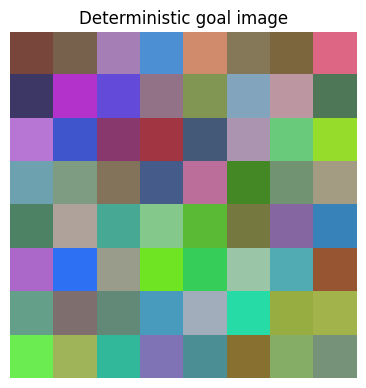

PARENT-HAMILTONIAN COMPILATION
qubits: 8
mps_bond_dimensions: (2, 3, 3, 3, 3, 3, 2)
compression_ratio: 1.846154
local_parent_terms: 5
local_ground_degeneracy: 1
local_groundspace_target_weight: 1.000000000
certification_anchor_used: False
anchored_ground_fidelity: 1.000000000
anchored_gap: 0.059080319
target_energy_variance: 3.351080748e-29
ground_reconstruction_psnr: 16.421464 dB
compile_seconds: 0.219


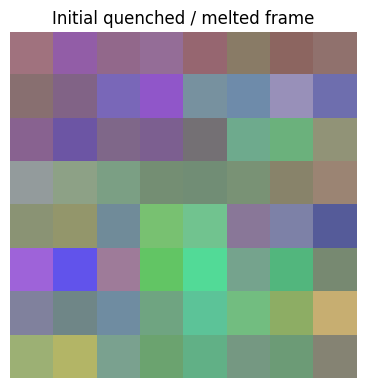

Parent-Hamiltonian Image Matter:
claim_scope=finite-size simulation; not a thermodynamic phase-transition proof
mps_bond_dimensions=[2, 3, 3, 3, 3, 3, 2]
mps_compression_ratio=1.846154
local_block_size=4
local_parent_terms=5
local_ground_degeneracy=1
local_groundspace_target_weight=1.000000000
mps_certification_anchor=false
anchored_ground_fidelity=1.000000000
anchored_spectral_gap=0.059080319
target_energy_variance=3.351080748e-29
ground_reconstruction_psnr=16.421464

Quantum State:
simulation=pennylane.default.mixed + exact finite-size Hamiltonian algebra
hardware_entropy=false
loop=1/500
elapsed=0.000/30000.000
context=0/131072
memory_hits=0
quench_field=0.025760000
evolution_time=0.361000000
quenched_gap=0.139304835
quenched_ground_fidelity=0.065001162
survival_probability=0.999633287
measurement_entropy_bits=7.459112521
melted_psnr=16.422999
circuit_entropy_bits=5.317234340
circuit_purity=0.829467226
circuit_z=-0.1369906,0.5011185,-0.0627322,-0.3006270,-0.0866845,0.0313678
modifie

In [17]:
#@title 11. Define the goal and compile Image Matter
GOAL = "explore and build an quantum computing framework from scratch. design many different algos, equations and systems, and interate on, provide useful equations, and create different agents for this task over a timewind" #@param {type:"string"}

if not GOAL.strip():
    raise ValueError("GOAL cannot be empty.")

compilation = matter.compile(GOAL)
show_compilation(compilation)

initial_snapshot = matter.snapshot(
    loop_index=1,
    max_loops=config.max_loops,
    elapsed_seconds=0.0,
    max_seconds=config.max_seconds,
    context_tokens=0,
    context_limit=config.context_tokens,
    memory_hits=0,
)
show_image(initial_snapshot.melted_image, "Initial quenched / melted frame")
print(initial_snapshot.as_prompt(compilation))


In [18]:
#@title 12. Load/reuse an idempotent Gemma pool (safe to rerun)
from dataclasses import replace
import gc, hashlib, contextlib

if not Path(config.model_path).expanduser().exists():
    raise FileNotFoundError(
        f"GGUF not found at {config.model_path}. Run the download cell or update config.model_path."
    )

def gpu_memory_report(label: str) -> dict:
    report = {"label": label, "cuda": bool(torch.cuda.is_available())}
    if torch.cuda.is_available():
        free_b, total_b = torch.cuda.mem_get_info()
        allocated = torch.cuda.memory_allocated()
        reserved = torch.cuda.memory_reserved()
        report.update(
            total_gb=total_b/2**30, free_gb=free_b/2**30,
            allocated_gb=allocated/2**30, reserved_gb=reserved/2**30,
        )
        print(
            f"[{label}] GPU total={report['total_gb']:.2f} GB | "
            f"free={report['free_gb']:.2f} GB | "
            f"torch_allocated={report['allocated_gb']:.2f} GB | "
            f"torch_reserved={report['reserved_gb']:.2f} GB"
        )
    return report

def _pool_signature() -> tuple:
    return (
        str(Path(config.model_path).expanduser().resolve()),
        int(config.context_tokens), int(config.n_gpu_layers), int(config.n_batch),
        int(config.n_ubatch), bool(config.offload_kqv), bool(config.flash_attn),
        int(PARALLEL_GEMMA_REPLICAS), int(WORKER_REPLICA_CONTEXT_TOKENS),
    )

def unload_gemma_pool() -> None:
    state = globals().get("_HUMOID_GEMMA_POOL_STATE") or {}
    old_pool = state.get("models", [])
    for index, item in enumerate(old_pool):
        try:
            print(f"Unloading stale Gemma replica {index}, instance={getattr(item, 'instance_id', '?')}")
            item.unload()
        except Exception as exc:
            print(f"Replica {index} unload warning: {type(exc).__name__}: {exc}")
    globals().pop("_HUMOID_GEMMA_POOL_STATE", None)
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

signature = _pool_signature()
existing = globals().get("_HUMOID_GEMMA_POOL_STATE") or {}
existing_pool = existing.get("models", [])
reusable = (
    existing.get("signature") == signature
    and existing_pool
    and all(getattr(item, "loaded", False) for item in existing_pool)
)

gpu_memory_report("before-pool")
if reusable:
    worker_models = existing_pool
    model = worker_models[0]
    print(f"Reusing existing Gemma pool generation={existing.get('generation')} — no model reload.")
else:
    if existing_pool:
        print("Gemma configuration changed or pool is unhealthy; unloading old pool first.")
        unload_gemma_pool()

    # Reuse the primary object only when it is currently unloaded; otherwise create
    # a clean primary object so no hidden llama.cpp context remains attached.
    try:
        if getattr(model, "loaded", False):
            model.unload()
    except Exception:
        pass
    model = LocalGemma(config, notebook_log)
    model.load()
    actual_n_ctx = int(model.llm.n_ctx())
    assert actual_n_ctx == int(config.context_tokens), (
        f"Expected {int(config.context_tokens):,}, got {actual_n_ctx:,}"
    )
    worker_models = [model]
    gpu_memory_report("primary-loaded")

    requested_replicas = max(1, int(PARALLEL_GEMMA_REPLICAS))
    for replica_index in range(1, requested_replicas):
        if torch.cuda.is_available():
            free_b, _ = torch.cuda.mem_get_info()
            free_gb = free_b / 2**30
            if free_gb < float(MIN_GPU_FREE_GB_PER_EXTRA_REPLICA):
                print(f"[replica {replica_index}] skipped: {free_gb:.2f} GB free.")
                break
        replica_config = replace(
            config,
            context_tokens=min(int(config.context_tokens), int(WORKER_REPLICA_CONTEXT_TOKENS)),
            use_weaviate=False, embedded_weaviate=False, use_dpr=False,
            use_contriever=False, use_reranker=False, use_bart=False,
        )
        replica = LocalGemma(replica_config, notebook_log)
        try:
            print(f"Loading worker replica {replica_index}, context={replica_config.context_tokens:,}...")
            replica.load()
            worker_models.append(replica)
            gpu_memory_report(f"replica-{replica_index}-loaded")
        except Exception as exc:
            print(f"[replica {replica_index}] failed: {type(exc).__name__}: {exc}")
            replica.unload()
            break

    generation = int(existing.get("generation", 0)) + 1
    globals()["_HUMOID_GEMMA_POOL_STATE"] = {
        "signature": signature, "models": worker_models, "generation": generation,
        "created_at": utc_now(),
    }

EFFECTIVE_PARALLEL_WORKERS = max(1, min(int(PARALLEL_WORKERS), len(worker_models)))
print(f"Gemma pool ready: replicas={len(worker_models)}, parallel_workers={EFFECTIVE_PARALLEL_WORKERS}.")
print("Model registry:")
for index, item in enumerate(worker_models):
    print(
        f"  replica={index} loaded={item.loaded} instance={item.instance_id} "
        f"context={int(item.llm.n_ctx()) if item.loaded else 0:,}"
    )
gpu_memory_report("pool-ready")
print("Rerunning this cell now reuses the same instances. Call unload_gemma_pool() to force a clean reload.")


llama_model_loader: loaded meta data with 49 key-value pairs and 541 tensors from /content/humoid_parent_hamiltonian/models/gemma-4-E2B_q4_0-it.gguf (version GGUF V3 (latest))
llama_model_loader: Dumping metadata keys/values. Note: KV overrides do not apply in this output.
llama_model_loader: - kv   0:                       general.architecture str              = gemma4
llama_model_loader: - kv   1:                               general.type str              = model
llama_model_loader: - kv   2:                     general.sampling.top_k i32              = 64
llama_model_loader: - kv   3:                     general.sampling.top_p f32              = 0.950000
llama_model_loader: - kv   4:                      general.sampling.temp f32              = 1.000000
llama_model_loader: - kv   5:                               general.name str              = Hf
llama_model_loader: - kv   6:                         general.size_label str              = 4.6B
llama_model_loader: - kv   7:           

[before-pool] GPU total=14.56 GB | free=14.46 GB | torch_allocated=0.00 GB | torch_reserved=0.00 GB
[system] Loading Gemma with explicit Llama(..., n_ctx=131072): gpu_layers=-1, offload_kqv=False


llama_model_loader: - kv  26:            gemma4.attention.sliding_window u32              = 512
llama_model_loader: - kv  27:          gemma4.attention.shared_kv_layers u32              = 20
llama_model_loader: - kv  28:    gemma4.embedding_length_per_layer_input u32              = 256
llama_model_loader: - kv  29:    gemma4.attention.sliding_window_pattern arr[bool,35]     = [true, true, true, true, false, true,...
llama_model_loader: - kv  30:            gemma4.attention.key_length_swa u32              = 256
llama_model_loader: - kv  31:          gemma4.attention.value_length_swa u32              = 256
llama_model_loader: - kv  32:                gemma4.rope.dimension_count u32              = 512
llama_model_loader: - kv  33:            gemma4.rope.dimension_count_swa u32              = 256
llama_model_loader: - kv  34:                       tokenizer.ggml.model str              = gemma4
llama_model_loader: - kv  35:                      tokenizer.ggml.tokens arr[str,262144]  = ["<pa

[system] Gemma model loaded: requested_n_ctx=131,072, actual_n_ctx=131,072
[primary-loaded] GPU total=14.56 GB | free=10.80 GB | torch_allocated=0.00 GB | torch_reserved=0.00 GB
Loading worker replica 1, context=65,536...
[system] Loading Gemma with explicit Llama(..., n_ctx=65536): gpu_layers=-1, offload_kqv=False


llama_model_loader: - kv  35:                      tokenizer.ggml.tokens arr[str,262144]  = ["<pad>", "<eos>", "<bos>", "<unk>", ...
llama_model_loader: - kv  36:                      tokenizer.ggml.scores arr[f32,262144]  = [-1000.000000, -1000.000000, -1000.00...
llama_model_loader: - kv  37:                  tokenizer.ggml.token_type arr[i32,262144]  = [3, 3, 3, 3, 3, 1, 1, 1, 1, 1, 1, 1, ...
llama_model_loader: - kv  38:                      tokenizer.ggml.merges arr[str,514906]  = ["\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n \n", ...
llama_model_loader: - kv  39:                tokenizer.ggml.bos_token_id u32              = 2
llama_model_loader: - kv  40:                tokenizer.ggml.eos_token_id u32              = 1
llama_model_loader: - kv  41:            tokenizer.ggml.unknown_token_id u32              = 3
llama_model_loader: - kv  42:            tokenizer.ggml.padding_token_id u32              = 0
llama_model_loader: - kv  43:               tokenizer.ggml.ma

[system] Gemma model loaded: requested_n_ctx=65,536, actual_n_ctx=65,536
[replica-1-loaded] GPU total=14.56 GB | free=8.31 GB | torch_allocated=0.00 GB | torch_reserved=0.00 GB
Gemma pool ready: replicas=2, parallel_workers=2.
Model registry:
  replica=0 loaded=True instance=0x7d182f01b740 context=131,072
  replica=1 loaded=True instance=0x7d182cf68380 context=65,536
[pool-ready] GPU total=14.56 GB | free=8.31 GB | torch_allocated=0.00 GB | torch_reserved=0.00 GB
Rerunning this cell now reuses the same instances. Call unload_gemma_pool() to force a clean reload.


In [19]:
#@title 12b. Live state, database, and Markdown observability dashboard
from IPython.display import display, Markdown
from collections import Counter

def _short(text, limit=260):
    text = " ".join(str(text or "").split())
    return text if len(text) <= limit else text[:limit-1] + "…"

def build_humoid_markdown_report(
    state_path=AUTONOMOUS_STATE_PATH if "AUTONOMOUS_STATE_PATH" in globals() else DATA_DIR / "autonomous_task_state.json",
    db_path=DB_PATH,
    output_path=DATA_DIR / "humoid_live_report.md",
):
    state = {}
    if Path(state_path).exists():
        state = json.loads(Path(state_path).read_text(encoding="utf-8"))
    tasks = state.get("tasks", {})
    status_counts = Counter(t.get("status", "unknown") for t in tasks.values())
    completed = [tasks[k] for k in state.get("completed_order", []) if k in tasks]
    queued_ids = state.get("queue", [])

    lines = [
        "# Humoid Autonomous Run Report", "",
        f"**Goal:** {_short(state.get('goal', '(no saved goal)'), 1200)}", "",
        "## Runtime progress", "",
        f"- Goal complete: **{state.get('goal_complete', False)}**",
        f"- Total worker slices: **{state.get('total_slices', 0)} / {state.get('min_total_slices', '?')} minimum**",
        f"- Completed tasks: **{len(completed)} / {state.get('min_completed_tasks', '?')} minimum**",
        f"- Queued task IDs: **{len(queued_ids)}**",
        f"- Task status counts: **{dict(status_counts)}**",
        f"- Coordinator assessment: {_short(state.get('coordinator_reason', ''), 1500)}", "",
        "## Completed work", "",
    ]
    if not completed:
        lines.append("No tasks have passed verification yet.")
    for t in completed:
        lines += [
            f"### {t.get('title', t.get('task_id'))}",
            f"- Slices: {t.get('slices', 0)}",
            f"- Verifier: {_short(t.get('verifier_reason', ''), 1000)}",
            f"- Final artifact: `{DATA_DIR / 'humoid_workspace' / t.get('task_id','unknown') / 'FINAL_VERIFIED_ARTIFACT.md'}`",
            f"- Output summary: {_short(t.get('final_output', ''), 3000)}", "",
        ]

    lines += ["## Active and queued work", ""]
    active = [t for t in tasks.values() if t.get('status') in {'queued','running'}]
    for t in active[:40]:
        lines += [
            f"- **{t.get('title', t.get('task_id'))}** — status={t.get('status')}, "
            f"slices={t.get('slices', 0)}, depth={t.get('depth', 0)}. "
            f"Objective: {_short(t.get('objective', ''), 500)}"
        ]
    if len(active) > 40:
        lines.append(f"- …and {len(active)-40} more active tasks.")

    lines += ["", "## SQLite memory", ""]
    db_path = Path(db_path)
    try:
        with sqlite3.connect(db_path, timeout=10) as db:
            db.row_factory = sqlite3.Row
            tables = [r[0] for r in db.execute("SELECT name FROM sqlite_master WHERE type='table'")]
            lines.append(f"Database: `{db_path}`; tables: `{tables}`")
            if 'memories' in tables:
                count = db.execute("SELECT COUNT(*) FROM memories").fetchone()[0]
                lines.append(f"Memory rows: **{count}**")
                rows = db.execute(
                    "SELECT role, kind, summary, content, importance, created_at "
                    "FROM memories ORDER BY created_at DESC LIMIT 30"
                ).fetchall()
                for r in rows:
                    summary = r['summary'] or r['content']
                    lines.append(
                        f"- `{r['created_at']}` **{r['role']}/{r['kind']}** "
                        f"importance={r['importance']:.2f}: {_short(summary, 700)}"
                    )
    except Exception as exc:
        lines.append(f"Database inspection failed: `{type(exc).__name__}: {exc}`")

    lines += ["", "## Quality audit", "",
        "The saved run is making progress, but several generated quantum examples are not yet reliable framework code. "
        "Observed issues include placeholder `pass` bodies, invalid state-vector dimensions, syntax errors such as "
        "`get_ Grover_probabilities`, and verifiers accepting outputs that do not satisfy the stated task. "
        "Treat completed labels as provisional until executable tests pass.", "",
        "## Next program actions", "",
        "1. Require workers to save code into an artifact workspace instead of only returning prose/code blocks.",
        "2. Execute generated Python in a subprocess and attach stdout, stderr, return code, and test results as evidence.",
        "3. Reject syntax errors, placeholder functions, dimension mismatches, and unverifiable claims before completion.",
        "4. Deduplicate tasks by normalized objective hash and compare new output against previous slices.",
        "5. Use the model pool registry so rerunning cells does not reload Gemma repeatedly.",
    ]
    report = "\n".join(lines)
    Path(output_path).write_text(report, encoding="utf-8")
    return report, Path(output_path)

report_text, report_path = build_humoid_markdown_report()
display(Markdown(report_text))
print(f"Markdown report written to: {report_path}")


# Humoid Autonomous Run Report

**Goal:** (no saved goal)

## Runtime progress

- Goal complete: **False**
- Total worker slices: **0 / ? minimum**
- Completed tasks: **0 / ? minimum**
- Queued task IDs: **0**
- Task status counts: **{}**
- Coordinator assessment: 

## Completed work

No tasks have passed verification yet.
## Active and queued work


## SQLite memory

Database: `/content/humoid_parent_hamiltonian/data/humoid_memory.sqlite3`; tables: `['memories']`
Memory rows: **0**

## Quality audit

The saved run is making progress, but several generated quantum examples are not yet reliable framework code. Observed issues include placeholder `pass` bodies, invalid state-vector dimensions, syntax errors such as `get_ Grover_probabilities`, and verifiers accepting outputs that do not satisfy the stated task. Treat completed labels as provisional until executable tests pass.

## Next program actions

1. Require workers to save code into an artifact workspace instead of only returning prose/code blocks.
2. Execute generated Python in a subprocess and attach stdout, stderr, return code, and test results as evidence.
3. Reject syntax errors, placeholder functions, dimension mismatches, and unverifiable claims before completion.
4. Deduplicate tasks by normalized objective hash and compare new output against previous slices.
5. Use the model pool registry so rerunning cells does not reload Gemma repeatedly.

Markdown report written to: /content/humoid_parent_hamiltonian/data/humoid_live_report.md


In [ ]:
#@title 11. Run/resume the advanced autonomous scheduler
stop_event.clear()
AUTONOMOUS_STATE_PATH = DATA_DIR / "autonomous_task_state.json"

# Migrate prior V2 project sections into the V4 project tenant, then run the full health suite.
actual_project_id = VerifiedWeaviateSectionStore.project_id(GOAL)
if bool(AUTO_MIGRATE_WEAVIATE_V2) and section_memory.available:
    migration_report = section_memory.migrate_legacy_v2(actual_project_id)
    print("=== Weaviate V2 -> V4 migration ===")
    print(json.dumps(migration_report, indent=2, ensure_ascii=False, default=str))
weaviate_health = section_memory.deep_health_check(actual_project_id)
print("=== Weaviate DeepMemory V4 health ===")
print(json.dumps(weaviate_health, indent=2, ensure_ascii=False, default=str))
if section_memory.available and not weaviate_health.get("healthy", False):
    raise RuntimeError("Weaviate DeepMemory V4 is not healthy; scheduler start aborted to prevent silent memory loss.")

orchestrator = AdvancedAutonomousTaskOrchestrator(
    model=model,
    memory=memory,
    section_memory=section_memory,
    compactor=compactor,
    session_id=session_id,
    stop_event=stop_event,
    state_path=AUTONOMOUS_STATE_PATH,
    task_slice_seconds=int(TASK_SLICE_SECONDS),
    max_run_seconds=int(AUTONOMOUS_RUN_SECONDS),
    max_tasks=int(MAX_AUTONOMOUS_TASKS),
    max_depth=int(MAX_TASK_DEPTH),
    max_slices_per_task=int(MAX_SLICES_PER_TASK),
    completion_confidence=float(AUTONOMOUS_COMPLETION_CONFIDENCE),
    min_completed_tasks=int(MIN_COMPLETED_TASKS_BEFORE_GOAL_COMPLETE),
    min_total_slices=int(MIN_TOTAL_SLICES_BEFORE_GOAL_COMPLETE),
    rollover_exhausted_tasks=bool(ROLLOVER_EXHAUSTED_TASKS),
    worker_models=worker_models,
    parallel_workers=int(EFFECTIVE_PARALLEL_WORKERS),
    worker_output_tokens=int(WORKER_OUTPUT_TOKENS),
    memory_agent_output_tokens=int(MEMORY_AGENT_OUTPUT_TOKENS),
    verifier_output_tokens=int(VERIFIER_OUTPUT_TOKENS),
    coordinator_output_tokens=int(COORDINATOR_OUTPUT_TOKENS),
    task_synthesis_output_tokens=int(TASK_SYNTHESIS_OUTPUT_TOKENS),
    project_synthesis_output_tokens=int(PROJECT_SYNTHESIS_OUTPUT_TOKENS),
    memory_recall_limit=int(MEMORY_RECALL_LIMIT),
    memory_recall_candidates=int(MEMORY_RECALL_CANDIDATES),
    max_memory_packet_chars=int(MAX_MEMORY_PACKET_CHARS),
    max_task_ledger_chars=int(MAX_TASK_LEDGER_CHARS),
    max_slice_artifact_chars=int(MAX_SLICE_ARTIFACT_CHARS),
    enable_dual_verification=bool(ENABLE_DUAL_VERIFICATION),
    run_generated_python=bool(RUN_GENERATED_PYTHON),
    generated_code_timeout_seconds=int(GENERATED_CODE_TIMEOUT_SECONDS),
)

# resume=True reloads the saved task graph when GOAL matches exactly.
orchestrator.run(GOAL, resume=True)

# Generate a long integrated report from every verified final artifact.
project_report_path = orchestrator.synthesize_project_report()
print(f"Project synthesis written to: {project_report_path}")


=== Weaviate V2 -> V4 migration ===
{
  "project_id": "7b82ceda23177758b29879af",
  "sources": {
    "HumoidSectionMemoryV2": "absent"
  },
  "migrated": 0,
  "skipped": 0,
  "errors": []
}


INFO:weaviate-client:Provisioned stream to the server for batch processing
INFO:weaviate-client:Batch stream started successfully
INFO:weaviate-client:Sent sentinel, stopping batch loop...
INFO:weaviate-client:exited batch requests loop thread
INFO:weaviate-client:Batching finished, stopping and closing the client-side of the stream
INFO:weaviate-client:Server closed the stream from its side, shutting down batch
INFO:weaviate-client:exited batch receive thread
ggml_cuda_graph_set_enabled: disabling CUDA graphs due to GPU architecture
ggml_cuda_graph_set_enabled: disabling CUDA graphs due to GPU architecture
ggml_cuda_graph_set_enabled: disabling CUDA graphs due to GPU architecture
ggml_cuda_graph_set_enabled: disabling CUDA graphs due to GPU architecture
ggml_cuda_graph_set_enabled: disabling CUDA graphs due to GPU architecture
ggml_cuda_graph_set_enabled: disabling CUDA graphs due to GPU architecture
ggml_cuda_graph_set_enabled: disabling CUDA graphs due to GPU architecture
ggml_cuda_

=== Weaviate DeepMemory V4 health ===
{
  "available": true,
  "schema_version": 4,
  "project_id": "7b82ceda23177758b29879af",
  "tenant": "proj-7b82ceda23177758b29879af",
  "physical_collection": "HumoidSectionMemoryV4",
  "active_collection": "HumoidSectionMemoryCurrent",
  "required_checks": {
    "live": true,
    "ready": true,
    "collection_exists": true,
    "schema_properties": true,
    "named_vectors": true,
    "batch_write": true,
    "exists": true,
    "read_back": true,
    "bm25_search": true,
    "hybrid_search": true,
    "full_retrieval_pipeline": true,
    "delete": true
  },
  "optional_checks": {
    "alias_active": true,
    "multi_tenancy_configured": true,
    "ttl_configured": true,
    "rq_visible": true,
    "meta_read": true,
    "vector_queue_read": true,
    "multi_target_search": true,
    "neighbor_expansion": false
  },
  "latency_ms": {
    "batch_insert": 1065.7,
    "read_back": 4.52,
    "bm25": 2.85,
    "hybrid": 3.65,
    "multi_target": 6.2


llama_perf_context_print:        load time =     829.44 ms
llama_perf_context_print: prompt eval time =     822.93 ms /   172 tokens (    4.78 ms per token,   209.01 tokens per second)
llama_perf_context_print:        eval time =   39289.28 ms /  1289 runs   (   30.48 ms per token,    32.81 tokens per second)
llama_perf_context_print:       total time =  165404.34 ms /  1461 tokens
llama_perf_context_print:    graphs reused =       1283



[scheduler] task-20f606961473 | depth=0 | slice=1/64 | replica=0
[task] Quantum State Representation and Manipulation Core


[scheduler] task-37218cfa6622 | depth=0 | slice=1/64 | replica=1
[task] Foundational Quantum Algorithms Implementation (Phase 1)



...

Llama.generate: 6 prefix-match hit, remaining 2354 prompt tokens to eval
llama_perf_context_print:        load time =     829.44 ms
llama_perf_context_print: prompt eval time =    1326.80 ms /  2354 tokens (    0.56 ms per token,  1774.19 tokens per second)
llama_perf_context_print:        eval time =   11153.35 ms /   289 runs   (   38.59 ms per token,    25.91 tokens per second)
llama_perf_context_print:       total time =   12994.87 ms /  2643 tokens
llama_perf_context_print:    graphs reused =        287
INFO:weaviate-client:Provisioned stream to the server for batch processing
INFO:weaviate-client:Batch stream started successfully
INFO:weaviate-client:Sent sentinel, stopping batch loop...
INFO:weaviate-client:exited batch requests loop thread
INFO:weaviate-client:Batching finished, stopping and closing the client-side of the stream
INFO:weaviate-client:Server closed the stream from its side, shutting down batch
INFO:weaviate-client:exited batch receive thread
Llama.generate: 6 pre

ho$ and purity checks.
[artifact] /content/humoid_parent_hamiltonian/data/humoid_workspace/task-20f606961473/slice-0001.md; indexed_sections=5


llama_perf_context_print:        load time =     829.44 ms
llama_perf_context_print: prompt eval time =    1466.51 ms /  2504 tokens (    0.59 ms per token,  1707.45 tokens per second)
llama_perf_context_print:        eval time =   18959.58 ms /   465 runs   (   40.77 ms per token,    24.53 tokens per second)
llama_perf_context_print:       total time =   21373.97 ms /  2969 tokens
llama_perf_context_print:    graphs reused =        462
INFO:weaviate-client:Provisioned stream to the server for batch processing
INFO:weaviate-client:Batch stream started successfully
INFO:weaviate-client:Sent sentinel, stopping batch loop...
INFO:weaviate-client:Batching finished, stopping and closing the client-side of the stream
INFO:weaviate-client:exited batch requests loop thread
INFO:weaviate-client:Server closed the stream from its side, shutting down batch
INFO:weaviate-client:exited batch receive thread
Llama.generate: 6 prefix-match hit, remaining 4320 prompt tokens to eval
ggml_cuda_graph_set_e

[dual-verifier] CONTINUE Proceed to Phase 2: Develop a symbolic mapping engine or specific gate decomposition routines to translate abstract functions $f(x)$ into executable Qiskit gate sequences for the DJ and Grover oracles. | Proceed to Phase 2: Develop a concrete, functional mapping engine or specific gate decomposition routines to translate abstract functions $f(x)$ into executable Qiskit gate sequences for the DJ and Grover oracles. Focus first on the $n=1$ case for DJ, then generalize the structure.
[artifact] /content/humoid_parent_hamiltonian/data/humoid_workspace/task-37218cfa6622/slice-0001.md; indexed_sections=10

[scheduler] task-041e5b083009 | depth=0 | slice=1/64 | replica=0
[task] Quantum Simulation Engine Development


[scheduler] task-9eb34421ddb2 | depth=0 | slice=1/64 | replica=1
[task] Variational Quantum Eigensolver (VQE) Framework



Llama.generate: 6 prefix-match hit, remaining 14687 prompt tokens to eval
Llama.generate: 9 prefix-match hit, remaining 14638 prompt tokens to eval
ggml_cuda_graph_set_enabled: disabling CUDA graphs due to GPU architecture
ggml_cuda_graph_set_enabled: disabling CUDA graphs due to GPU architecture
ggml_cuda_graph_set_enabled: disabling CUDA graphs due to GPU architecture
ggml_cuda_graph_set_enabled: disabling CUDA graphs due to GPU architecture
ggml_cuda_graph_set_enabled: disabling CUDA graphs due to GPU architecture
ggml_cuda_graph_set_enabled: disabling CUDA graphs due to GPU architecture
ggml_cuda_graph_set_enabled: disabling CUDA graphs due to GPU architecture
ggml_cuda_graph_set_enabled: disabling CUDA graphs due to GPU architecture
ggml_cuda_graph_set_enabled: disabling CUDA graphs due to GPU architecture
ggml_cuda_graph_set_enabled: disabling CUDA graphs due to GPU architecture
ggml_cuda_graph_set_enabled: disabling CUDA graphs due to GPU architecture
ggml_cuda_graph_set_enabled

In [ ]:
#@title 12. Search this session's memory
MEMORY_QUERY = "" #@param {type:"string"}
MEMORY_RESULTS = 10 #@param {type:"integer"}

hits = memory.search(
    session_id=session_id,
    queries=(MEMORY_QUERY,),
    limit=int(MEMORY_RESULTS),
    candidates=max(int(MEMORY_RESULTS) * 3, config.retrieval_candidates),
    alpha=config.hybrid_alpha,
)

if not hits:
    print("No matching memory entries.")
else:
    for index, hit in enumerate(hits, 1):
        print(
            f"\n[{index}] score={hit.score:.5f} source={hit.source} "
            f"channel={hit.channel} kind={hit.kind} role={hit.role}\n"
            f"{hit.summary or hit.content}"
        )


In [ ]:
#@title 13. Stop or clean up
# Run this cell to request a stop between generated chunks and close memory resources.
stop_event.set()
with contextlib.suppress(Exception):
    memory.close()
print("Stop requested and memory resources closed.")


In [ ]:
#@title 14. Inspect DeepMemory V4, retrieval traces, outputs, and model registries
from IPython.display import display, Markdown

print("=== Gemma registry ===")
print(json.dumps({k: v for k, v in (globals().get("_HUMOID_GEMMA_POOL_STATE") or {}).items() if k != "models"}, indent=2, default=str))
for i, item in enumerate((globals().get("_HUMOID_GEMMA_POOL_STATE") or {}).get("models", [])):
    print(f"replica={i} loaded={item.loaded} instance={item.instance_id} context={item.llm.n_ctx() if item.loaded else 0}")

print("
=== Retrieval registry ===")
print(json.dumps({k: str(v) for k, v in (globals().get("_HUMOID_RETRIEVAL_STACK") or {}).items() if k not in {"memory","compactor"}}, indent=2))

project_id = VerifiedWeaviateSectionStore.project_id(GOAL)
print("
=== Weaviate DeepMemory V4 health ===")
print(json.dumps(section_memory.deep_health_check(project_id), indent=2, default=str))

WEAVIATE_DIAGNOSTIC_QUERY = "latest verified interfaces equations failures unresolved checkpoint" #@param {type:"string"}
print("
=== Retrieval benchmark ===")
diagnostic_hits = section_memory.retrieve(
    project_id=project_id,
    queries=[WEAVIATE_DIAGNOSTIC_QUERY],
    limit=12,
    candidates=60,
    trace_name="manual-diagnostic",
)
for index, hit in enumerate(diagnostic_hits, 1):
    print(
        f"[{index}] score={hit.score:.4f} status={hit.validation_status} "
        f"task={hit.task_id} slice={hit.slice_index}.{hit.section_index} channel={hit.channel}
"
        f"    {hit.title} | {hit.artifact_path} | memory_id={hit.memory_id}"
    )

trace_dir = section_memory.TRACE_DIR
print(f"Retrieval traces: {trace_dir.resolve()}")
for path in sorted(trace_dir.glob("*.json"), key=lambda p: p.stat().st_mtime, reverse=True)[:10]:
    print(f"  {path}")

if "orchestrator" in globals():
    report_path = orchestrator.synthesize_project_report()
    display(Markdown(report_path.read_text(encoding="utf-8")[:120000]))
    print(f"Full report: {report_path}")


## Notes and troubleshooting

- **Out of memory:** reduce `CONTEXT_TOKENS`, `MAX_OUTPUT_TOKENS`, `n_batch`, or set `n_gpu_layers=0` in the runtime configuration.
- **Model access denied:** accept the model license on Hugging Face and add `HF_TOKEN` to Colab Secrets.
- **Advanced memory:** run the optional dependency cell, then enable only the components needed. DPR, Contriever, BART, and reranking can consume substantial RAM and download several models.
- **Embedded Weaviate:** it is preserved from the original engine but disabled by default because Colab sessions are ephemeral and binary startup can be less reliable than SQLite.
- **Persistence:** enable Google Drive in the storage cell to retain the GGUF and SQLite database between sessions.
- **Safety boundary:** the loop is always bounded by loop count, wall-clock time, a stop event, and a consecutive-failure limit.

- **Autonomous scheduler:** timer slices do not keep Colab alive after the runtime disconnects. Enable Google Drive to persist the scheduler JSON and SQLite memory, then rerun the final scheduler cell to resume.


- **Long-run scheduler:** defaults now allow 64 slices per task, 256 tasks, depth 16, and a six-hour scheduler session. A task that still needs work at its slice cap rolls into a fresh child task carrying its latest checkpoint instead of simply dying.
- **Premature-completion guard:** the coordinator cannot end the overall goal until both `MIN_COMPLETED_TASKS_BEFORE_GOAL_COMPLETE` and `MIN_TOTAL_SLICES_BEFORE_GOAL_COMPLETE` are reached. These are minimum-work gates, not proof of correctness; the verifier still decides task completion.
- **Colab limitation:** no Python loop can prevent a hosted runtime from being reclaimed. Keep Drive persistence enabled and rerun the scheduler cell with `resume=True` after a disconnect.

- **Parallel Gemma pool:** the default is two total replicas and two concurrent worker tasks. The primary retains the 131K context; extra workers default to 65K to reduce KV-cache pressure.
- **Why not fill all 15 GB immediately:** simultaneous long generations expand KV caches. The loader checks free GPU memory before each extra replica and falls back cleanly if a replica cannot fit.
- **Scaling:** try `PARALLEL_GEMMA_REPLICAS = 3` only after watching peak GPU memory during long outputs. Reduce `WORKER_REPLICA_CONTEXT_TOKENS` to 32768 before adding a third replica.


### Long-form output controls

The actual worker limit is now `WORKER_OUTPUT_TOKENS`, not only `MAX_OUTPUT_TOKENS`. A 10,000-token output can take several minutes on a T4, so `TASK_SLICE_SECONDS` defaults to 900 seconds. Increase both together. The final task and project synthesis budgets are separate.

### Weaviate correctness

Run **10E** before the scheduler. It checks liveness, readiness, collection existence, named-vector configuration, object count, and a complete insert/read/hybrid-search/delete round trip. The scheduler aborts rather than silently falling back when Weaviate exists but fails the triple-check.

### Safe code validation

Static syntax and quantum-specific checks always run. `RUN_GENERATED_PYTHON=False` by default because a subprocess is not a security sandbox. Enable it only for code you are willing to execute in the Colab runtime.


## Weaviate DeepMemory V4 behavior

- Each project goal maps to a stable tenant (`proj-<goal hash>`), so projects cannot retrieve each other's objects.
- The stable alias `HumoidSectionMemoryCurrent` points to the active V4 physical collection. If schema drift is detected, the notebook creates a new physical collection and switches the alias instead of mutating an incompatible schema in place.
- Retrieval is an ensemble: BM25, DPR hybrid, Contriever, deterministic hash, weighted multi-target vector search, and task-lineage recall. Results are fused with reciprocal-rank fusion, reranked locally, diversified, and expanded through predecessor/successor links.
- `humoid_workspace/retrieval_traces/*.json` records each channel's latency/errors and the selected memory IDs.
- Provisional and failed memories receive finite lifetimes; verified foundations receive a much longer lifetime. Embedded Weaviate must start with `OBJECTS_TTL_DELETE_SCHEDULE` for background deletion.
- Cell 10E runs schema, batch-write, read-back, BM25, hybrid, multi-target, full retrieval, neighbor, delete, server metadata, and vector-queue diagnostics.
